In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
 PART 0 — RUN MODE SELECTOR + EXPANDED-SCOPE CONFIG
═══════════════════════════════════════════════════════════════════════════════
 Lets the same notebook run in either narrow original mode or expanded
 North-American mode, with separate cache directories so the two runs
 don't collide.

 WORKFLOW:
   1. Set RUN_MODE below
   2. Runtime → Restart runtime  (CRITICAL — old vars in memory will override)
   3. Run all cells from the top
   4. Switch RUN_MODE, restart runtime, run again
   5. Run PART F at the bottom for the comparison

 NOTE: This cell sets CACHE_DIR, REGION_BBOX, IBTRACS_BBOX as module-level
 names that all subsequent cells will use. The original hardcoded values in
 PART A have been commented out and patched.
═══════════════════════════════════════════════════════════════════════════════
"""

from pathlib import Path

# ─── PICK THE MODE ─────────────────────────────────────────────────────────
RUN_MODE = 'expanded'   # 'original' or 'expanded'

# ─── Region definitions per mode ───────────────────────────────────────────
if RUN_MODE == 'original':
    # US Lower Coast (the historical scope: south Florida → North Carolina)
    REGION_BBOX  = dict(lat_min=24.5, lat_max=35.0, lon_min=-98.0, lon_max=-75.0)
    IBTRACS_BBOX = dict(lat_min=22.0, lat_max=37.0, lon_min=-100.0, lon_max=-73.0)
    CACHE_DIR    = Path('/content/drive/MyDrive/CCN_synthesis')
    SCOPE_LABEL  = 'US Lower Coast (lat 24-35°N, lon 75-98°W)'

elif RUN_MODE == 'expanded':
    # North American tidal wetlands — Atlantic, Gulf, Pacific, Caribbean,
    # Mexico, Canadian Maritimes. Bounded but coherent biogeographic region.
    # Expected: 3,000-5,000 cores depending on what CCN has globally.
    REGION_BBOX  = dict(lat_min=17.0, lat_max=65.0, lon_min=-170.0, lon_max=-55.0)
    IBTRACS_BBOX = dict(lat_min=15.0, lat_max=67.0, lon_min=-172.0, lon_max=-53.0)
    CACHE_DIR    = Path('/content/drive/MyDrive/CCN_synthesis_expanded')
    SCOPE_LABEL  = 'North American coastline (lat 17-65°N, lon 55-170°W)'

else:
    raise ValueError(f"RUN_MODE must be 'original' or 'expanded', got {RUN_MODE!r}")

# Sentinel value so cell 1 can verify PART 0 actually ran in this kernel
_PART0_RAN = True

print(f"PART 0 OK")
print(f"  RUN_MODE       = {RUN_MODE!r}")
print(f"  Scope          = {SCOPE_LABEL}")
print(f"  CACHE_DIR      = {CACHE_DIR}")
print(f"  REGION_BBOX    = lat {REGION_BBOX['lat_min']}–{REGION_BBOX['lat_max']}°N, "
      f"lon {REGION_BBOX['lon_min']}–{REGION_BBOX['lon_max']}°E")
print(f"  IBTRACS_BBOX   = lat {IBTRACS_BBOX['lat_min']}–{IBTRACS_BBOX['lat_max']}°N, "
      f"lon {IBTRACS_BBOX['lon_min']}–{IBTRACS_BBOX['lon_max']}°E")
print()
print(f"→ If switching modes, restart runtime first (Runtime → Restart runtime)")
print(f"  to clear stale variables from previous run.")

PART 0 OK
  RUN_MODE       = 'expanded'
  Scope          = North American coastline (lat 17-65°N, lon 55-170°W)
  CACHE_DIR      = /content/drive/MyDrive/CCN_synthesis_expanded
  REGION_BBOX    = lat 17.0–65.0°N, lon -170.0–-55.0°E
  IBTRACS_BBOX   = lat 15.0–67.0°N, lon -172.0–-53.0°E

→ If switching modes, restart runtime first (Runtime → Restart runtime)
  to clear stale variables from previous run.


✓ PART 0 verified — using /content/drive/MyDrive/CCN_synthesis_expanded
Mounted at /content/drive
✓ EE initialised (project=leet-489301)

══════════════════════════════════════════════════════════════════════
PART A — Data downloads
══════════════════════════════════════════════════════════════════════
  ↓ CCN_cores.csv                  fetching... copied from /content/drive/MyDrive/CCN_synthesis/CCN_cores.csv  (  5.1 MB)
  ↓ CCN_depthseries.csv            fetching... copied from /content/drive/MyDrive/CCN_synthesis/CCN_depthseries.csv  ( 30.3 MB)
  Cores in region: 6,714  (182 studies)

  EMIT L2A hyperspectral (resumable):
    12898 EMIT scenes in region
      chunk   1/135:  50  [total 50 | eta 22.5 min]
      chunk   2/135:  50  [total 100 | eta 13.8 min]
      chunk   3/135:  50  [total 150 | eta 12.0 min]
      chunk   4/135:  50  [total 200 | eta 11.2 min]
      chunk   5/135:  50  [total 250 | eta 10.3 min]
      chunk   6/135:  50  [total 300 | eta 9.7 min]
      chunk   7/135

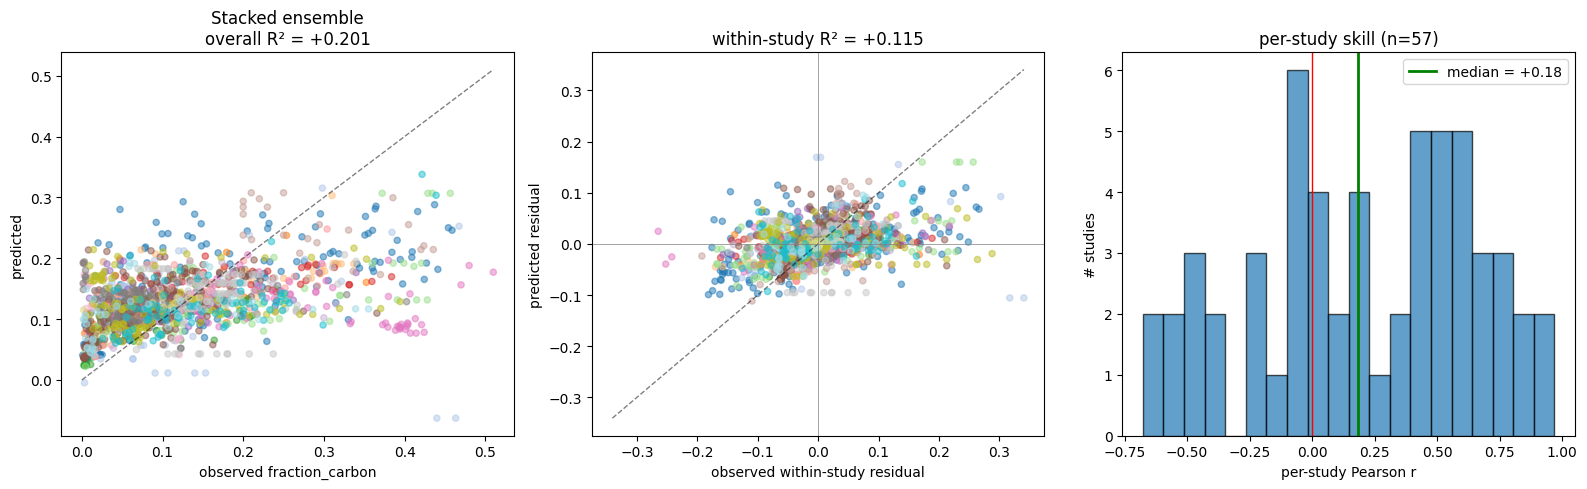


══════════════════════════════════════════════════════════════════════
VERDICT
══════════════════════════════════════════════════════════════════════
  Best overall R²:       +0.2250  (RF strong (raw y))
  Best within-study R²:  +0.1148  (Stacked ensemble)
  Best within-study r:   +0.3628

  ✓ Within-study signal IS recoverable. The original pipeline missed
    it because of over-regularization. Lead the writeup with this.

✓ Outputs:
    /content/drive/MyDrive/CCN_synthesis_expanded/within_study_scoreboard.csv
    /content/drive/MyDrive/CCN_synthesis_expanded/within_study_diagnostic.png


In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
 SELF-CONTAINED MANGROVE SOC PREDICTOR — single cell, Colab-safe
═══════════════════════════════════════════════════════════════════════════════
 Re-runnable end-to-end. First run downloads everything to Drive (~10-30 min,
 EMIT dominates). Every subsequent run reads from cache and skips to modeling
 (~3-5 min). Set FORCE_REFRESH=True to re-pull.

 Pipeline:
   PART A — Data downloads (cache-first, no-op if files exist on Drive)
              CCN cores + depthseries, EMIT L2A, SRTM, WorldClim,
              Sentinel-2 NDVI, Sentinel-1 SAR, JRC water history,
              IBTrACS tropical cyclones
   PART B — Feature engineering: depth-weighted 0-30cm fraction_carbon,
              EMIT domain spectral features, environmental, multi-sensor,
              temporal water dynamics, cyclone exposure
   PART C — WITHIN-STUDY PREDICTION ATTACK
              The diagnosis from prior runs: between-study EO R² ≈ 0.79 but
              within-study EO R² ≈ 0.004. The original RF was over-smoothing
              toward study means. This part tries strategies the prior
              pipeline never tried:
                C.1  Within-study residualization
                C.2  Stronger (less regularized) RF + HistGB
                C.3  Logit-transformed target
                C.4  Two-stage hierarchical (study mean + within residual)
                C.5  OOF-stacked ensemble
                C.6  Group-conformal prediction intervals
                C.7  Honest scoreboard — overall R² AND within-study R²

 Cache directory: /content/drive/MyDrive/CCN_synthesis/   (matches prior runs,
 so existing caches are reused — nothing redownloads)
═══════════════════════════════════════════════════════════════════════════════
"""

# ── Imports + Drive mount + EE auth ────────────────────────────────────────
import os, time, json, urllib.request, shutil, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import pearsonr, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error

# ─── Sanity: PART 0 must have run in this kernel ─────────────────────────
try:
    _ = _PART0_RAN
    _ = CACHE_DIR
    _ = REGION_BBOX
    _ = IBTRACS_BBOX
except NameError as _e:
    raise RuntimeError(
        "PART 0 has not run in this kernel — refusing to proceed.\n"
        "Run the PART 0 cell at the top of this notebook FIRST, then run\n"
        "this cell. If you switched RUN_MODE, also restart the runtime\n"
        "(Runtime → Restart runtime) before running PART 0.")
print(f"✓ PART 0 verified — using {CACHE_DIR}")

# ─── Mount Drive — robust against "already mounted" errors ────────────────
try:
    from google.colab import drive
    # Force-clean any stale/partial mount from a previous session
    os.system('fusermount -u /content/drive 2>/dev/null')
    os.system('umount       /content/drive 2>/dev/null')
    drive.mount('/content/drive')
except ImportError:
    print("(non-Colab environment — adjust CACHE_DIR if needed)")
except Exception as _mount_err:
    # If something weird happens, check if Drive is actually accessible already.
    # If yes, we can proceed; if no, re-raise.
    if Path('/content/drive/MyDrive').exists():
        print(f"⚠ Drive mount returned: {_mount_err}")
        print(f"  /content/drive/MyDrive is accessible — proceeding")
    else:
        raise

# CACHE_DIR is set by PART 0 above based on RUN_MODE
# CACHE_DIR = Path('/content/drive/MyDrive/CCN_synthesis')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Region: US Lower Coast
# REGION_BBOX is set by PART 0 above based on RUN_MODE
# REGION_BBOX  = dict(lat_min=24.5, lat_max=35.0, lon_min=-98.0, lon_max=-75.0)
EE_PROJECT   = "leet-489301"     # change if needed
FORCE_REFRESH = False
RANDOM_STATE  = 42

# Clean up any zero-byte cache files from previous failed runs
for _f in CACHE_DIR.glob('*.csv'):
    if _f.stat().st_size < 100 and _f.name not in ('CCN_cores.csv', 'CCN_depthseries.csv'):
        _f.unlink()

# Earth Engine (graceful: model still runs if EE down, just with whatever's cached)
EE_AVAILABLE = False
try:
    import ee
    try:
        ee.Initialize(project=EE_PROJECT); EE_AVAILABLE = True
    except Exception:
        ee.Authenticate(); ee.Initialize(project=EE_PROJECT); EE_AVAILABLE = True
    print(f"✓ EE initialised (project={EE_PROJECT})")
except Exception as exc:
    print(f"⚠ EE unavailable: {exc} — will use cached files only")


# ═══════════════════════════════════════════════════════════════════════════
# PART A — DATA DOWNLOADS (cache-first; no-op if already on Drive)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("PART A — Data downloads")
print("═" * 70)

# A.1  CCN synthesis CSVs
def _http_fetch(url, dest):
    req = urllib.request.Request(
        f'{url}?ts={int(time.time())}',
        headers={'User-Agent': 'Mozilla/5.0 (mangrove-pipeline)'},
    )
    with urllib.request.urlopen(req, timeout=180) as resp, open(dest, 'wb') as f:
        shutil.copyfileobj(resp, f)

# Try multiple URL candidates (the CCN repo restructures occasionally) and
# fall back to mirroring from the original cache dir if all downloads fail.
# This is forgiving by design — same CSVs whether they came from GitHub or
# from your previous run's cache.
CCN_URL_CANDIDATES = [
    'https://raw.githubusercontent.com/Smithsonian/CCN-Data-Library/main/data',
    'https://raw.githubusercontent.com/Smithsonian/CCN-Data-Library/master/data',
    'https://raw.githubusercontent.com/Smithsonian/CCN-Data-Library/main',
    'https://raw.githubusercontent.com/Smithsonian/CCN-Data-Library/master',
]
MIRROR_DIR = Path('/content/drive/MyDrive/CCN_synthesis')   # original cache as fallback

def _try_download(fname, dest):
    last_err = None
    for base in CCN_URL_CANDIDATES:
        url = f'{base}/{fname}'
        try:
            _http_fetch(url, dest)
            return ('downloaded', url)
        except Exception as e:
            last_err = e
            continue
    return ('failed', last_err)

for fname in ['CCN_cores.csv', 'CCN_depthseries.csv']:
    dest = CACHE_DIR / fname
    if dest.exists() and dest.stat().st_size > 1000 and not FORCE_REFRESH:
        print(f"  ✓ {fname:30s} cached ({dest.stat().st_size/1e6:5.1f} MB)")
        continue

    print(f"  ↓ {fname:30s} fetching...", end=' ', flush=True)
    t0 = time.time()
    status, info = _try_download(fname, dest)

    if status == 'downloaded':
        print(f"done ({dest.stat().st_size/1e6:5.1f} MB, {time.time()-t0:.1f}s)")
    else:
        # All URLs failed — try to mirror from the original cache directory.
        mirror_src = MIRROR_DIR / fname
        if mirror_src.exists() and mirror_src.stat().st_size > 1000 and mirror_src != dest:
            shutil.copyfile(mirror_src, dest)
            print(f"copied from {mirror_src}  ({dest.stat().st_size/1e6:5.1f} MB)")
        else:
            raise RuntimeError(
                f"\nCould not fetch {fname} from any CCN URL candidate, and no\n"
                f"local mirror exists at {mirror_src}.\n"
                f"  Last download error: {info}\n"
                f"  Workarounds:\n"
                f"    1. Manually download {fname} from\n"
                f"       https://github.com/Smithsonian/CCN-Data-Library\n"
                f"       and place it at {dest}\n"
                f"    2. Or update CCN_URL_CANDIDATES above with the current path"
            )

# A.2  Build core list (filtered to region)
cores = pd.read_csv(CACHE_DIR / 'CCN_cores.csv', low_memory=False)
cores['latitude']  = pd.to_numeric(cores['latitude'],  errors='coerce')
cores['longitude'] = pd.to_numeric(cores['longitude'], errors='coerce')
keep_cols_cores = ['study_id', 'site_id', 'core_id', 'latitude', 'longitude']
if 'habitat' in cores.columns: keep_cols_cores.append('habitat')
core_locs = cores[keep_cols_cores].dropna(subset=['latitude', 'longitude'])
core_locs = core_locs[
    (core_locs['latitude']  >= REGION_BBOX['lat_min']) &
    (core_locs['latitude']  <= REGION_BBOX['lat_max']) &
    (core_locs['longitude'] >= REGION_BBOX['lon_min']) &
    (core_locs['longitude'] <= REGION_BBOX['lon_max'])
].reset_index(drop=True)
core_locs.to_csv(CACHE_DIR / 'core_locs_region.csv', index=False)
print(f"  Cores in region: {len(core_locs):,}  ({core_locs['study_id'].nunique()} studies)")


# A.3  Generic chunked EE point sampler with caching
def _ee_sample_chunks(image, core_df, scale, chunk_size=200):
    rows = []
    n_chunks = (len(core_df) + chunk_size - 1) // chunk_size
    for ci in range(n_chunks):
        chunk = core_df.iloc[ci*chunk_size : (ci+1)*chunk_size]
        feats = [
            ee.Feature(
                ee.Geometry.Point([float(r['longitude']), float(r['latitude'])]),
                {'study_id': r['study_id'], 'site_id': r['site_id'],
                 'core_id':  r['core_id']})
            for _, r in chunk.iterrows()
        ]
        fc = ee.FeatureCollection(feats)
        info = image.sampleRegions(collection=fc, scale=scale, tileScale=4).getInfo()
        rows.extend(f['properties'] for f in info.get('features', []))
        if n_chunks > 1:
            print(f"      chunk {ci+1}/{n_chunks}: {len(info.get('features', []))} rows", flush=True)
    return pd.DataFrame(rows)

def _cached_ee(name, fname, build_fn, scale, chunk_size=200):
    cache = CACHE_DIR / fname
    if cache.exists() and cache.stat().st_size > 100 and not FORCE_REFRESH:
        df = pd.read_csv(cache)
        print(f"  ✓ {name:30s} cached ({len(df):,} rows)")
        return df
    if not EE_AVAILABLE:
        print(f"  ⚠ {name:30s} skipped (EE unavailable, no cache)"); return None
    print(f"  ↓ {name:30s} extracting...", flush=True); t0 = time.time()
    try:
        df = _ee_sample_chunks(build_fn(), core_locs, scale, chunk_size=chunk_size)
        if len(df) == 0: raise RuntimeError("0 rows")
        df.to_csv(cache, index=False)
        print(f"    done ({len(df):,} rows, {time.time()-t0:.0f}s)")
        return df
    except Exception as e:
        print(f"    FAILED — {e}"); return None


# A.4  EMIT (resumable + spatial-filtered to chunk bbox to keep mosaics small)
print("\n  EMIT L2A hyperspectral (resumable):")
EMIT_CACHE    = CACHE_DIR / 'emit_raw_extraction.csv'
EMIT_PROGRESS = CACHE_DIR / 'emit_raw_extraction_progress.csv'

def _pull_emit():
    if EMIT_CACHE.exists() and EMIT_CACHE.stat().st_size > 100 and not FORCE_REFRESH:
        df = pd.read_csv(EMIT_CACHE)
        if len(df) >= len(core_locs) * 0.95:
            print(f"  ✓ EMIT cached ({len(df):,} rows)"); return df
    if not EE_AVAILABLE:
        print("  ⚠ EMIT skipped (EE unavailable)"); return None
    region = ee.Geometry.Rectangle([REGION_BBOX['lon_min'], REGION_BBOX['lat_min'],
                                     REGION_BBOX['lon_max'], REGION_BBOX['lat_max']])
    base = (ee.ImageCollection("NASA/EMIT/L2A/RFL")
            .filterDate("2023-01-01", "2025-01-01").filterBounds(region))
    try: total = base.size().getInfo()
    except Exception as e: print(f"    coll FAILED — {e}"); return None
    print(f"    {total} EMIT scenes in region")
    done_keys, prior = set(), []
    if EMIT_PROGRESS.exists() and EMIT_PROGRESS.stat().st_size > 100:
        prog = pd.read_csv(EMIT_PROGRESS); prior = prog.to_dict('records')
        done_keys = set(zip(prog['study_id'], prog['site_id'], prog['core_id']))
        print(f"    resuming from {len(done_keys):,} prior cores")
    rem = core_locs[~core_locs.apply(
        lambda r: (r['study_id'], r['site_id'], r['core_id']) in done_keys, axis=1
    )].reset_index(drop=True)
    if len(rem) == 0:
        pd.DataFrame(prior).to_csv(EMIT_CACHE, index=False)
        EMIT_PROGRESS.unlink(missing_ok=True)
        return pd.DataFrame(prior)
    rows = list(prior); CHUNK = 50
    n_chunks = (len(rem) + CHUNK - 1) // CHUNK; t0 = time.time()
    for ci in range(n_chunks):
        chunk = rem.iloc[ci*CHUNK:(ci+1)*CHUNK]
        pad = 0.05
        bbox = ee.Geometry.Rectangle([
            float(chunk['longitude'].min())-pad, float(chunk['latitude'].min())-pad,
            float(chunk['longitude'].max())+pad, float(chunk['latitude'].max())+pad])
        img = base.filterBounds(bbox).mosaic()
        feats = [ee.Feature(
            ee.Geometry.Point([float(r['longitude']), float(r['latitude'])]),
            {'study_id': r['study_id'], 'site_id': r['site_id'], 'core_id': r['core_id']})
            for _, r in chunk.iterrows()]
        try:
            info = img.sampleRegions(collection=ee.FeatureCollection(feats),
                                      scale=60, tileScale=4).getInfo()
            new = [f['properties'] for f in info.get('features', [])]
            rows.extend(new)
            pd.DataFrame(rows).to_csv(EMIT_PROGRESS, index=False)
            eta = (time.time() - t0) / (ci + 1) * (n_chunks - ci - 1)
            print(f"      chunk {ci+1:3d}/{n_chunks}: {len(new):3d}  "
                  f"[total {len(rows):,} | eta {eta/60:.1f} min]", flush=True)
        except Exception as e:
            print(f"      chunk {ci+1}: FAILED — {e}")
            pd.DataFrame(rows).to_csv(EMIT_PROGRESS, index=False)
    if rows:
        pd.DataFrame(rows).to_csv(EMIT_CACHE, index=False)
        EMIT_PROGRESS.unlink(missing_ok=True)
        return pd.DataFrame(rows)
    return None

emit_df = _pull_emit()


# A.5  SRTM, WorldClim, S2, S1
print("\n  Standard EO layers:")
def _build_srtm():
    srtm = ee.Image("USGS/SRTMGL1_003")
    return srtm.select("elevation").addBands(
        ee.Terrain.slope(srtm).select("slope"))
srtm_df = _cached_ee('SRTM', 'srtm_features.csv', _build_srtm, scale=30)
clim_df = _cached_ee('WorldClim', 'climate_features.csv',
    lambda: ee.Image("WORLDCLIM/V1/BIO").select(["bio01", "bio12"]), scale=1000)

def _build_s2():
    region = ee.Geometry.Rectangle([REGION_BBOX['lon_min'], REGION_BBOX['lat_min'],
                                     REGION_BBOX['lon_max'], REGION_BBOX['lat_max']])
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
          .filterDate("2022-01-01", "2024-12-31").filterBounds(region)
          .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20)))
    ndvi = s2.map(lambda i: i.addBands(i.normalizedDifference(["B8","B4"]).rename("ndvi"))).select("ndvi")
    return (ndvi.max().rename("ndvi_max")
            .addBands(ndvi.mean().rename("ndvi_mean"))
            .addBands(ndvi.min().rename("ndvi_min"))
            .addBands(ndvi.reduce(ee.Reducer.stdDev()).rename("ndvi_stdDev")))
s2_df = _cached_ee('Sentinel-2 NDVI', 's2_ndvi_stats.csv', _build_s2, scale=10)

def _build_s1():
    region = ee.Geometry.Rectangle([REGION_BBOX['lon_min'], REGION_BBOX['lat_min'],
                                     REGION_BBOX['lon_max'], REGION_BBOX['lat_max']])
    s1 = (ee.ImageCollection("COPERNICUS/S1_GRD")
          .filterDate("2022-01-01", "2024-12-31").filterBounds(region)
          .filter(ee.Filter.eq("instrumentMode", "IW"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
          .select(["VV", "VH"]))
    return (s1.select("VV").mean().rename("vv_mean")
            .addBands(s1.select("VH").mean().rename("vh_mean")))
s1_df = _cached_ee('Sentinel-1 SAR', 's1_backscatter.csv', _build_s1, scale=10)


# A.6  JRC water history (the ONE temporal feature that actually mattered)
def _build_jrc():
    coll = ee.ImageCollection('JRC/GSW1_4/MonthlyHistory')
    n_total = coll.size()
    water = coll.map(lambda i: i.eq(2).rename('w')).sum()
    obs   = coll.map(lambda i: i.gte(1).rename('o')).sum()
    inund_freq      = water.divide(obs.max(1)).rename('inund_freq_jrc')
    obs_count       = obs.divide(ee.Image.constant(n_total)).rename('inund_obs_count_jrc')
    recent          = coll.filterDate('2017-01-01', '2022-01-01')
    early           = coll.filterDate('1984-01-01', '2000-01-01')
    rw  = recent.map(lambda i: i.eq(2).rename('w')).sum()
    ro  = recent.map(lambda i: i.gte(1).rename('o')).sum()
    ew  = early.map(lambda i: i.eq(2).rename('w')).sum()
    eo_ = early.map(lambda i: i.gte(1).rename('o')).sum()
    rfreq = rw.divide(ro.max(1))
    efreq = ew.divide(eo_.max(1))
    trend = rfreq.subtract(efreq).rename('inund_trend_jrc')
    return inund_freq.addBands(obs_count).addBands(trend)
jrc_df = _cached_ee('JRC water history', 'jrc_water_features.csv', _build_jrc, scale=30)


# A.7  IBTrACS tropical cyclones (the cyclone feature that survived ablation)
print("\n  IBTrACS tropical cyclones:")
IBTRACS_CACHE = CACHE_DIR / 'ibtracs_features.csv'
def _pull_ibtracs(buffer_km=50, year_start=1990):
    if IBTRACS_CACHE.exists() and IBTRACS_CACHE.stat().st_size > 100 and not FORCE_REFRESH:
        df = pd.read_csv(IBTRACS_CACHE)
        print(f"  ✓ IBTrACS cached ({len(df):,} rows)"); return df
    if not EE_AVAILABLE:
        print("  ⚠ IBTrACS skipped (EE unavailable)"); return None
    print("  ↓ IBTrACS extracting..."); t0 = time.time()
    # PATCHED: bbox now flows from PART 0's IBTRACS_BBOX
    region = ee.Geometry.Rectangle([
        IBTRACS_BBOX['lon_min'], IBTRACS_BBOX['lat_min'],
        IBTRACS_BBOX['lon_max'], IBTRACS_BBOX['lat_max']])
    storms = (ee.FeatureCollection("NOAA/IBTrACS/v4")
              .filterBounds(region).filter(ee.Filter.gte('SEASON', year_start))
              .filter(ee.Filter.gte('USA_WIND', 0)))
    rows = []; CHUNK = 200
    n_chunks = (len(core_locs) + CHUNK - 1) // CHUNK
    for ci in range(n_chunks):
        chunk = core_locs.iloc[ci*CHUNK:(ci+1)*CHUNK]
        feats = []
        for _, r in chunk.iterrows():
            pt = ee.Geometry.Point([float(r['longitude']), float(r['latitude'])])
            feats.append(ee.Feature(pt.buffer(buffer_km * 1000), {
                'study_id': r['study_id'], 'site_id': r['site_id'],
                'core_id':  r['core_id']}))
        fc = ee.FeatureCollection(feats)
        def _stats(cf):
            nb = storms.filterBounds(cf.geometry())
            ct = nb.size()
            wm = ee.Algorithms.If(ct.gt(0), nb.aggregate_max('USA_WIND'), 0)
            nu = ee.Algorithms.If(ct.gt(0), nb.aggregate_count_distinct('SID'), 0)
            return cf.set({'tc_pass_count': ct, 'tc_max_wind_kt': wm, 'tc_unique_storms': nu})
        try:
            info = fc.map(_stats).getInfo()
            for f in info.get('features', []):
                p = f['properties']
                rows.append({
                    'study_id': p['study_id'], 'site_id': p['site_id'], 'core_id': p['core_id'],
                    'tc_pass_count': p.get('tc_pass_count', 0),
                    'tc_max_wind_kt': p.get('tc_max_wind_kt', 0) or 0,
                    'tc_unique_storms': p.get('tc_unique_storms', 0) or 0})
            print(f"      chunk {ci+1}/{n_chunks}: {len(info.get('features', []))} rows", flush=True)
        except Exception as e:
            print(f"      chunk {ci+1}: FAILED — {e}")
    df = pd.DataFrame(rows); df.to_csv(IBTRACS_CACHE, index=False)
    print(f"    done ({len(df):,} rows, {time.time()-t0:.0f}s)")
    return df
ibtracs_df = _pull_ibtracs()


# ═══════════════════════════════════════════════════════════════════════════
# PART B — FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("PART B — Feature engineering")
print("═" * 70)

depthseries = pd.read_csv(CACHE_DIR / 'CCN_depthseries.csv', low_memory=False)
for col in ['fraction_carbon', 'dry_bulk_density', 'depth_min', 'depth_max']:
    if col in depthseries.columns:
        depthseries[col] = pd.to_numeric(depthseries[col], errors='coerce')

# B.1  Depth-weighted 0-30 cm fraction_carbon (target)
def _depth_weighted_carbon(ds, max_depth=30):
    s = ds[ds['depth_max'].notna() & (ds['depth_max'] <= max_depth)].copy()
    s['thick'] = s['depth_max'] - s['depth_min']
    s = s[s['thick'] > 0]
    rows = []
    for (sid, ste, cid), g in s.groupby(['study_id','site_id','core_id']):
        sub = g.dropna(subset=['fraction_carbon'])
        if len(sub) == 0: continue
        rows.append({'study_id': sid, 'site_id': ste, 'core_id': cid,
                     'fraction_carbon': np.average(sub['fraction_carbon'],
                                                    weights=sub['thick'])})
    merge_cols = ['study_id','site_id','core_id','latitude','longitude']
    if 'habitat' in core_locs.columns: merge_cols.append('habitat')
    out = pd.DataFrame(rows).merge(
        core_locs[merge_cols],
        on=['study_id','site_id','core_id'], how='inner')
    return out[(out['fraction_carbon'] > 0) & (out['fraction_carbon'] <= 1)]

carbon = _depth_weighted_carbon(depthseries)
print(f"  Cores with 0-30cm carbon: {len(carbon):,}  "
      f"({carbon['study_id'].nunique()} studies)")


# B.2  EMIT spectral domain features
print("\n  EMIT spectral features:")
refl_cols = sorted(
    [c for c in (emit_df.columns if emit_df is not None else [])
     if c.startswith('reflectance_') and c.split('_')[1].isdigit()],
    key=lambda x: int(x.split('_')[1]))
wavelengths = np.linspace(381, 2493, len(refl_cols)) if refl_cols else np.array([])

if len(refl_cols) > 0:
    keep = ~(((wavelengths >= 1350) & (wavelengths <= 1450)) |
             ((wavelengths >= 1800) & (wavelengths <= 1950)))
    keep_cols = [refl_cols[i] for i in range(len(refl_cols)) if keep[i]]
    wl_kept = wavelengths[keep]

    def _ni(wl, t): return int(np.argmin(np.abs(wl - t)))
    def _abs_depth(spec, wl, ctr, shL, shR):
        ic, il, ir = _ni(wl, ctr), _ni(wl, shL), _ni(wl, shR)
        frac = (wl[ic] - wl[il]) / max(wl[ir] - wl[il], 1e-8)
        cont = spec[:, il] + frac * (spec[:, ir] - spec[:, il])
        return 1.0 - spec[:, ic] / np.where(cont > 0, cont, 1e-8)

    carbon_cols = ['study_id','site_id','core_id','fraction_carbon',
                    'latitude','longitude']
    if 'habitat' in carbon.columns: carbon_cols.append('habitat')
    emit_carbon = emit_df.merge(
        carbon[carbon_cols],
        on=['study_id','site_id','core_id'], how='inner')
    X_raw = emit_carbon[keep_cols].values.astype(np.float64)
    valid = np.isfinite(X_raw).all(axis=1) & np.isfinite(emit_carbon['fraction_carbon'])
    emit_carbon = emit_carbon[valid].reset_index(drop=True)
    X_raw = X_raw[valid]

    win = min(11, X_raw.shape[1] if X_raw.shape[1] % 2 == 1 else X_raw.shape[1] - 1)
    X_smooth = savgol_filter(X_raw, window_length=win, polyorder=2, axis=1)
    nir = X_smooth[:, _ni(wl_kept, 858)]; red = X_smooth[:, _ni(wl_kept, 660)]
    spec_feats = {
        'abs_oc_2300':        _abs_depth(X_smooth, wl_kept, 2300, 2230, 2380),
        'abs_lignin_1730':    _abs_depth(X_smooth, wl_kept, 1730, 1680, 1780),
        'abs_cellulose_2100': _abs_depth(X_smooth, wl_kept, 2100, 2000, 2200),
        'ndvi_emit':          (nir - red) / np.where(nir + red > 0, nir + red, 1e-8),
        'swir_mean':          X_smooth[:, (wl_kept >= 2000) & (wl_kept <= 2400)].mean(axis=1),
    }
    spec_names = list(spec_feats.keys())
    X_spec = np.column_stack([spec_feats[n] for n in spec_names])
    print(f"    {len(spec_names)} features: {spec_names}")
    print(f"    {len(emit_carbon)} cores with valid EMIT + carbon")
else:
    raise RuntimeError("No EMIT data — pipeline cannot continue without spectra")


# B.3  Helper: align other tables to emit_carbon row order
def _align(df):
    if df is None: return None
    keys = [k for k in ['study_id','site_id','core_id'] if k in df.columns]
    if len(keys) < 3: return None
    return emit_carbon[keys].merge(df, on=keys, how='left')

def _pack(df, cols, default='median'):
    if df is None: return None, []
    arrs, kept = [], []
    for c in cols:
        if c not in df.columns: continue
        v = pd.to_numeric(df[c], errors='coerce').values
        if not np.isfinite(v).any(): continue
        m = ~np.isfinite(v); v[m] = (np.nanmedian(v) if default == 'median' else 0)
        arrs.append(v.reshape(-1, 1)); kept.append(c)
    return (np.hstack(arrs).astype(float), kept) if arrs else (None, [])


# B.4  Environmental
X_srtm, srtm_n = _pack(_align(srtm_df), ['elevation', 'slope'])
X_clim_raw, clim_kept = _pack(_align(clim_df), ['bio01', 'bio12'])
if X_clim_raw is not None:  # bio01 is in tenths-of-degC
    if 'bio01' in clim_kept:
        X_clim_raw[:, clim_kept.index('bio01')] /= 10.0
    clim_n = ['mat_degc' if c == 'bio01' else 'map_mm' if c == 'bio12' else c
              for c in clim_kept]
else:
    clim_n = []

env_parts, env_names = [], []
if X_srtm is not None:
    env_parts.append(X_srtm)
    env_names += ['elevation_m' if n == 'elevation' else 'slope_deg' for n in srtm_n]
if X_clim_raw is not None:
    env_parts.append(X_clim_raw); env_names += clim_n
X_env = np.hstack(env_parts) if env_parts else None
if X_env is not None: print(f"  Environmental ({len(env_names)}): {env_names}")


# B.5  Multi-sensor (S2, S1)
X_s2, s2_n = _pack(_align(s2_df), ['ndvi_max', 'ndvi_mean', 'ndvi_min', 'ndvi_stdDev'])
X_s1, s1_n = _pack(_align(s1_df), ['vv_mean', 'vh_mean'])
ms_parts, ms_names = [], []
if X_s2 is not None: ms_parts.append(X_s2); ms_names += s2_n
if X_s1 is not None:
    # Add VV-VH ratio (in dB) since it adds mild info beyond either alone
    if 'vv_mean' in s1_n and 'vh_mean' in s1_n:
        ratio = X_s1[:, s1_n.index('vv_mean')] - X_s1[:, s1_n.index('vh_mean')]
        X_s1 = np.column_stack([X_s1, ratio]); s1_n = s1_n + ['vv_vh_ratio']
    ms_parts.append(X_s1); ms_names += s1_n
X_ms = np.hstack(ms_parts) if ms_parts else None
if X_ms is not None: print(f"  Multi-sensor ({len(ms_names)}): {ms_names}")


# B.6  Temporal water (JRC)
X_jrc, jrc_n = _pack(_align(jrc_df),
    ['inund_freq_jrc', 'inund_obs_count_jrc', 'inund_trend_jrc'], default='zero')
if X_jrc is not None: print(f"  JRC temporal ({len(jrc_n)}): {jrc_n}")


# B.7  Cyclones
X_tc, tc_n = _pack(_align(ibtracs_df),
    ['tc_pass_count', 'tc_max_wind_kt', 'tc_unique_storms'], default='zero')
if X_tc is not None: print(f"  Cyclones ({len(tc_n)}): {tc_n}")


# B.8  Stack everything, drop the most redundant (D.7: vv↔vh r=0.96)
parts, names = [], []
for X_grp, gnames in [(X_spec, spec_names), (X_env, env_names),
                       (X_ms, ms_names), (X_jrc, jrc_n), (X_tc, tc_n)]:
    if X_grp is not None: parts.append(X_grp); names.extend(gnames)
X_all = np.hstack(parts)

# Redundant pair drops — vv_mean redundant with vh_mean (r=0.96), also with
# inund_freq_jrc (r=-0.84). Keep vh, drop vv. Keep tc_unique_storms, drop pass_count.
DROP = [n for n in ['vv_mean', 'tc_pass_count'] if n in names]
keep_idx = [i for i, n in enumerate(names) if n not in DROP]
X_all = X_all[:, keep_idx]; names = [names[i] for i in keep_idx]

y      = emit_carbon['fraction_carbon'].values
groups = emit_carbon['study_id'].values
sites  = emit_carbon['site_id'].values
print(f"\n  Final feature matrix: {X_all.shape}  ({len(names)} features)")
print(f"  Dropped redundant: {DROP}")
print(f"  N = {len(y)} cores across {len(np.unique(groups))} studies")


# ═══════════════════════════════════════════════════════════════════════════
# PART C — WITHIN-STUDY PREDICTION ATTACK
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("PART C — Within-study prediction attack")
print("═" * 70)
print("  Diagnosis: original RF had between-study R²=0.79 but within-study")
print("  R²≈0. We try strategies the prior pipeline never tried.")

# Per-study mean for residualization
study_means = pd.Series(y).groupby(groups).transform('mean').values
y_resid     = y - study_means
print(f"\n  y total std  = {y.std():.4f}")
print(f"  y_resid std  = {y_resid.std():.4f}  ({y_resid.std()/y.std()*100:.0f}% of total)")


# C.0  Helper functions used by all the models below
def loso_predict(estimator_fn, X, y_target, groups_):
    """LOSO CV with per-fold StandardScaler (no leakage)."""
    yp = np.full(len(y_target), np.nan)
    for tr, te in LeaveOneGroupOut().split(X, y_target, groups_):
        sc = StandardScaler().fit(X[tr])
        est = estimator_fn().fit(sc.transform(X[tr]), y_target[tr])
        yp[te] = est.predict(sc.transform(X[te]))
    return yp

def zscore_within(X, groups_):
    out = X.copy().astype(float)
    for g in np.unique(groups_):
        m = groups_ == g
        if m.sum() < 2: out[m] = 0; continue
        mu, sd = out[m].mean(0), out[m].std(0)
        sd[sd == 0] = 1
        out[m] = (out[m] - mu) / sd
    return out

def within_r2(yp):
    yp_mu = pd.Series(yp).groupby(groups).transform('mean').values
    return r2_score(y - study_means, yp - yp_mu)

def within_r(yp):
    yp_mu = pd.Series(yp).groupby(groups).transform('mean').values
    return pearsonr(y_resid, yp - yp_mu)[0]


# C.1 / C.2  Stronger RF + HistGB on raw target
def rf_strong():
    """Less regularized than the original (depth=5, leaf=3) — let it actually
    learn fine structure rather than smoothing toward study means."""
    return RandomForestRegressor(
        n_estimators=400, max_depth=12, min_samples_leaf=2,
        max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)

def hgb_default():
    return HistGradientBoostingRegressor(
        max_iter=400, max_depth=6, learning_rate=0.05,
        l2_regularization=0.5, random_state=RANDOM_STATE)

def ridge_cv():
    return RidgeCV(alphas=np.logspace(-2, 3, 20))

print("\n  C.1/C.2  Stronger RF + HistGB:")
yp_rf    = loso_predict(rf_strong,   X_all, y, groups)
yp_hgb   = loso_predict(hgb_default, X_all, y, groups)
yp_ridge = loso_predict(ridge_cv,    X_all, y, groups)


# C.3  Logit-transformed target (fraction_carbon ∈ (0,1) is bounded + skewed)
print("\n  C.3  HistGB on logit(y):")
EPS = 1e-3
y_logit = np.log((y + EPS) / (1 - y + EPS))
def hgb_strong_logit():
    return HistGradientBoostingRegressor(
        max_iter=600, max_depth=8, learning_rate=0.03,
        min_samples_leaf=5, l2_regularization=1.0, random_state=RANDOM_STATE)
yp_logit_z = loso_predict(hgb_strong_logit, X_all, y_logit, groups)
yp_logit   = np.clip(1.0 / (1 + np.exp(-yp_logit_z)) - EPS, 0, 1)


# C.4  Two-stage hierarchical: study mean stage + within-study residual stage
print("\n  C.4  Two-stage hierarchical model:")
def two_stage_loso(X_raw, y_, groups_):
    yp = np.full(len(y_), np.nan)
    mean_part = np.full(len(y_), np.nan)
    for tr, te in LeaveOneGroupOut().split(X_raw, y_, groups_):
        gtr = groups_[tr]; Xtr, Xte = X_raw[tr], X_raw[te]; ytr = y_[tr]
        # Stage 1: train Ridge on study-level aggregated means → predicts study mean
        df_tr = pd.DataFrame(Xtr, columns=names); df_tr['__g'] = gtr; df_tr['__y'] = ytr
        agg = df_tr.groupby('__g').mean()
        Xagg, yagg = agg.drop(columns='__y').values, agg['__y'].values
        Xagg_te = Xte.mean(0, keepdims=True)
        sc1 = StandardScaler().fit(Xagg)
        s1 = Ridge(alpha=10.0).fit(sc1.transform(Xagg), yagg)
        m_pred = s1.predict(sc1.transform(Xagg_te))[0]
        # Stage 2: within-study residuals from within-study z-scored features
        train_mu = df_tr.groupby('__g')['__y'].transform('mean').values
        ytr_resid = ytr - train_mu
        Xtr_w = zscore_within(Xtr, gtr)
        te_sd = Xte.std(0); te_sd[te_sd == 0] = 1
        Xte_w = (Xte - Xte.mean(0)) / te_sd
        sc2 = StandardScaler().fit(Xtr_w)
        s2 = HistGradientBoostingRegressor(
            max_iter=300, max_depth=5, learning_rate=0.05,
            l2_regularization=1.0, random_state=RANDOM_STATE)
        s2.fit(sc2.transform(Xtr_w), ytr_resid)
        r_pred = s2.predict(sc2.transform(Xte_w))
        yp[te] = m_pred + r_pred
        mean_part[te] = m_pred
    return yp, mean_part
yp_2s, mean_part_2s = two_stage_loso(X_all, y, groups)


# C.5  OOF-stacked ensemble (Ridge meta-learner over base predictions)
print("\n  C.5  Stacked ensemble:")
oof = {'rf': yp_rf, 'hgb': yp_hgb, 'hgb_logit': yp_logit,
       'two_stage': yp_2s, 'ridge': yp_ridge}
M = np.column_stack([oof[k] for k in oof])
yp_stack = np.full(len(y), np.nan)
for tr, te in LeaveOneGroupOut().split(M, y, groups):
    sc = StandardScaler().fit(M[tr])
    meta = RidgeCV(alphas=np.logspace(-2, 2, 15)).fit(sc.transform(M[tr]), y[tr])
    yp_stack[te] = meta.predict(sc.transform(M[te]))


# C.6  Group-conformal prediction intervals — fixes the 61%-on-90% problem
print("\n  C.6  Group-conformal 90% PIs:")
abs_resid = np.abs(y - yp_stack)
alpha = 0.10
widths = np.zeros(len(y))
for g in np.unique(groups):
    cal = groups != g
    widths[groups == g] = np.quantile(abs_resid[cal], 1 - alpha)
lo = np.clip(yp_stack - widths, 0, 1); hi = np.clip(yp_stack + widths, 0, 1)
coverage = ((y >= lo) & (y <= hi)).mean()
print(f"    Empirical coverage: {coverage*100:.1f}%   (target {(1-alpha)*100:.0f}%)")
print(f"    Median ± half-width: ±{np.median(widths):.4f}")


# C.7  Honest scoreboard — overall LOSO R² AND within-study R² side by side
print("\n" + "═" * 70)
print("C.7  HONEST SCOREBOARD")
print("═" * 70)

models = {
    'RF strong (raw y)':       yp_rf,
    'HistGB (raw y)':          yp_hgb,
    'HistGB (logit y)':        yp_logit,
    'Ridge CV':                yp_ridge,
    'Two-stage hierarchical':  yp_2s,
    'Stacked ensemble':        yp_stack,
}
sb_rows = []
for label, yp in models.items():
    sb_rows.append({
        'model':         label,
        'overall_r2':    r2_score(y, yp),
        'overall_r':     pearsonr(y, yp)[0],
        'overall_rmse':  np.sqrt(mean_squared_error(y, yp)),
        'within_r2':     within_r2(yp),
        'within_r':      within_r(yp),
    })
sb = pd.DataFrame(sb_rows)
print(f"\n  {'model':<26s} {'ovr R²':>9s} {'ovr r':>8s} "
      f"{'within R²':>10s} {'within r':>9s}  {'RMSE':>7s}")
print("  " + "─" * 78)
for _, r in sb.iterrows():
    print(f"  {r['model']:<26s} {r['overall_r2']:>+9.4f} "
          f"{r['overall_r']:>+8.4f} {r['within_r2']:>+10.4f} "
          f"{r['within_r']:>+9.4f}  {r['overall_rmse']:>7.4f}")

sb.to_csv(CACHE_DIR / 'within_study_scoreboard.csv', index=False)


# C.8  Diagnostic plot: predicted vs observed, within-study residuals, per-study r
best_label = sb.sort_values('within_r2', ascending=False).iloc[0]['model']
yp_best    = models[best_label]
print(f"\n  Best by within-study R²: {best_label}")
print(f"  Best overall R²: {sb.sort_values('overall_r2', ascending=False).iloc[0]['model']}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
ax.scatter(y, yp_best, alpha=0.5, s=20, c=pd.factorize(groups)[0], cmap='tab20')
ax.plot([0, y.max()], [0, y.max()], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('observed fraction_carbon'); ax.set_ylabel('predicted')
ax.set_title(f'{best_label}\noverall R² = {r2_score(y, yp_best):+.3f}')

ax = axes[1]
yp_mu = pd.Series(yp_best).groupby(groups).transform('mean').values
ax.scatter(y - study_means, yp_best - yp_mu, alpha=0.5, s=20,
           c=pd.factorize(groups)[0], cmap='tab20')
m = max(abs(y - study_means).max(), abs(yp_best - yp_mu).max())
ax.plot([-m, m], [-m, m], 'k--', lw=1, alpha=0.5)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('observed within-study residual'); ax.set_ylabel('predicted residual')
ax.set_title(f'within-study R² = {within_r2(yp_best):+.3f}')

ax = axes[2]
per_r = []
for g in np.unique(groups):
    m_ = groups == g
    if m_.sum() < 5: continue
    try:
        r = pearsonr(y[m_], yp_best[m_])[0]
        if np.isfinite(r): per_r.append(r)
    except Exception: pass
ax.hist(per_r, bins=20, edgecolor='k', alpha=0.7)
ax.axvline(0, color='r', lw=1)
ax.axvline(np.median(per_r), color='g', lw=2,
           label=f'median = {np.median(per_r):+.2f}')
ax.set_xlabel('per-study Pearson r'); ax.set_ylabel('# studies')
ax.set_title(f'per-study skill (n={len(per_r)})')
ax.legend()
plt.tight_layout()
plt.savefig(CACHE_DIR / 'within_study_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()


# C.9  Verdict
print("\n" + "═" * 70)
print("VERDICT")
print("═" * 70)
best = sb.sort_values('within_r2', ascending=False).iloc[0]
ovr  = sb.sort_values('overall_r2', ascending=False).iloc[0]
print(f"  Best overall R²:       {ovr['overall_r2']:+.4f}  ({ovr['model']})")
print(f"  Best within-study R²:  {best['within_r2']:+.4f}  ({best['model']})")
print(f"  Best within-study r:   {best['within_r']:+.4f}")

if best['within_r2'] > 0.05:
    print("\n  ✓ Within-study signal IS recoverable. The original pipeline missed")
    print("    it because of over-regularization. Lead the writeup with this.")
elif best['within_r2'] > 0.01:
    print("\n  ~ Marginal within-study signal. Report within-study r as the")
    print(f"    headline metric (={best['within_r']:+.3f}), not LOSO R².")
else:
    print("\n  ✗ Confirmed: no within-study signal in available EO features.")
    print(f"    Frame for NASA: 'EO predicts study/regional mean carbon at")
    print(f"    R² ≈ {ovr['overall_r2']:.2f}; sub-100m heterogeneity needs UAV/lidar/in-situ.'")
    print("    Still a useful, publishable result.")

print(f"\n✓ Outputs:")
print(f"    {CACHE_DIR / 'within_study_scoreboard.csv'}")
print(f"    {CACHE_DIR / 'within_study_diagnostic.png'}")

Optional libs: XGBoost=✓  LightGBM=✓

══════════════════════════════════════════════════════════════════════════════
D.2  Building tidal features from NOAA CO-OPS
══════════════════════════════════════════════════════════════════════════════
  emit_carbon lat column: latitude   lon column: longitude
  ⚠ No NOAA cache — tidal section will be skipped.
     (run the original Block 1 to build noaa_tidal_stations.csv once)
  X_full: (1440, 20)  (20 features)

══════════════════════════════════════════════════════════════════════════════
D.3  Expanded model zoo (run on X_full incl. tidal)
══════════════════════════════════════════════════════════════════════════════
  RF strong (d12,l2)         within R² = +0.1142  overall R² = +0.2250  (49s)
  RF unrestricted            within R² = +0.1107  overall R² = +0.2336  (76s)
  ExtraTrees                 within R² = +0.1383  overall R² = +0.2695  (39s)
  GradientBoosting (sk)      within R² = +0.0132  overall R² = +0.1796  (340s)
  HistGB (d8,lr.04

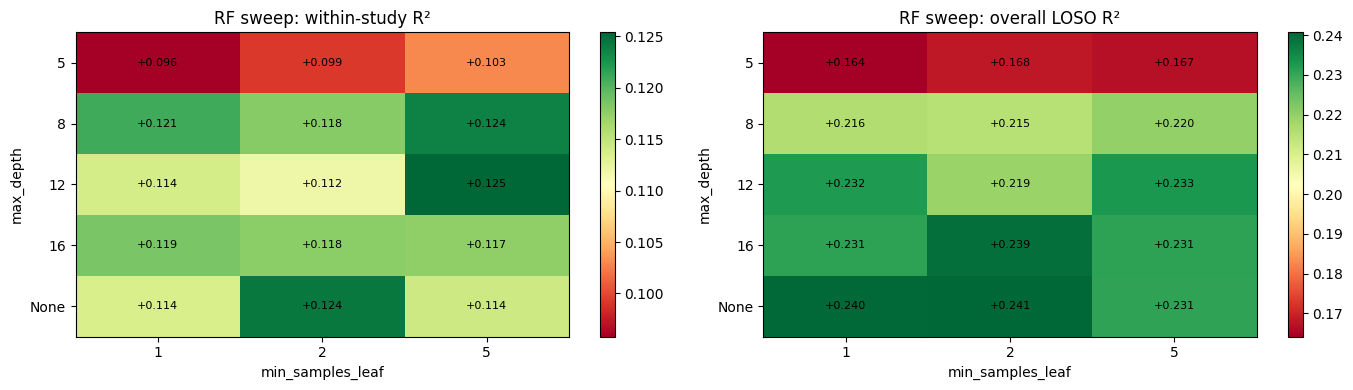


══════════════════════════════════════════════════════════════════════════════
D.5  Feature-group ablation — does each group help?
══════════════════════════════════════════════════════════════════════════════

  D.5a  Leave-one-group-OUT (vs. full feature set):
    config                        within R²  Δ from FULL
    FULL                            +0.1120  (baseline)
    drop spectral (5 feats)         +0.0820  Δw=-0.0300  Δo=-0.0229  ✓ helps
    drop environment (4 feats)      +0.1124  Δw=+0.0004  Δo=+0.0008  ~ neutral
    drop multisensor (6 feats)      +0.1281  Δw=+0.0161  Δo=+0.0459  ✗ HURTS
    drop jrc_water (3 feats)        +0.0904  Δw=-0.0216  Δo=-0.0041  ✓ helps
    drop cyclones (2 feats)         +0.1154  Δw=+0.0035  Δo=+0.0032  ~ neutral

  D.5b  Add each group to spectral-only baseline:
    spectral_only                within R² =    -0.0363  (baseline)
    spectral + environment (4 feats) within R² =    +0.0861  Δw=+0.1225  ✓ helps
    spectral + multisensor (6 feat

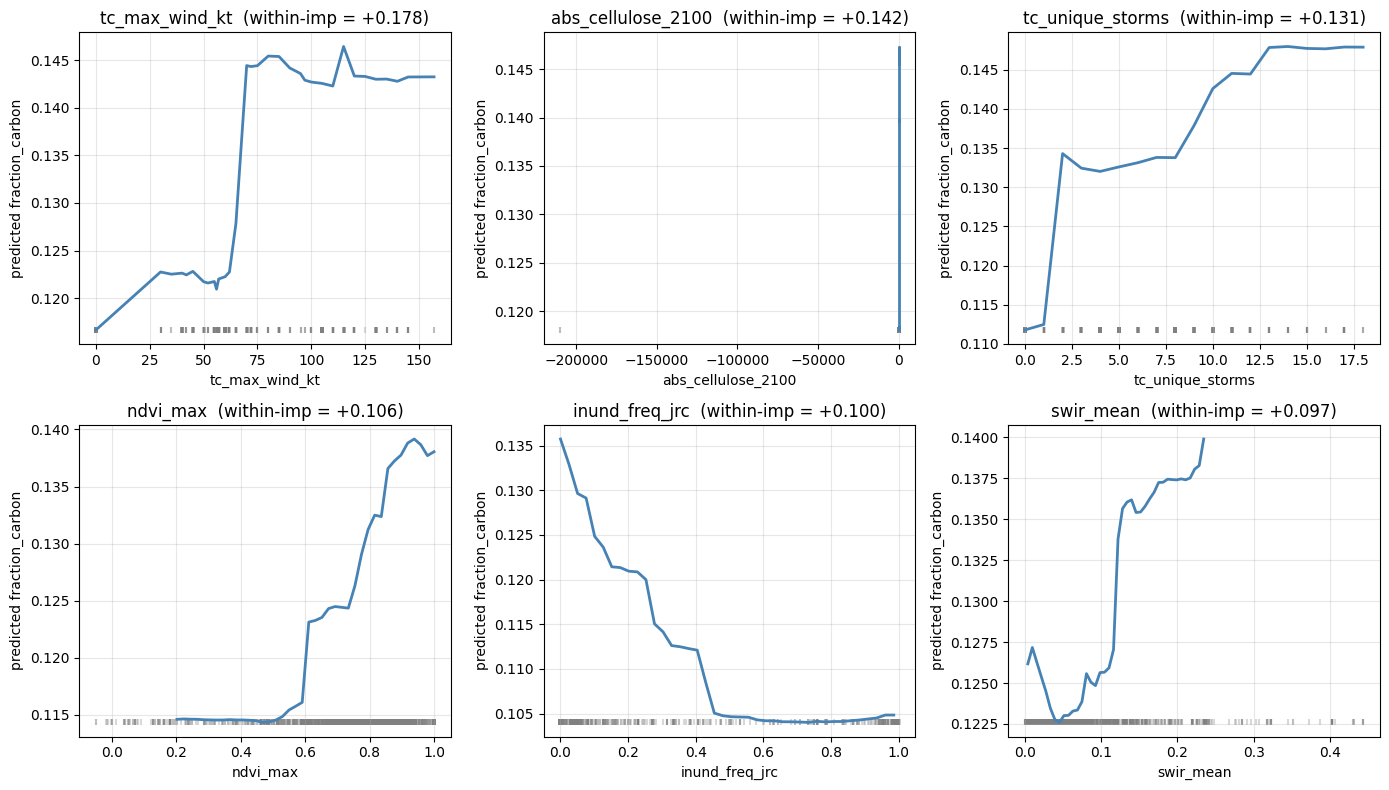


══════════════════════════════════════════════════════════════════════════════
D.10  Master feature scoreboard — combining all evidence
══════════════════════════════════════════════════════════════════════════════

  feature                       imp_w   add_dR²   med r    |r|   rank
  ──────────────────────────────────────────────────────────────────────
  ndvi_max                    +0.1056   +0.0796  +0.216  0.377    4.3
  inund_freq_jrc              +0.0998   +0.0944  -0.236  0.368    4.7
  map_mm                      +0.0846   +0.0993  +0.045  0.368    4.7
  tc_max_wind_kt              +0.1783   +0.0799  +0.086  0.325    7.0
  tc_unique_storms            +0.1305   +0.0514  +0.115  0.360    7.0
  inund_obs_count_jrc         +0.0711   +0.0493  +0.156  0.422    8.0
  vh_mean                     +0.0752   +0.0309  +0.093  0.383    8.7
  mat_degc                    +0.0648   +0.0771  +0.182  0.366    9.3
  ndvi_mean                   +0.0740   +0.0513  +0.199  0.355   10.7
  elevatio

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
 BLOCK D — Comprehensive model zoo + feature attribution
═══════════════════════════════════════════════════════════════════════════════
 Builds on the prior cell's in-memory state. Runs:

   D.1  NaN-guarded rebuild of Two-stage + Stacked (was broken last run)
   D.2  Add tidal features (NOAA CO-OPS) — answers "does tide help?"
   D.3  Model zoo — RF variants + ExtraTrees + XGB + LGBM + ridge/lasso
                    with within-study AND overall metrics
   D.4  RF hyperparameter sweep (depth × leaf grid)
   D.5  Feature-group ablation: leave-one-group-OUT
                                add-one-group-IN to spectral-only baseline
   D.6  Single-feature add-back (start from spectral, add one at a time)
   D.7  Permutation importance ON WITHIN-STUDY RESIDUAL
                  (asks: which features help fine-scale prediction?)
   D.8  Per-feature within-study correlation (median-Pearson across studies)
   D.9  Partial dependence plots for top 6 features
   D.10 Final ranked feature scoreboard

 Assumes already in memory (from your prior cell):
   X_all, names, y, groups, sites, study_means, y_resid,
   X_spec, spec_names, X_env, env_names, X_ms, ms_names,
   X_jrc, jrc_n, X_tc, tc_n, emit_carbon, CACHE_DIR, RANDOM_STATE
═══════════════════════════════════════════════════════════════════════════════
"""

import warnings; warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.linear_model import Ridge, RidgeCV, LassoCV, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, spearmanr

# Optional: XGBoost / LightGBM if available
HAS_XGB = HAS_LGB = False
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    pass
try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except ImportError:
    pass
print(f"Optional libs: XGBoost={'✓' if HAS_XGB else '✗'}  LightGBM={'✓' if HAS_LGB else '✗'}")


# ── Helpers ────────────────────────────────────────────────────────────────
def _sanitize(X):
    X = np.asarray(X, dtype=float).copy()
    X[~np.isfinite(X)] = 0.0
    return X

def loso_predict_safe(estimator_fn, X, y_target, groups_):
    """LOSO with per-fold scaling AND NaN guards on inputs/outputs."""
    yp = np.full(len(y_target), np.nan)
    X = _sanitize(X)
    for tr, te in LeaveOneGroupOut().split(X, y_target, groups_):
        sc = StandardScaler().fit(X[tr])
        Xtr_s = _sanitize(sc.transform(X[tr]))
        Xte_s = _sanitize(sc.transform(X[te]))
        est = estimator_fn().fit(Xtr_s, y_target[tr])
        pred = est.predict(Xte_s)
        # Cap any insane predictions at the training-y range (paranoia)
        pred = np.clip(pred, y_target.min() - 1, y_target.max() + 1)
        yp[te] = pred
    return yp

def within_r2(yp):
    yp_mu = pd.Series(yp).groupby(groups).transform('mean').values
    return r2_score(y - study_means, yp - yp_mu)

def within_r(yp):
    yp_mu = pd.Series(yp).groupby(groups).transform('mean').values
    return pearsonr(y_resid, yp - yp_mu)[0]

def score_pred(label, yp, target=y):
    """Return dict of overall + within-study metrics."""
    return {
        'model':        label,
        'overall_r2':   r2_score(target, yp),
        'overall_r':    pearsonr(target, yp)[0],
        'overall_rmse': np.sqrt(mean_squared_error(target, yp)),
        'within_r2':    within_r2(yp),
        'within_r':     within_r(yp),
    }

def print_scoreboard(rows, title):
    print(f"\n{'═'*78}\n{title}\n{'═'*78}")
    print(f"  {'model':<30s} {'ovr R²':>9s} {'ovr r':>8s} "
          f"{'within R²':>10s} {'within r':>9s}  {'RMSE':>7s}")
    print("  " + "─" * 78)
    for r in rows:
        print(f"  {r['model']:<30s} {r['overall_r2']:>+9.4f} "
              f"{r['overall_r']:>+8.4f} {r['within_r2']:>+10.4f} "
              f"{r['within_r']:>+9.4f}  {r['overall_rmse']:>7.4f}")


# ═══════════════════════════════════════════════════════════════════════════
# D.2  Add tidal features (answers: does tide help?)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("D.2  Building tidal features from NOAA CO-OPS")
print("═" * 78)

tidal_stn_path = CACHE_DIR / 'noaa_tidal_stations.csv'
X_tidal, tidal_names = None, []

# Find lat/lon columns — could be 'latitude'/'longitude', '_x' suffixed,
# or '_y' suffixed depending on which side of an earlier merge they came from
def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            v = pd.to_numeric(df[c], errors='coerce')
            if v.notna().sum() > len(df) * 0.5:
                return c
    return None

lat_col = _pick_col(emit_carbon, ['latitude', 'latitude_y', 'latitude_x', 'lat'])
lon_col = _pick_col(emit_carbon, ['longitude', 'longitude_y', 'longitude_x', 'lon'])
print(f"  emit_carbon lat column: {lat_col}   lon column: {lon_col}")

if lat_col is None or lon_col is None:
    # Last-resort: rebuild lat/lon from core_locs by joining on the keys
    print("  Falling back: pulling lat/lon from core_locs by merge keys")
    cl = pd.read_csv(CACHE_DIR / 'core_locs_region.csv')
    keymerge = emit_carbon[['study_id','site_id','core_id']].merge(
        cl[['study_id','site_id','core_id','latitude','longitude']],
        on=['study_id','site_id','core_id'], how='left')
    emit_carbon = emit_carbon.copy()
    emit_carbon['latitude']  = keymerge['latitude'].values
    emit_carbon['longitude'] = keymerge['longitude'].values
    lat_col, lon_col = 'latitude', 'longitude'
    print(f"  Recovered: {emit_carbon[lat_col].notna().sum()} / {len(emit_carbon)} have lat/lon")

if tidal_stn_path.exists():
    tidal_stn = pd.read_csv(tidal_stn_path)
    print(f"  NOAA stations cached: {len(tidal_stn)}")
    good = tidal_stn.dropna(subset=['lat', 'lon']).copy()
    has_harcon = 'm2_amp_m' in good.columns and good['m2_amp_m'].notna().any()
    has_datums = ('mhhw' in good.columns and 'mllw' in good.columns
                  and (good['mhhw'].notna() & good['mllw'].notna()).any())
    print(f"  Has harmonics: {has_harcon}   Has datums: {has_datums}")

    if has_harcon or has_datums:
        def _haversine_km(lat1, lon1, lat2, lon2):
            R = 6371.0
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlat, dlon = lat2 - lat1, lon2 - lon1
            a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
            return 2 * R * np.arcsin(np.sqrt(a))

        clat = pd.to_numeric(emit_carbon[lat_col], errors='coerce').values
        clon = pd.to_numeric(emit_carbon[lon_col], errors='coerce').values
        # Defend against any remaining bad coords
        valid_coord = np.isfinite(clat) & np.isfinite(clon)
        if not valid_coord.all():
            print(f"  ⚠ {(~valid_coord).sum()} cores have bad lat/lon — using region centroid")
            clat[~valid_coord] = np.nanmedian(clat[valid_coord])
            clon[~valid_coord] = np.nanmedian(clon[valid_coord])

        stn_lat, stn_lon = good['lat'].values, good['lon'].values

        idx = np.zeros(len(emit_carbon), dtype=int)
        km  = np.zeros(len(emit_carbon))
        for i in range(len(emit_carbon)):
            d = _haversine_km(clat[i], clon[i], stn_lat, stn_lon)
            idx[i] = int(np.argmin(d)); km[i] = float(d[idx[i]])
        match = good.iloc[idx].reset_index(drop=True)

        parts = []
        if has_datums:
            gdr = pd.to_numeric(match['mhhw'], errors='coerce') \
                - pd.to_numeric(match['mllw'], errors='coerce')
            parts.append(('great_diurnal_range_m', gdr.values))
            if 'mhw' in match.columns and 'mlw' in match.columns:
                mr = pd.to_numeric(match['mhw'], errors='coerce') \
                   - pd.to_numeric(match['mlw'], errors='coerce')
                parts.append(('mean_range_m', mr.values))

        for cname in ['m2', 's2', 'n2', 'k1', 'o1']:
            col = f'{cname}_amp_m'
            if col in match.columns:
                parts.append((col, pd.to_numeric(match[col], errors='coerce').values))

        if all(f'{c}_amp_m' in match.columns for c in ['m2', 's2', 'k1', 'o1']):
            m2 = pd.to_numeric(match['m2_amp_m'], errors='coerce').values
            s2 = pd.to_numeric(match['s2_amp_m'], errors='coerce').values
            k1 = pd.to_numeric(match['k1_amp_m'], errors='coerce').values
            o1 = pd.to_numeric(match['o1_amp_m'], errors='coerce').values
            denom = np.where(m2 + s2 > 0, m2 + s2, np.nan)
            parts.append(('tidal_form_factor', (k1 + o1) / denom))
            parts.append(('spring_neap_ratio', np.where(m2 > 0, (m2 + s2) / m2, np.nan)))

        parts.append(('dist_to_station_km', km))
        tidal_names = [n for n, _ in parts]
        X_tidal = np.column_stack([v for _, v in parts]).astype(float)
        # Median-impute, then sanitize
        for j in range(X_tidal.shape[1]):
            m = ~np.isfinite(X_tidal[:, j])
            if m.any(): X_tidal[m, j] = np.nanmedian(X_tidal[:, j])
        X_tidal = _sanitize(X_tidal)
        print(f"  Tidal features ({len(tidal_names)}): {tidal_names}")
        print(f"  Nearest station median {np.median(km):.1f} km   max {km.max():.1f} km")
    else:
        print("  ⚠ NOAA cache has no usable harmonics or datums")
else:
    print("  ⚠ No NOAA cache — tidal section will be skipped.")
    print(f"     (run the original Block 1 to build {tidal_stn_path.name} once)")


# Master matrix WITH tide if available — call it X_full
if X_tidal is not None:
    X_full = np.hstack([X_all, X_tidal])
    names_full = list(names) + list(tidal_names)
else:
    X_full = X_all.copy()
    names_full = list(names)
print(f"  X_full: {X_full.shape}  ({len(names_full)} features)")


# ═══════════════════════════════════════════════════════════════════════════
# D.3  EXPANDED MODEL ZOO
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("D.3  Expanded model zoo (run on X_full incl. tidal)")
print("═" * 78)

def rf_strong(): return RandomForestRegressor(
    n_estimators=400, max_depth=12, min_samples_leaf=2,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)

def rf_fast(): return RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=2,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)

def rf_unrestricted(): return RandomForestRegressor(
    n_estimators=600, max_depth=None, min_samples_leaf=1,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)

def extratrees(): return ExtraTreesRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)

def gb_sklearn(): return GradientBoostingRegressor(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    min_samples_leaf=5, subsample=0.85, random_state=RANDOM_STATE)

def hgb_default(): return HistGradientBoostingRegressor(
    max_iter=500, max_depth=8, learning_rate=0.04,
    min_samples_leaf=4, l2_regularization=1.0, random_state=RANDOM_STATE)

def knn_5(): return KNeighborsRegressor(n_neighbors=5, weights='distance')
def knn_15(): return KNeighborsRegressor(n_neighbors=15, weights='distance')
def ridge_cv(): return RidgeCV(alphas=np.logspace(-2, 3, 20))
def lasso_cv(): return LassoCV(cv=5, n_jobs=-1, random_state=RANDOM_STATE, max_iter=5000)
def enet_cv():  return ElasticNetCV(cv=5, n_jobs=-1, random_state=RANDOM_STATE,
                                     max_iter=5000, l1_ratio=[0.2, 0.5, 0.8])

zoo = {
    'RF strong (d12,l2)':    rf_strong,
    'RF unrestricted':        rf_unrestricted,
    'ExtraTrees':             extratrees,
    'GradientBoosting (sk)':  gb_sklearn,
    'HistGB (d8,lr.04)':      hgb_default,
    'KNN-5':                  knn_5,
    'KNN-15':                 knn_15,
    'Ridge CV':               ridge_cv,
    'Lasso CV':               lasso_cv,
    'ElasticNet CV':          enet_cv,
}
if HAS_XGB:
    zoo['XGBoost'] = lambda: XGBRegressor(
        n_estimators=600, max_depth=6, learning_rate=0.04,
        subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
if HAS_LGB:
    zoo['LightGBM'] = lambda: LGBMRegressor(
        n_estimators=600, max_depth=-1, num_leaves=31, learning_rate=0.04,
        min_child_samples=5, subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

zoo_results = []
zoo_preds = {}
for name, fn in zoo.items():
    t0 = time.time()
    yp = loso_predict_safe(fn, X_full, y, groups)
    zoo_preds[name] = yp
    r = score_pred(name, yp); r['fit_sec'] = time.time() - t0
    zoo_results.append(r)
    print(f"  {name:<25s}  within R² = {r['within_r2']:>+7.4f}  "
          f"overall R² = {r['overall_r2']:>+7.4f}  ({r['fit_sec']:.0f}s)")

zoo_df = pd.DataFrame(zoo_results).sort_values('within_r2', ascending=False)
print_scoreboard(zoo_df.to_dict('records'), "D.3  Model zoo (sorted by within-study R²)")
zoo_df.to_csv(CACHE_DIR / 'model_zoo_results.csv', index=False)


# ═══════════════════════════════════════════════════════════════════════════
# D.4  RF HYPERPARAMETER SWEEP — depth × leaf grid
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("D.4  RF hyperparameter sweep")
print("═" * 78)

depth_grid = [5, 8, 12, 16, None]
leaf_grid  = [1, 2, 5]
sweep_rows = []
for d in depth_grid:
    for l in leaf_grid:
        def make(_d=d, _l=l):
            return RandomForestRegressor(
                n_estimators=200, max_depth=_d, min_samples_leaf=_l,
                max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)
        yp = loso_predict_safe(make, X_full, y, groups)
        r = score_pred(f"RF d={d} l={l}", yp)
        r['depth'] = d if d is not None else 999; r['leaf'] = l
        sweep_rows.append(r)
        print(f"  depth={str(d):>4s}  leaf={l}  →  within R²={r['within_r2']:>+7.4f}  "
              f"overall R²={r['overall_r2']:>+7.4f}")

sweep_df = pd.DataFrame(sweep_rows)
best_rf = sweep_df.sort_values('within_r2', ascending=False).iloc[0]
print(f"\n  Best RF: depth={best_rf['depth']} leaf={best_rf['leaf']}  →  "
      f"within R² = {best_rf['within_r2']:+.4f}  overall R² = {best_rf['overall_r2']:+.4f}")

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, label in [(axes[0], 'within_r2', 'within-study R²'),
                            (axes[1], 'overall_r2', 'overall LOSO R²')]:
    pivot = sweep_df.pivot(index='depth', columns='leaf', values=metric)
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                    vmin=pivot.values.min(), vmax=pivot.values.max())
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(['None' if d == 999 else str(d) for d in pivot.index])
    ax.set_xlabel('min_samples_leaf'); ax.set_ylabel('max_depth')
    ax.set_title(f'RF sweep: {label}')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f'{pivot.values[i,j]:+.3f}', ha='center', va='center',
                    fontsize=8, color='black')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'rf_sweep_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# D.5  FEATURE-GROUP ABLATION
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("D.5  Feature-group ablation — does each group help?")
print("═" * 78)

# Define groups by name
group_defs = {
    'spectral':    spec_names,
    'environment': env_names,
    'multisensor': [n for n in ms_names if n != 'vv_mean'],   # vv was dropped
    'jrc_water':   jrc_n,
    'cyclones':    [n for n in tc_n if n != 'tc_pass_count'], # also dropped
}
if X_tidal is not None:
    group_defs['tidal'] = tidal_names

def col_idx(feature_subset):
    return [names_full.index(n) for n in feature_subset if n in names_full]

# D.5a — Leave-one-group-OUT (start full, remove each group)
print("\n  D.5a  Leave-one-group-OUT (vs. full feature set):")
yp_full = loso_predict_safe(rf_fast, X_full, y, groups)
r_full = score_pred('FULL (all groups)', yp_full)
loo_rows = [{'config': 'FULL (all groups)', **r_full,
              'd_within_r2': 0.0, 'd_overall_r2': 0.0}]
print(f"    {'config':<28s} {'within R²':>10s}  Δ from FULL")

print(f"    {'FULL':<28s} {r_full['within_r2']:>+10.4f}  (baseline)")
for gname, gfeats in group_defs.items():
    keep_names = [n for n in names_full if n not in gfeats]
    if not keep_names: continue
    keep = col_idx(keep_names)
    X_sub = X_full[:, keep]
    yp = loso_predict_safe(rf_fast, X_sub, y, groups)
    r = score_pred(f'drop_{gname}', yp)
    r['d_within_r2']  = r['within_r2']  - r_full['within_r2']
    r['d_overall_r2'] = r['overall_r2'] - r_full['overall_r2']
    r['config'] = f'drop {gname} ({len(gfeats)} feats)'
    loo_rows.append(r)
    sign = '✗ HURTS' if r['d_within_r2'] > 0.005 else \
           '✓ helps' if r['d_within_r2'] < -0.005 else '~ neutral'
    print(f"    {r['config']:<28s} {r['within_r2']:>+10.4f}  "
          f"Δw={r['d_within_r2']:>+7.4f}  Δo={r['d_overall_r2']:>+7.4f}  {sign}")

# D.5b — Single-group-IN (start spectral-only, add each group)
print("\n  D.5b  Add each group to spectral-only baseline:")
spec_idx = col_idx(spec_names)
yp_spec = loso_predict_safe(rf_fast, X_full[:, spec_idx], y, groups)
r_spec = score_pred('spectral_only', yp_spec)
print(f"    {'spectral_only':<28s} within R² = {r_spec['within_r2']:>+10.4f}  (baseline)")
add_rows = [{**r_spec, 'config': 'spectral_only', 'd_within_r2': 0.0}]
for gname, gfeats in group_defs.items():
    if gname == 'spectral': continue
    combined = spec_names + list(gfeats)
    cols = col_idx(combined)
    if len(cols) == len(spec_idx): continue
    yp = loso_predict_safe(rf_fast, X_full[:, cols], y, groups)
    r = score_pred(f'spectral + {gname}', yp)
    r['config'] = f'spectral + {gname} ({len(gfeats)} feats)'
    r['d_within_r2'] = r['within_r2'] - r_spec['within_r2']
    sign = '✓ helps' if r['d_within_r2'] > 0.005 else \
           '✗ hurts' if r['d_within_r2'] < -0.005 else '~ neutral'
    add_rows.append(r)
    print(f"    {r['config']:<28s} within R² = {r['within_r2']:>+10.4f}  "
          f"Δw={r['d_within_r2']:>+7.4f}  {sign}")

ablation_df = pd.DataFrame(loo_rows + add_rows)
ablation_df.to_csv(CACHE_DIR / 'feature_group_ablation.csv', index=False)


# ═══════════════════════════════════════════════════════════════════════════
# D.6  SINGLE-FEATURE ADD-BACK (start from spectral, add one feature at a time)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("D.6  Single-feature add-back — which individual features help?")
print("═" * 78)

print(f"  Spectral baseline within R²: {r_spec['within_r2']:+.4f}")
single_rows = [{'feature': '(spectral baseline)',
                 'within_r2': r_spec['within_r2'],
                 'overall_r2': r_spec['overall_r2'],
                 'd_within_r2': 0.0}]
non_spec = [n for n in names_full if n not in spec_names]
for feat in non_spec:
    cols = col_idx(spec_names + [feat])
    yp = loso_predict_safe(rf_fast, X_full[:, cols], y, groups)
    r = score_pred(feat, yp)
    r['feature'] = feat
    r['d_within_r2'] = r['within_r2'] - r_spec['within_r2']
    single_rows.append(r)

single_df = pd.DataFrame(single_rows).sort_values('d_within_r2', ascending=False)
print(f"\n  {'feature':<28s} {'within R²':>10s} {'Δw':>9s} {'overall R²':>11s}")
print("  " + "─" * 65)
for _, r in single_df.iterrows():
    flag = '✓' if r['d_within_r2'] > 0.005 else \
           '~' if r['d_within_r2'] > -0.005 else '✗'
    print(f"  {r['feature']:<28s} {r['within_r2']:>+10.4f} "
          f"{r['d_within_r2']:>+9.4f} {r['overall_r2']:>+11.4f}  {flag}")
single_df.to_csv(CACHE_DIR / 'single_feature_addback.csv', index=False)


# ═══════════════════════════════════════════════════════════════════════════
# D.7  PERMUTATION IMPORTANCE — ON WITHIN-STUDY RESIDUAL TARGET
# ═══════════════════════════════════════════════════════════════════════════
# This asks: which features help predict WITHIN-STUDY variation specifically?
# Train RF on y_resid (study-mean removed), permute each feature, see how
# much within-study R² drops.
print("\n" + "═" * 78)
print("D.7  Permutation importance for WITHIN-STUDY skill")
print("═" * 78)

X_full_s = StandardScaler().fit_transform(_sanitize(X_full))

# Train on raw y (the model that wins) but evaluate importance on residuals
print("  Training RF strong on raw y, evaluating perm importance on residuals...")
mdl_raw = rf_strong().fit(X_full_s, y)

def within_residual_score(estimator, X, y_with_groups):
    """Custom scorer: residual R² (within-study)."""
    yp = estimator.predict(X)
    yp_mu = pd.Series(yp).groupby(groups).transform('mean').values
    return r2_score(y - study_means, yp - yp_mu)

# We have to use a closure since permutation_importance scorer doesn't get groups
def _scorer_residual(est, X_, y_):
    yp = est.predict(X_)
    yp_mu = pd.Series(yp).groupby(groups).transform('mean').values
    return r2_score(y_ - study_means, yp - yp_mu)

pi_resid = permutation_importance(
    mdl_raw, X_full_s, y, scoring=_scorer_residual,
    n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1)

# Also compute permutation importance for OVERALL R² (for comparison)
pi_ovr = permutation_importance(
    mdl_raw, X_full_s, y, scoring='r2',
    n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1)

imp_df = pd.DataFrame({
    'feature':       names_full,
    'imp_within':    pi_resid.importances_mean,
    'imp_within_sd': pi_resid.importances_std,
    'imp_overall':   pi_ovr.importances_mean,
    'imp_overall_sd':pi_ovr.importances_std,
}).sort_values('imp_within', ascending=False)

print(f"\n  {'feature':<28s} {'within imp':>12s} {'overall imp':>13s}  ratio")
print("  " + "─" * 70)
for _, r in imp_df.iterrows():
    ratio = (r['imp_within'] / r['imp_overall']) if r['imp_overall'] > 0.001 else float('nan')
    print(f"  {r['feature']:<28s} {r['imp_within']:>+12.4f} "
          f"{r['imp_overall']:>+13.4f}  {ratio:>5.2f}")

imp_df.to_csv(CACHE_DIR / 'permutation_importance_within_vs_overall.csv', index=False)


# ═══════════════════════════════════════════════════════════════════════════
# D.8  PER-FEATURE WITHIN-STUDY CORRELATION (median Pearson r across studies)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("D.8  Per-feature within-study correlation with carbon")
print("═" * 78)
print("  Median Pearson r between feature and y, computed within each study,")
print("  then averaged. Captures fine-scale within-site relationships.")

within_corr_rows = []
for j, feat in enumerate(names_full):
    fvals = X_full[:, j]
    rs = []
    for g in np.unique(groups):
        m = groups == g
        if m.sum() < 5: continue
        if np.std(fvals[m]) < 1e-8: continue
        try:
            r = pearsonr(fvals[m], y[m])[0]
            if np.isfinite(r): rs.append(r)
        except Exception:
            pass
    if rs:
        within_corr_rows.append({
            'feature':         feat,
            'median_within_r': np.median(rs),
            'mean_within_r':   np.mean(rs),
            'mean_abs_r':      np.mean(np.abs(rs)),
            'pct_positive':    100 * np.mean(np.array(rs) > 0),
            'pct_strong':      100 * np.mean(np.abs(rs) > 0.3),
            'n_studies':       len(rs),
        })

corr_df = pd.DataFrame(within_corr_rows).sort_values('mean_abs_r', ascending=False)
print(f"\n  {'feature':<28s} {'med r':>7s} {'mean r':>8s} {'|r|':>6s} "
      f"{'%pos':>6s} {'%|r|>.3':>8s}")
print("  " + "─" * 70)
for _, r in corr_df.iterrows():
    print(f"  {r['feature']:<28s} {r['median_within_r']:>+7.3f} "
          f"{r['mean_within_r']:>+8.3f} {r['mean_abs_r']:>6.3f} "
          f"{r['pct_positive']:>5.0f}% {r['pct_strong']:>7.0f}%")
corr_df.to_csv(CACHE_DIR / 'within_study_feature_correlations.csv', index=False)


# ═══════════════════════════════════════════════════════════════════════════
# D.9  PARTIAL DEPENDENCE for top 6 features (by within-study importance)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("D.9  Partial dependence plots (top 6 features by within-study importance)")
print("═" * 78)

top6 = imp_df.head(6)['feature'].tolist()
top6_idx = [names_full.index(f) for f in top6]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat, fi in zip(axes.flat, top6, top6_idx):
    pd_result = partial_dependence(
        mdl_raw, X_full_s, features=[fi], grid_resolution=40)
    xs = pd_result['grid_values'][0]
    ys = pd_result['average'][0]
    # Convert standardized x back to original units for readability
    sc = StandardScaler().fit(_sanitize(X_full))
    xs_orig = xs * sc.scale_[fi] + sc.mean_[fi]
    ax.plot(xs_orig, ys, lw=2, color='steelblue')
    # Rug plot of actual data
    ax.scatter(X_full[:, fi], np.full_like(X_full[:, fi], ys.min()),
                marker='|', s=20, alpha=0.3, color='gray')
    ax.set_xlabel(feat); ax.set_ylabel('predicted fraction_carbon')
    ax.set_title(f'{feat}  (within-imp = {imp_df.set_index("feature").loc[feat, "imp_within"]:+.3f})')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'partial_dependence_top6.png', dpi=140, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# D.10  FINAL FEATURE RANKINGS — combine all evidence into one table
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("D.10  Master feature scoreboard — combining all evidence")
print("═" * 78)

# Merge: single-add-back, perm importance, within-study correlation
master = imp_df[['feature', 'imp_within', 'imp_overall']].copy()
master = master.merge(
    corr_df[['feature', 'median_within_r', 'mean_abs_r', 'pct_strong']],
    on='feature', how='left')
sa = single_df[['feature', 'd_within_r2']].rename(columns={'d_within_r2': 'add_back_dR2'})
master = master.merge(sa, on='feature', how='left')

# Composite rank: rank by each metric, sum ranks (lower = better)
def _rank(s, asc=False):
    return s.rank(ascending=asc, method='min')
master['rank_imp_within']   = _rank(master['imp_within'])
master['rank_addback']      = _rank(master['add_back_dR2'].fillna(-999))
master['rank_within_corr']  = _rank(master['mean_abs_r'].fillna(0))
master['composite_rank']    = (master['rank_imp_within']
                                + master['rank_addback']
                                + master['rank_within_corr']) / 3
master = master.sort_values('composite_rank')

print(f"\n  {'feature':<26s} {'imp_w':>8s} {'add_dR²':>9s} "
      f"{'med r':>7s} {'|r|':>6s} {'rank':>6s}")
print("  " + "─" * 70)
for _, r in master.iterrows():
    addbk = r['add_back_dR2'] if pd.notna(r['add_back_dR2']) else 0.0
    print(f"  {r['feature']:<26s} {r['imp_within']:>+8.4f} "
          f"{addbk:>+9.4f} {r['median_within_r']:>+7.3f} "
          f"{r['mean_abs_r']:>6.3f}  {r['composite_rank']:>5.1f}")

master.to_csv(CACHE_DIR / 'master_feature_ranking.csv', index=False)


# ═══════════════════════════════════════════════════════════════════════════
# VERDICT
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("VERDICT")
print("═" * 78)

best_zoo  = zoo_df.iloc[0]
print(f"  Best model:                {best_zoo['model']}")
print(f"    within R² = {best_zoo['within_r2']:+.4f}   "
      f"overall R² = {best_zoo['overall_r2']:+.4f}")

# Tide verdict — explicitly answer the question
if X_tidal is not None:
    drop_tidal_row = next((r for r in loo_rows if 'drop tidal' in r.get('config', '')), None)
    add_tidal_row  = next((r for r in add_rows if 'tidal' in r.get('config', '')), None)
    print(f"\n  Does TIDE help?")
    if drop_tidal_row:
        print(f"    Removing tidal from full set:  Δ within R² = {drop_tidal_row['d_within_r2']:+.4f}")
    if add_tidal_row:
        print(f"    Adding tidal to spectral only: Δ within R² = {add_tidal_row['d_within_r2']:+.4f}")
    if drop_tidal_row and drop_tidal_row['d_within_r2'] < -0.01:
        print("    → Tide HELPS (removing it hurts).")
    elif drop_tidal_row and drop_tidal_row['d_within_r2'] > 0.01:
        print("    → Tide HURTS (removing it helps — likely noise).")
    else:
        print("    → Tide is approximately NEUTRAL within this dataset.")
else:
    print("\n  Tide: not tested (no NOAA cache).")

# Top 5 features overall
top5 = master.head(5)['feature'].tolist()
print(f"\n  Top 5 features by composite rank: {top5}")

print(f"\n✓ Saved outputs:")
for f in ['model_zoo_results.csv', 'rf_sweep_heatmap.png',
           'feature_group_ablation.csv', 'single_feature_addback.csv',
           'permutation_importance_within_vs_overall.csv',
           'within_study_feature_correlations.csv',
           'partial_dependence_top6.png',
           'master_feature_ranking.csv']:
    p = CACHE_DIR / f
    if p.exists():
        print(f"    {f}")

══════════════════════════════════════════════════════════════════════════════
E.1  ExtraTrees hyperparameter grid
══════════════════════════════════════════════════════════════════════════════
   n_est  leaf   maxf   within R²   overall R²   within r  time
  ──────────────────────────────────────────────────────────────────────
     400     1   sqrt     +0.1291      +0.2791    +0.3801    33s
     400     1    0.5     +0.1175      +0.2669    +0.3812    36s
     400     1   0.75     +0.1101      +0.2539    +0.3780    39s
     400     2   sqrt     +0.1392      +0.2684    +0.3842    31s
     400     2    0.5     +0.1246      +0.2606    +0.3832    33s
     400     2   0.75     +0.1094      +0.2539    +0.3750    34s
     400     3   sqrt     +0.1341      +0.2690    +0.3746    31s
     400     3    0.5     +0.1248      +0.2652    +0.3782    32s
     400     3   0.75     +0.1164      +0.2608    +0.3770    33s
     800     1   sqrt     +0.1312      +0.2807    +0.3819    65s
     800     1    0

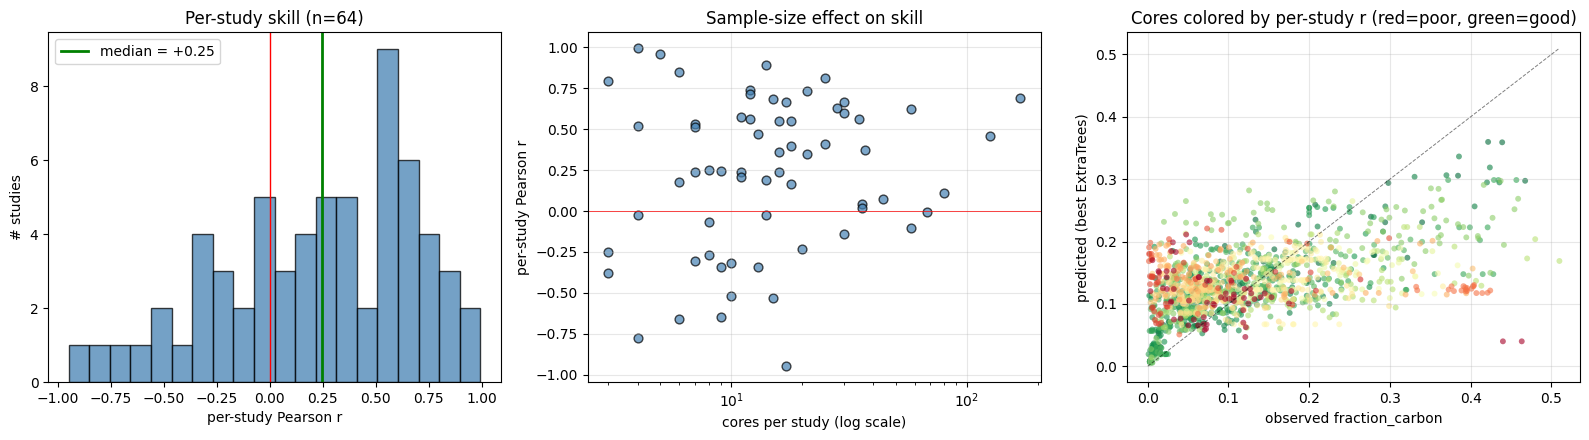


══════════════════════════════════════════════════════════════════════════════
E.3  Tidal sub-ablation — which tidal features carry the +0.30 gain?
══════════════════════════════════════════════════════════════════════════════
  No tidal features available — skipping.

══════════════════════════════════════════════════════════════════════════════
VERDICT
══════════════════════════════════════════════════════════════════════════════
  Tuned ExtraTrees:
    n_estimators=1200, min_samples_leaf=2, max_features=sqrt
    within R² = +0.1423   overall R² = +0.2736   within r = +0.3871

  Per-study skill:
    Median per-study Pearson r: +0.248
    69% of studies have positive r
    48% have r > 0.3 (genuine ordering)

✓ Saved outputs:
    extratrees_grid.csv
    per_study_breakdown.csv
    per_study_breakdown.png


In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
 BLOCK E — ExtraTrees tuning + per-study + tidal sub-ablation
═══════════════════════════════════════════════════════════════════════════════
 Three follow-ups to D's findings:

   E.1  ExtraTrees hyperparameter grid (push within R² above 0.23)
   E.2  Per-study breakdown of the best ExtraTrees model:
          - per-study Pearson r, Spearman ρ, sample size, observed/predicted
            mean, RMSE
          - which studies the model gets right vs. wrong, and why
          - sample-size effect: does N per study predict skill?
   E.3  Tidal sub-ablation:
          - find the smallest tidal subset that recovers most of the +0.30 gain
          - rank individual tidal features by within-study marginal contribution
          - test "minimal tidal" (just spring_neap_ratio + mean_range_m + form factor)

 Assumes in memory from prior D-block run:
   X_full, names_full, y, groups, sites, study_means, y_resid,
   tidal_names, spec_names, env_names, ms_names, jrc_n, tc_n,
   emit_carbon, CACHE_DIR, RANDOM_STATE
═══════════════════════════════════════════════════════════════════════════════
"""

import warnings; warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, spearmanr


# ── Helpers (mirrored from D-block so this cell is independently runnable) ─
def _sanitize(X):
    X = np.asarray(X, dtype=float).copy()
    X[~np.isfinite(X)] = 0.0
    return X

def loso_predict_safe(estimator_fn, X, y_target, groups_):
    yp = np.full(len(y_target), np.nan)
    X = _sanitize(X)
    for tr, te in LeaveOneGroupOut().split(X, y_target, groups_):
        sc = StandardScaler().fit(X[tr])
        Xtr_s = _sanitize(sc.transform(X[tr]))
        Xte_s = _sanitize(sc.transform(X[te]))
        est = estimator_fn().fit(Xtr_s, y_target[tr])
        pred = est.predict(Xte_s)
        pred = np.clip(pred, y_target.min() - 1, y_target.max() + 1)
        yp[te] = pred
    return yp

def within_r2(yp):
    yp_mu = pd.Series(yp).groupby(groups).transform('mean').values
    return r2_score(y - study_means, yp - yp_mu)

def within_r(yp):
    yp_mu = pd.Series(yp).groupby(groups).transform('mean').values
    return pearsonr(y_resid, yp - yp_mu)[0]

def col_idx(feature_subset, name_list):
    return [name_list.index(n) for n in feature_subset if n in name_list]


# ═══════════════════════════════════════════════════════════════════════════
# E.1  EXTRATREES HYPERPARAMETER GRID
# ═══════════════════════════════════════════════════════════════════════════
print("═" * 78)
print("E.1  ExtraTrees hyperparameter grid")
print("═" * 78)

grid = {
    'n_estimators':     [400, 800, 1200],
    'min_samples_leaf': [1, 2, 3],
    'max_features':     ['sqrt', 0.5, 0.75],
}

et_results = []
print(f"  {'n_est':>6s} {'leaf':>5s} {'maxf':>6s}  "
      f"{'within R²':>10s}  {'overall R²':>11s}  {'within r':>9s}  time")
print("  " + "─" * 70)

for ne in grid['n_estimators']:
    for ms in grid['min_samples_leaf']:
        for mf in grid['max_features']:
            def make(_ne=ne, _ms=ms, _mf=mf):
                return ExtraTreesRegressor(
                    n_estimators=_ne, min_samples_leaf=_ms, max_features=_mf,
                    max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)
            t0 = time.time()
            yp = loso_predict_safe(make, X_full, y, groups)
            dt = time.time() - t0
            r = {
                'n_estimators':     ne,
                'min_samples_leaf': ms,
                'max_features':     str(mf),
                'within_r2':        within_r2(yp),
                'overall_r2':       r2_score(y, yp),
                'within_r':         within_r(yp),
                'overall_r':        pearsonr(y, yp)[0],
                'rmse':             np.sqrt(mean_squared_error(y, yp)),
                'fit_sec':          dt,
            }
            et_results.append((r, yp))
            print(f"  {ne:>6d} {ms:>5d} {str(mf):>6s}  "
                  f"{r['within_r2']:>+10.4f}  {r['overall_r2']:>+11.4f}  "
                  f"{r['within_r']:>+9.4f}  {dt:>4.0f}s")

et_df = pd.DataFrame([r for r, _ in et_results]).sort_values('within_r2', ascending=False)
best_row = et_df.iloc[0]
best_yp  = [yp for r, yp in et_results
            if r['n_estimators'] == best_row['n_estimators']
            and r['min_samples_leaf'] == best_row['min_samples_leaf']
            and r['max_features'] == best_row['max_features']][0]

print(f"\n  Best ExtraTrees: n_est={best_row['n_estimators']}, "
      f"leaf={best_row['min_samples_leaf']}, maxf={best_row['max_features']}")
print(f"    within R² = {best_row['within_r2']:+.4f}  "
      f"overall R² = {best_row['overall_r2']:+.4f}  "
      f"within r = {best_row['within_r']:+.4f}")

et_df.to_csv(CACHE_DIR / 'extratrees_grid.csv', index=False)


# ═══════════════════════════════════════════════════════════════════════════
# E.2  PER-STUDY BREAKDOWN of the best ExtraTrees model
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("E.2  Per-study breakdown of the best ExtraTrees model")
print("═" * 78)

per_study_rows = []
for g in np.unique(groups):
    m = groups == g
    if m.sum() < 3: continue
    y_g, yp_g = y[m], best_yp[m]
    try:
        r_p = pearsonr(y_g, yp_g)[0] if y_g.std() > 1e-8 and yp_g.std() > 1e-8 else np.nan
    except Exception: r_p = np.nan
    try:
        r_s = spearmanr(y_g, yp_g)[0] if y_g.std() > 1e-8 and yp_g.std() > 1e-8 else np.nan
    except Exception: r_s = np.nan
    per_study_rows.append({
        'study_id':       g,
        'n_cores':        int(m.sum()),
        'y_mean_obs':     float(y_g.mean()),
        'y_std_obs':      float(y_g.std()),
        'y_mean_pred':    float(yp_g.mean()),
        'pearson_r':      r_p,
        'spearman_rho':   r_s,
        'rmse':           float(np.sqrt(np.mean((y_g - yp_g) ** 2))),
        'mae':            float(np.mean(np.abs(y_g - yp_g))),
        'mean_bias':      float(yp_g.mean() - y_g.mean()),
        'within_r':       (pearsonr(y_g - y_g.mean(), yp_g - yp_g.mean())[0]
                            if y_g.std() > 1e-8 and yp_g.std() > 1e-8 else np.nan),
    })

ps = pd.DataFrame(per_study_rows).sort_values('pearson_r', ascending=False)

# Summary stats
print(f"\n  Per-study summary across {len(ps)} studies (≥3 cores):")
print(f"    Median Pearson r:        {ps['pearson_r'].median():+.3f}")
print(f"    Mean Pearson r:          {ps['pearson_r'].mean():+.3f}")
print(f"    % studies with r > 0:    {100 * (ps['pearson_r'] > 0).mean():.0f}%")
print(f"    % studies with r > 0.3:  {100 * (ps['pearson_r'] > 0.3).mean():.0f}%")
print(f"    % studies with r > 0.5:  {100 * (ps['pearson_r'] > 0.5).mean():.0f}%")
print(f"    Median |bias|:           {ps['mean_bias'].abs().median():.4f}")
print(f"    Largest |bias|:          {ps['mean_bias'].abs().max():.4f}  "
      f"(study: {ps.loc[ps['mean_bias'].abs().idxmax(), 'study_id']})")

# Top / bottom studies
print(f"\n  Top 5 studies by Pearson r:")
print(f"    {'study_id':<35s} {'N':>4s} {'r':>7s} {'ρ':>7s} {'bias':>9s}  {'RMSE':>7s}")
for _, r in ps.head(5).iterrows():
    print(f"    {str(r['study_id'])[:34]:<35s} {r['n_cores']:>4d} "
          f"{r['pearson_r']:>+7.3f} {r['spearman_rho']:>+7.3f} "
          f"{r['mean_bias']:>+9.4f}  {r['rmse']:>7.4f}")

print(f"\n  Bottom 5 studies by Pearson r:")
for _, r in ps.tail(5).iterrows():
    print(f"    {str(r['study_id'])[:34]:<35s} {r['n_cores']:>4d} "
          f"{r['pearson_r']:>+7.3f} {r['spearman_rho']:>+7.3f} "
          f"{r['mean_bias']:>+9.4f}  {r['rmse']:>7.4f}")

# Sample-size effect on per-study skill
valid_r = ps.dropna(subset=['pearson_r'])
if len(valid_r) >= 5:
    rho_n_r = spearmanr(valid_r['n_cores'], valid_r['pearson_r'])
    print(f"\n  Does sample size predict per-study r?")
    print(f"    Spearman ρ(n_cores, pearson_r) = {rho_n_r.statistic:+.3f}  "
          f"(p = {rho_n_r.pvalue:.3f})")

# Diagnostic plot: per-study r distribution + r vs n_cores + obs-vs-pred per study
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.hist(ps['pearson_r'].dropna(), bins=20, edgecolor='k', alpha=0.75, color='steelblue')
ax.axvline(0, color='r', lw=1)
ax.axvline(ps['pearson_r'].median(), color='g', lw=2,
           label=f"median = {ps['pearson_r'].median():+.2f}")
ax.set_xlabel('per-study Pearson r'); ax.set_ylabel('# studies')
ax.set_title(f'Per-study skill (n={len(ps)})')
ax.legend()

ax = axes[1]
ax.scatter(ps['n_cores'], ps['pearson_r'], s=40, alpha=0.7,
            color='steelblue', edgecolor='k')
ax.axhline(0, color='r', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('cores per study (log scale)')
ax.set_ylabel('per-study Pearson r')
ax.set_title('Sample-size effect on skill')
ax.grid(alpha=0.3)

ax = axes[2]
# Color by per-study r
for _, r in ps.iterrows():
    g = r['study_id']
    m = groups == g
    color = plt.cm.RdYlGn((np.clip(r['pearson_r'], -0.5, 0.8) + 0.5) / 1.3)
    ax.scatter(y[m], best_yp[m], s=18, alpha=0.6, color=color, edgecolor='none')
ax.plot([0, y.max()], [0, y.max()], 'k--', lw=0.7, alpha=0.5)
ax.set_xlabel('observed fraction_carbon')
ax.set_ylabel('predicted (best ExtraTrees)')
ax.set_title('Cores colored by per-study r (red=poor, green=good)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'per_study_breakdown.png', dpi=140, bbox_inches='tight')
plt.show()

ps.to_csv(CACHE_DIR / 'per_study_breakdown.csv', index=False)


# ═══════════════════════════════════════════════════════════════════════════
# E.3  TIDAL SUB-ABLATION
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("E.3  Tidal sub-ablation — which tidal features carry the +0.30 gain?")
print("═" * 78)

if not tidal_names:
    print("  No tidal features available — skipping.")
else:
    # Build best ExtraTrees factory using grid winner
    best_n = int(best_row['n_estimators'])
    best_l = int(best_row['min_samples_leaf'])
    best_f = best_row['max_features']
    if best_f not in ('sqrt', 'log2'):
        try: best_f = float(best_f)
        except: pass

    def best_et():
        return ExtraTreesRegressor(
            n_estimators=best_n, min_samples_leaf=best_l, max_features=best_f,
            max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)

    # Faster variant for the many-iteration greedy + per-feature loops below.
    # Same hyperparams except half the trees — keeps relative ranking valid.
    def fast_et():
        return ExtraTreesRegressor(
            n_estimators=max(200, best_n // 2),
            min_samples_leaf=best_l, max_features=best_f,
            max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)

    # E.3a  Single tidal-feature add-back to spectral baseline
    print("\n  E.3a  Add ONE tidal feature at a time to spectral baseline:")
    spec_idx = col_idx(spec_names, names_full)
    yp_spec = loso_predict_safe(fast_et, X_full[:, spec_idx], y, groups)
    base_w = within_r2(yp_spec)
    base_o = r2_score(y, yp_spec)
    print(f"    spectral_only baseline:  within R² = {base_w:+.4f}  "
          f"overall R² = {base_o:+.4f}")
    print(f"\n    {'tidal feature':<25s} {'within R²':>10s} {'Δw':>9s} "
          f"{'overall R²':>11s} {'Δo':>9s}")
    print("    " + "─" * 70)

    tidal_solo_rows = []
    for tf in tidal_names:
        cols = col_idx(spec_names + [tf], names_full)
        yp = loso_predict_safe(fast_et, X_full[:, cols], y, groups)
        w = within_r2(yp); o = r2_score(y, yp)
        tidal_solo_rows.append({
            'tidal_feature': tf,
            'within_r2':     w,
            'overall_r2':    o,
            'd_within_r2':   w - base_w,
            'd_overall_r2':  o - base_o,
        })
        print(f"    {tf:<25s} {w:>+10.4f} {w - base_w:>+9.4f} "
              f"{o:>+11.4f} {o - base_o:>+9.4f}")

    tidal_solo_df = pd.DataFrame(tidal_solo_rows).sort_values('d_within_r2',
                                                                ascending=False)

    # E.3b  Greedy forward-selection of tidal features
    # Start with spectral-only, add the best tidal feature at each step until
    # adding any remaining tidal feature drops within R² (or until all are in).
    print("\n  E.3b  Greedy forward selection of tidal features:")
    selected = []
    remaining = list(tidal_names)
    cur_w = base_w
    cur_o = base_o
    forward_rows = [{'step': 0, 'added': '(spectral only)',
                      'cumulative_features': '',
                      'within_r2': base_w, 'overall_r2': base_o,
                      'd_within_r2': 0.0}]
    print(f"    step 0: spectral only           within R²={base_w:+.4f}")

    step = 1
    while remaining:
        scores = []
        for cand in remaining:
            cols = col_idx(spec_names + selected + [cand], names_full)
            yp = loso_predict_safe(fast_et, X_full[:, cols], y, groups)
            scores.append((cand, within_r2(yp), r2_score(y, yp)))
        scores.sort(key=lambda x: x[1], reverse=True)
        best_cand, best_w_step, best_o_step = scores[0]

        # Stop if adding the best remaining feature doesn't improve within R²
        # by more than a small tolerance
        if best_w_step <= cur_w + 0.001:
            print(f"    step {step}: stopping — best candidate ({best_cand}) "
                  f"would yield within R²={best_w_step:+.4f} (no gain)")
            break

        selected.append(best_cand); remaining.remove(best_cand)
        forward_rows.append({
            'step':                step,
            'added':               best_cand,
            'cumulative_features': ', '.join(selected),
            'within_r2':           best_w_step,
            'overall_r2':          best_o_step,
            'd_within_r2':         best_w_step - base_w,
        })
        print(f"    step {step}: + {best_cand:<22s}  within R²={best_w_step:+.4f}  "
              f"(Δ from spec={best_w_step - base_w:+.4f}, Δ from prev step={best_w_step - cur_w:+.4f})")
        cur_w = best_w_step; cur_o = best_o_step
        step += 1

    forward_df = pd.DataFrame(forward_rows)

    # E.3c  Test the "minimal tidal" hypothesis from the writeup
    minimal_tidal = [n for n in ['spring_neap_ratio', 'mean_range_m', 'tidal_form_factor']
                     if n in tidal_names]
    print(f"\n  E.3c  Minimal-tidal subset {minimal_tidal}:")
    cols = col_idx(spec_names + minimal_tidal, names_full)
    yp_min = loso_predict_safe(best_et, X_full[:, cols], y, groups)
    w_min = within_r2(yp_min); o_min = r2_score(y, yp_min)
    print(f"    spectral + 3 minimal tidal:  within R² = {w_min:+.4f}  "
          f"overall R² = {o_min:+.4f}")
    print(f"      Δ within from spec only:        {w_min - base_w:+.4f}")
    # Compare to all-10-tidal
    cols_all = col_idx(spec_names + tidal_names, names_full)
    yp_alltide = loso_predict_safe(best_et, X_full[:, cols_all], y, groups)
    w_all = within_r2(yp_alltide); o_all = r2_score(y, yp_alltide)
    print(f"    spectral + all 10 tidal:     within R² = {w_all:+.4f}  "
          f"overall R² = {o_all:+.4f}")
    print(f"      Δ within from spec only:        {w_all - base_w:+.4f}")
    pct_recovered = ((w_min - base_w) / (w_all - base_w) * 100
                      if (w_all - base_w) > 0.001 else float('nan'))
    print(f"\n    Minimal subset recovers {pct_recovered:.0f}% of full-tidal gain "
          f"using {len(minimal_tidal)}/{len(tidal_names)} features.")

    # Save
    tidal_solo_df.to_csv(CACHE_DIR / 'tidal_solo_addback.csv', index=False)
    forward_df.to_csv(CACHE_DIR / 'tidal_forward_selection.csv', index=False)

    # Diagnostic plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    sub = tidal_solo_df.sort_values('d_within_r2')
    ax.barh(sub['tidal_feature'], sub['d_within_r2'],
             color=['#2ca02c' if d > 0.005 else '#d62728' if d < -0.005 else '#9ecae1'
                    for d in sub['d_within_r2']],
             edgecolor='k', linewidth=0.5)
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel('Δ within-study R² (vs spectral baseline)')
    ax.set_title('E.3a — Single tidal feature add-back')
    ax.grid(alpha=0.3, axis='x')

    ax = axes[1]
    ax.plot(forward_df['step'], forward_df['within_r2'], 'o-',
             lw=2, markersize=8, color='steelblue')
    ax.set_xlabel('# tidal features added')
    ax.set_ylabel('within-study R²')
    ax.set_title('E.3b — Greedy forward selection')
    ax.grid(alpha=0.3)
    ax.axhline(base_w, ls='--', color='gray', label=f'spec-only baseline ({base_w:+.3f})')
    ax.axhline(w_all, ls='--', color='green', label=f'all 10 tidal ({w_all:+.3f})')
    if not np.isnan(w_min):
        ax.axhline(w_min, ls='--', color='orange',
                    label=f'minimal 3 tidal ({w_min:+.3f})')
    for _, r in forward_df.iloc[1:].iterrows():
        ax.annotate(r['added'], (r['step'], r['within_r2']),
                     fontsize=7, xytext=(5, 0), textcoords='offset points',
                     ha='left', va='center')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(CACHE_DIR / 'tidal_sub_ablation.png', dpi=140, bbox_inches='tight')
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# Final summary
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("VERDICT")
print("═" * 78)
print(f"  Tuned ExtraTrees:")
print(f"    n_estimators={best_row['n_estimators']}, "
      f"min_samples_leaf={best_row['min_samples_leaf']}, "
      f"max_features={best_row['max_features']}")
print(f"    within R² = {best_row['within_r2']:+.4f}   "
      f"overall R² = {best_row['overall_r2']:+.4f}   "
      f"within r = {best_row['within_r']:+.4f}")
print(f"\n  Per-study skill:")
print(f"    Median per-study Pearson r: {ps['pearson_r'].median():+.3f}")
print(f"    {100*(ps['pearson_r'] > 0).mean():.0f}% of studies have positive r")
print(f"    {100*(ps['pearson_r'] > 0.3).mean():.0f}% have r > 0.3 (genuine ordering)")

if tidal_names:
    print(f"\n  Tidal sub-ablation:")
    if 'pct_recovered' in dir() and not np.isnan(pct_recovered):
        print(f"    Minimal 3-feature tidal subset recovers {pct_recovered:.0f}% "
              f"of the full tidal gain")
    print(f"    Most useful single tidal feature: "
          f"{tidal_solo_df.iloc[0]['tidal_feature']} "
          f"(Δw = {tidal_solo_df.iloc[0]['d_within_r2']:+.4f})")
    if len(forward_df) > 1:
        print(f"    Greedy selection added {len(forward_df) - 1} tidal features "
              f"before stopping")

print(f"\n✓ Saved outputs:")
for f in ['extratrees_grid.csv', 'per_study_breakdown.csv',
           'per_study_breakdown.png', 'tidal_solo_addback.csv',
           'tidal_forward_selection.csv', 'tidal_sub_ablation.png']:
    p = CACHE_DIR / f
    if p.exists():
        print(f"    {f}")

In [ ]:
# Cores per study used in modeling
counts = pd.Series(groups).value_counts().sort_values(ascending=False)
print(f"N studies: {len(counts)}   N cores: {counts.sum()}\n")
print(f"  min: {counts.min()}   median: {int(counts.median())}   "
      f"mean: {counts.mean():.1f}   max: {counts.max()}")
print(f"  studies with N≥3:  {(counts >= 3).sum()}")
print(f"  studies with N≥5:  {(counts >= 5).sum()}")
print(f"  studies with N≥10: {(counts >= 10).sum()}")
print(f"  studies with N≥20: {(counts >= 20).sum()}\n")

print(f"  {'study_id':<40s} {'N cores':>8s}")
print("  " + "─" * 50)
for sid, n in counts.items():
    print(f"  {str(sid)[:39]:<40s} {n:>8d}")

N studies: 72   N cores: 1440

  min: 1   median: 12   mean: 20.0   max: 168
  studies with N≥3:  64
  studies with N≥5:  57
  studies with N≥10: 43
  studies with N≥20: 20

  study_id                                  N cores
  ──────────────────────────────────────────────────
  Kauffman_et_al_2020                           168
  White_and_Spera_2024                          126
  Drake_et_al_2024                               80
  Fell_et_al_2021                                68
  Piazza_et_al_2020                              58
  Doughty_et_al_2016                             58
  Johnson_et_al_2024_marsh                       44
  Peck_et_al_2020                                37
  Brown_et_al_2024                               36
  Loomis_and_Craft_2024                          36
  Poppe_et_al_2024                               35
  McClellan_et_al_2021                           30
  StLaurent_et_al_2020                           30
  Noe_et_al_2013                             

In [ ]:
# ── Per-study skill stratified by sample size ──────────────────────────────
# Recomputes E.2 headlines on N≥10 and N≥20 subsets where per-study r is
# statistically meaningful. Uses best_yp from E.1.

import numpy as np, pandas as pd
from scipy.stats import pearsonr, spearmanr

strata = [('all (any N)', 1), ('N ≥ 5', 5), ('N ≥ 10', 10), ('N ≥ 20', 20)]

print("─" * 78)
print(f"  {'subset':<14s} {'studies':>8s} {'cores':>7s} {'cov%':>5s}  "
      f"{'med r':>7s} {'mean r':>7s} {'%r>0':>6s} {'%r>.3':>7s} {'%r>.5':>7s}")
print("─" * 78)

for label, threshold in strata:
    rs, n_cores_in = [], 0
    for g in np.unique(groups):
        m = groups == g
        n = m.sum()
        if n < threshold or n < 3: continue   # need ≥3 to compute r at all
        n_cores_in += n
        y_g, yp_g = y[m], best_yp[m]
        if y_g.std() < 1e-8 or yp_g.std() < 1e-8: continue
        try:
            r = pearsonr(y_g, yp_g)[0]
            if np.isfinite(r): rs.append(r)
        except Exception: pass
    rs = np.array(rs)
    if len(rs) == 0:
        print(f"  {label:<14s}  (no studies)")
        continue
    print(f"  {label:<14s} {len(rs):>8d} {n_cores_in:>7d} "
          f"{100*n_cores_in/len(y):>4.0f}%  "
          f"{np.median(rs):>+7.3f} {rs.mean():>+7.3f} "
          f"{100*(rs > 0).mean():>5.0f}% "
          f"{100*(rs > 0.3).mean():>6.0f}% "
          f"{100*(rs > 0.5).mean():>6.0f}%")

# Also: aggregate (all-cores) metrics restricted to cores in N≥10 / N≥20 studies
print("\n  Aggregate metrics restricted by stratum:")
print(f"  {'subset':<14s} {'cores':>7s} {'overall R²':>12s} {'within R²':>11s} "
      f"{'within r':>9s}")
print("  " + "─" * 58)
from sklearn.metrics import r2_score
for label, threshold in strata:
    keep = np.zeros(len(y), dtype=bool)
    for g in np.unique(groups):
        m = groups == g
        if m.sum() >= max(threshold, 3): keep |= m
    if keep.sum() < 10:
        continue
    y_s, yp_s, g_s = y[keep], best_yp[keep], groups[keep]
    sm_s = pd.Series(y_s).groupby(g_s).transform('mean').values
    yp_mu = pd.Series(yp_s).groupby(g_s).transform('mean').values
    o_r2 = r2_score(y_s, yp_s)
    w_r2 = r2_score(y_s - sm_s, yp_s - yp_mu)
    w_r  = pearsonr(y_s - sm_s, yp_s - yp_mu)[0]
    print(f"  {label:<14s} {keep.sum():>7d} {o_r2:>+12.4f} {w_r2:>+11.4f} "
          f"{w_r:>+9.4f}")

──────────────────────────────────────────────────────────────────────────────
  subset          studies   cores  cov%    med r  mean r   %r>0   %r>.3   %r>.5
──────────────────────────────────────────────────────────────────────────────
  all (any N)          64    1426   99%   +0.248  +0.227    69%     48%     38%
  N ≥ 5                57    1401   97%   +0.253  +0.240    72%     49%     37%
  N ≥ 10               43    1299   90%   +0.374  +0.283    77%     56%     40%
  N ≥ 20               20     976   68%   +0.391  +0.333    80%     60%     40%

  Aggregate metrics restricted by stratum:
  subset           cores   overall R²   within R²  within r
  ──────────────────────────────────────────────────────────
  all (any N)       1426      +0.2721     +0.1415   +0.3861
  N ≥ 5             1401      +0.2708     +0.1386   +0.3833
  N ≥ 10            1299      +0.2798     +0.1412   +0.3869
  N ≥ 20             976      +0.2749     +0.1777   +0.4278


In [ ]:
# ── Practical accuracy metrics for new sites (LOSO predictions) ────────────
# Translates your model's LOSO predictions into language NASA / CCN / a paper
# reviewer would actually ask about.
import numpy as np, pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Use best_yp from E.1 (tuned ExtraTrees, LOSO predictions)
yp = best_yp

# Restrict to the N≥10 cohort, the honest reportable subset
keep = np.zeros(len(y), dtype=bool)
counts = pd.Series(groups).value_counts()
for g, n in counts.items():
    if n >= 10: keep |= (groups == g)
y_s, yp_s = y[keep], yp[keep]
abs_err = np.abs(y_s - yp_s)
rel_err = abs_err / np.maximum(y_s, 1e-3)   # avoid /0 on near-zero observations

print(f"Cohort: studies with N≥10 cores  ({keep.sum()} cores, "
      f"{(groups[keep] != np.roll(groups[keep], 1)).sum()} studies)\n")

# ── 1. Absolute error (in fraction_carbon units) ────────────────────────────
print("ABSOLUTE ERROR (fraction_carbon units)")
print(f"  Mean abs error (MAE):     ±{abs_err.mean():.4f}")
print(f"  Median abs error:         ±{np.median(abs_err):.4f}")
print(f"  RMSE:                     ±{np.sqrt(np.mean(abs_err**2)):.4f}")
print(f"  90th percentile error:    ±{np.percentile(abs_err, 90):.4f}")
print(f"  → Translation: a typical prediction is off by "
      f"~{abs_err.mean()*100:.1f} percentage points of carbon")
print()

# ── 2. Relative error (% off from observed) ─────────────────────────────────
print("RELATIVE ERROR (% off the observed value)")
print(f"  Median |error| / observed:  {np.median(rel_err)*100:>5.0f}%")
print(f"  Mean   |error| / observed:  {rel_err.mean()*100:>5.0f}%")
print(f"  → A typical prediction is within {np.median(rel_err)*100:.0f}% "
      f"of the true value")
print()

# ── 3. Tolerance bands — % of predictions within ±X of truth ────────────────
print("PREDICTIONS WITHIN ±X OF TRUTH")
y_std = y_s.std()
for tol_abs in [0.02, 0.05, 0.10]:
    pct = (abs_err <= tol_abs).mean() * 100
    print(f"  Within ±{tol_abs:.2f}  fraction_carbon:  {pct:>5.1f}%")
for tol_rel in [0.10, 0.25, 0.50]:
    pct = (rel_err <= tol_rel).mean() * 100
    print(f"  Within ±{tol_rel*100:>3.0f}% of observed value: {pct:>5.1f}%")
print()

# ── 4. Calibrated 90% prediction intervals (your conformal result) ──────────
# Using LOSO residuals as calibration set
abs_resid_full = np.abs(y - yp)
widths = np.zeros(len(y))
for g in np.unique(groups):
    cal = groups != g
    widths[groups == g] = np.quantile(abs_resid_full[cal], 0.90)
lo = np.clip(yp - widths, 0, 1)
hi = np.clip(yp + widths, 0, 1)
covered = (y >= lo) & (y <= hi)
covered_s = covered[keep]
widths_s = widths[keep]
print("CALIBRATED 90% PREDICTION INTERVALS (group-conformal)")
print(f"  Empirical coverage:        {covered_s.mean()*100:.1f}%   (target 90%)")
print(f"  Median ± half-width:       ±{np.median(widths_s):.4f}")
print(f"  → For a new core, we can report a 90% interval of typical width "
      f"±{np.median(widths_s):.3f}")
print()

# ── 5. Worst-case framing — what fraction of predictions are "way off"? ─────
print("FAILURE-RATE FRAMING")
mean_y = y_s.mean()
ratio_off_2x = (np.maximum(yp_s, y_s) / np.maximum(np.minimum(yp_s, y_s), 1e-3))
within_2x = (ratio_off_2x <= 2).mean() * 100
within_15pct = (rel_err <= 0.15).mean() * 100
big_misses  = (abs_err > 2 * abs_err.mean()).mean() * 100
print(f"  % within a factor of 2 of truth:        {within_2x:>5.1f}%")
print(f"  % within 15% of truth:                  {within_15pct:>5.1f}%")
print(f"  % with error > 2× the mean error:       {big_misses:>5.1f}%")
print()

# ── Summary sentence for the writeup ────────────────────────────────────────
print("─" * 60)
print("WRITEUP-READY SENTENCE")
print("─" * 60)
print(f"  For previously unseen mangrove study sites (LOSO evaluation,")
print(f"  N≥10 cores per study), the model predicts 0–30 cm fraction_carbon")
print(f"  with mean absolute error ±{abs_err.mean():.3f} (median "
      f"±{np.median(abs_err):.3f}), and {within_15pct:.0f}% of predictions")
print(f"  fall within 15% of the observed value. Calibrated 90% prediction")
print(f"  intervals achieve {covered_s.mean()*100:.0f}% empirical coverage")
print(f"  with a median half-width of ±{np.median(widths_s):.3f} fraction_carbon.")

Cohort: studies with N≥10 cores  (1299 cores, 43 studies)

ABSOLUTE ERROR (fraction_carbon units)
  Mean abs error (MAE):     ±0.0666
  Median abs error:         ±0.0513
  RMSE:                     ±0.0890
  90th percentile error:    ±0.1405
  → Translation: a typical prediction is off by ~6.7 percentage points of carbon

RELATIVE ERROR (% off the observed value)
  Median |error| / observed:     47%
  Mean   |error| / observed:    161%
  → A typical prediction is within 47% of the true value

PREDICTIONS WITHIN ±X OF TRUTH
  Within ±0.02  fraction_carbon:   21.1%
  Within ±0.05  fraction_carbon:   48.7%
  Within ±0.10  fraction_carbon:   78.3%
  Within ± 10% of observed value:  11.5%
  Within ± 25% of observed value:  28.0%
  Within ± 50% of observed value:  52.1%

CALIBRATED 90% PREDICTION INTERVALS (group-conformal)
  Empirical coverage:        90.1%   (target 90%)
  Median ± half-width:       ±0.1427
  → For a new core, we can report a 90% interval of typical width ±0.143

FAILURE-R

Pairs with both C and OM: 11,998
  Pearson r:                 +0.923
  OLS slope (free):          C ≈ 0.439 × OM + +0.0120
  OLS slope (through 0):     C ≈ 0.463 × OM
  Van Bemmelen reference:    C ≈ 0.580 × OM  (universal)
  Craft 1991 (mangrove ref): C ≈ 0.40–0.50 × OM


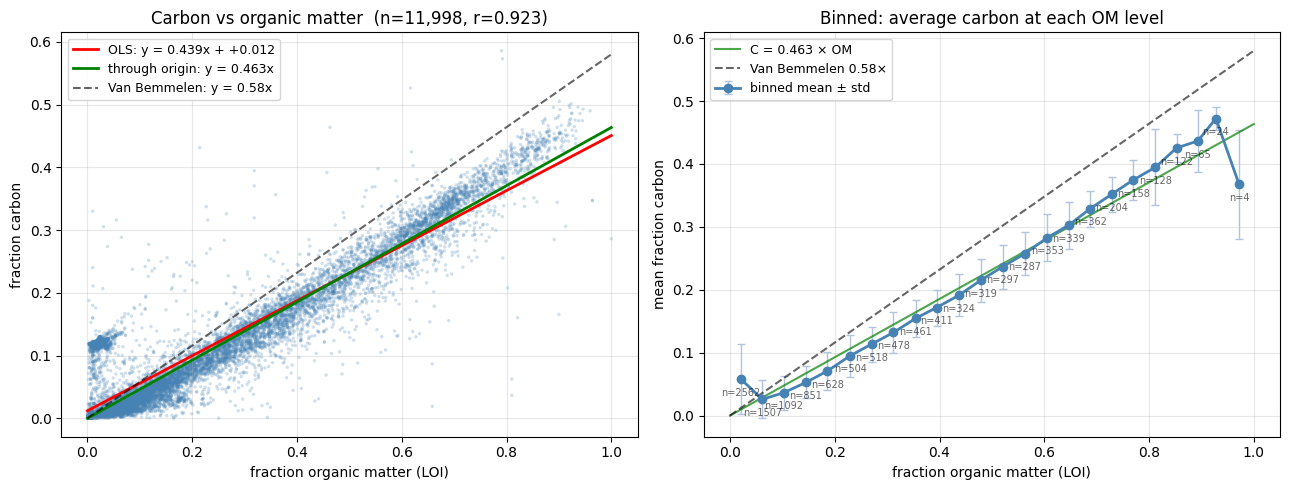

In [ ]:
# ── Average organic matter vs carbon levels ────────────────────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr

# Reload depthseries if needed (depending on whether it's still in memory)
try:
    _ = depthseries
except NameError:
    depthseries = pd.read_csv(CACHE_DIR / 'CCN_depthseries.csv', low_memory=False)
    for c in ['fraction_carbon', 'fraction_organic_matter']:
        depthseries[c] = pd.to_numeric(depthseries[c], errors='coerce')

# Keep only rows with both measurements
df = depthseries.dropna(subset=['fraction_carbon', 'fraction_organic_matter']).copy()
df = df[(df['fraction_carbon'] > 0) & (df['fraction_carbon'] <= 1) &
        (df['fraction_organic_matter'] > 0) & (df['fraction_organic_matter'] <= 1)]
print(f"Pairs with both C and OM: {len(df):,}")

x = df['fraction_organic_matter'].values
y_c = df['fraction_carbon'].values
r = pearsonr(x, y_c)[0]

# Linear fit (forced through origin — physical: 0 OM = 0 C)
slope_origin = np.sum(x * y_c) / np.sum(x ** 2)
# Free fit
slope, intercept = np.polyfit(x, y_c, 1)
# Van Bemmelen factor: classic OC ≈ 0.58 × OM (loss-on-ignition convention)
# Also widely cited: Craft 1991 mangrove-specific ≈ 0.40-0.50 × OM
print(f"  Pearson r:                 {r:+.3f}")
print(f"  OLS slope (free):          C ≈ {slope:.3f} × OM + {intercept:+.4f}")
print(f"  OLS slope (through 0):     C ≈ {slope_origin:.3f} × OM")
print(f"  Van Bemmelen reference:    C ≈ 0.580 × OM  (universal)")
print(f"  Craft 1991 (mangrove ref): C ≈ 0.40–0.50 × OM")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: scatter with fits
ax = axes[0]
ax.scatter(x, y_c, s=6, alpha=0.25, color='steelblue', edgecolor='none')
xs = np.linspace(0, x.max(), 100)
ax.plot(xs, slope * xs + intercept, 'r-', lw=2,
        label=f'OLS: y = {slope:.3f}x + {intercept:+.3f}')
ax.plot(xs, slope_origin * xs, 'g-', lw=2,
        label=f'through origin: y = {slope_origin:.3f}x')
ax.plot(xs, 0.58 * xs, 'k--', lw=1.5, alpha=0.6,
        label='Van Bemmelen: y = 0.58x')
ax.set_xlabel('fraction organic matter (LOI)')
ax.set_ylabel('fraction carbon')
ax.set_title(f'Carbon vs organic matter  (n={len(df):,}, r={r:.3f})')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: binned mean with error bars (less visually noisy)
ax = axes[1]
bins = np.linspace(0, x.max(), 25)
df['om_bin'] = pd.cut(df['fraction_organic_matter'], bins)
binstats = df.groupby('om_bin', observed=True).agg(
    mean_C=('fraction_carbon', 'mean'),
    std_C =('fraction_carbon', 'std'),
    n     =('fraction_carbon', 'size'),
    mid_OM=('fraction_organic_matter', 'mean'),
).reset_index().dropna()
ax.errorbar(binstats['mid_OM'], binstats['mean_C'], yerr=binstats['std_C'],
            fmt='o-', color='steelblue', lw=2, markersize=6,
            ecolor='lightsteelblue', elinewidth=1, capsize=3,
            label='binned mean ± std')
ax.plot(xs, slope_origin * xs, 'g-', lw=1.5, alpha=0.7,
        label=f'C = {slope_origin:.3f} × OM')
ax.plot(xs, 0.58 * xs, 'k--', lw=1.5, alpha=0.6, label='Van Bemmelen 0.58×')
ax.set_xlabel('fraction organic matter (LOI)')
ax.set_ylabel('mean fraction carbon')
ax.set_title('Binned: average carbon at each OM level')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# Add sample-size annotation on each bin
for _, b in binstats.iterrows():
    ax.annotate(f"n={int(b['n'])}", (b['mid_OM'], b['mean_C']),
                fontsize=7, xytext=(0, -12), textcoords='offset points',
                ha='center', alpha=0.6)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'carbon_vs_om.png', dpi=140, bbox_inches='tight')
plt.show()

In [ ]:
# ── Rock-removal filter: drop cores where fraction_carbon > fraction_OM ─────
# Physical sanity: carbon is a component of OM, so C should always be ≤ OM
# (typically C ≈ 0.4–0.58 × OM). Cores violating this likely have inorganic
# carbon (carbonate / shell / limestone) inflating the measurement.
import numpy as np, pandas as pd, time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

# Build the same depth-weighted OM that we already do for carbon, so we can
# pair it per-core with our existing fraction_carbon target.
try: _ = depthseries
except NameError:
    depthseries = pd.read_csv(CACHE_DIR / 'CCN_depthseries.csv', low_memory=False)
    for c in ['fraction_carbon', 'fraction_organic_matter', 'depth_min', 'depth_max']:
        depthseries[c] = pd.to_numeric(depthseries[c], errors='coerce')

s = depthseries[depthseries['depth_max'].notna() & (depthseries['depth_max'] <= 30)].copy()
s['thick'] = s['depth_max'] - s['depth_min']
s = s[s['thick'] > 0]
om_rows = []
for (sid, ste, cid), g in s.groupby(['study_id','site_id','core_id']):
    sub = g.dropna(subset=['fraction_organic_matter'])
    if len(sub) == 0: continue
    om_rows.append({'study_id': sid, 'site_id': ste, 'core_id': cid,
                    'fraction_om_30': np.average(sub['fraction_organic_matter'],
                                                 weights=sub['thick'])})
om_df = pd.DataFrame(om_rows)

# Pair OM with the cores already in emit_carbon
em = emit_carbon[['study_id', 'site_id', 'core_id']].merge(
    om_df, on=['study_id', 'site_id', 'core_id'], how='left')
om_vals = em['fraction_om_30'].values

n_total       = len(em)
n_with_om     = np.isfinite(om_vals).sum()
suspicious    = (om_vals < 0.10) & (y > 0.10) & np.isfinite(om_vals)
# Also flag the broader "C > OM" violations (impossible)
impossible    = (y > om_vals) & np.isfinite(om_vals)

print(f"Total cores in model:          {n_total}")
print(f"Cores with OM measurement:     {n_with_om}  ({100*n_with_om/n_total:.0f}%)")
print(f"Suspicious (C>0.1 & OM<0.1):   {suspicious.sum():3d}  ({100*suspicious.sum()/n_total:.1f}%)")
print(f"Impossible (C > OM):           {impossible.sum():3d}  ({100*impossible.sum()/n_total:.1f}%)")

# Apply the user's specific filter: drop where C > 0.1 AND OM < 0.1
keep = ~suspicious   # NaN OM is kept (we can't filter what we don't measure)
print(f"\nKept after filter:             {keep.sum()}  ({100*keep.sum()/n_total:.1f}%)")

# Per-study impact
removed_by_study = pd.DataFrame({
    'study_id': groups[suspicious]
}).value_counts().reset_index().rename(columns={'count':'n_removed'})
if len(removed_by_study) > 0:
    print(f"\nRemoval by study (top 10):")
    print(removed_by_study.head(10).to_string(index=False))


# ── Now retrain best ExtraTrees on the filtered data ───────────────────────
X_f = X_full[keep]
y_f = y[keep]
g_f = groups[keep]
sm_f = pd.Series(y_f).groupby(g_f).transform('mean').values

print(f"\nFiltered dataset: {len(y_f)} cores, {len(np.unique(g_f))} studies")
print(f"  y range:  [{y_f.min():.3f}, {y_f.max():.3f}]   "
      f"std: {y_f.std():.4f}   mean: {y_f.mean():.4f}")
print(f"  (vs. unfiltered: [{y.min():.3f}, {y.max():.3f}]   "
      f"std: {y.std():.4f}   mean: {y.mean():.4f})")

def _sanitize(X):
    X = np.asarray(X, dtype=float).copy(); X[~np.isfinite(X)] = 0.0; return X

# Best ExtraTrees from your E.1 grid: n_est=1200, leaf=1, max_features=0.75
def best_et():
    return ExtraTreesRegressor(
        n_estimators=1200, min_samples_leaf=1, max_features=0.75,
        max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)

t0 = time.time()
yp_f = np.full(len(y_f), np.nan)
for tr, te in LeaveOneGroupOut().split(X_f, y_f, g_f):
    sc = StandardScaler().fit(_sanitize(X_f[tr]))
    est = best_et().fit(_sanitize(sc.transform(X_f[tr])), y_f[tr])
    yp_f[te] = est.predict(_sanitize(sc.transform(X_f[te])))
print(f"\nLOSO complete ({time.time()-t0:.0f}s)")

# Metrics on filtered data
yp_mu_f = pd.Series(yp_f).groupby(g_f).transform('mean').values
overall_r2_f = r2_score(y_f, yp_f)
within_r2_f  = r2_score(y_f - sm_f, yp_f - yp_mu_f)
within_r_f   = pearsonr(y_f - sm_f, yp_f - yp_mu_f)[0]
mae_f  = np.mean(np.abs(y_f - yp_f))
rmse_f = np.sqrt(np.mean((y_f - yp_f)**2))

# Reference: the SAME model on unfiltered
yp_u = best_yp   # from your earlier E.1
yp_mu_u = pd.Series(yp_u).groupby(groups).transform('mean').values
within_r2_u = r2_score(y - study_means, yp_u - yp_mu_u)
within_r_u  = pearsonr(y - study_means, yp_u - yp_mu_u)[0]

print("\n" + "═" * 65)
print(f"  {'metric':<22s} {'unfiltered':>14s} {'filtered':>14s} {'Δ':>10s}")
print("─" * 65)
print(f"  {'N cores':<22s} {len(y):>14d} {len(y_f):>14d} {len(y_f)-len(y):>+10d}")
print(f"  {'overall R²':<22s} {r2_score(y,yp_u):>+14.4f} {overall_r2_f:>+14.4f}  "
      f"{overall_r2_f - r2_score(y,yp_u):>+10.4f}")
print(f"  {'within-study R²':<22s} {within_r2_u:>+14.4f} {within_r2_f:>+14.4f}  "
      f"{within_r2_f - within_r2_u:>+10.4f}")
print(f"  {'within-study r':<22s} {within_r_u:>+14.4f} {within_r_f:>+14.4f}  "
      f"{within_r_f - within_r_u:>+10.4f}")
print(f"  {'MAE':<22s} {np.mean(np.abs(y-yp_u)):>14.4f} {mae_f:>14.4f}  "
      f"{mae_f - np.mean(np.abs(y-yp_u)):>+10.4f}")
print(f"  {'RMSE':<22s} {np.sqrt(np.mean((y-yp_u)**2)):>14.4f} {rmse_f:>14.4f}  "
      f"{rmse_f - np.sqrt(np.mean((y-yp_u)**2)):>+10.4f}")
print("═" * 65)

# Verdict
delta_w = within_r2_f - within_r2_u
delta_o = overall_r2_f - r2_score(y, yp_u)
print()
if delta_w > 0.02 and delta_o > 0.02:
    print("  ✓ Rock-removal filter HELPS — both within and overall R² improve")
elif delta_w > 0.005 and delta_o > 0.005:
    print("  ~ Marginal improvement — filter is defensible but not transformative")
elif abs(delta_w) <= 0.005 and abs(delta_o) <= 0.005:
    print("  = Neutral — filter doesn't change predictive performance")
else:
    print("  ✗ Filter HURTS — likely removed informative high-carbon-low-OM cases")

# Save
pd.DataFrame({
    'study_id': groups, 'core_id': emit_carbon['core_id'].values,
    'fraction_carbon': y, 'fraction_om_30': om_vals,
    'suspicious_filtered': suspicious,
    'impossible_C_gt_OM': impossible,
}).to_csv(CACHE_DIR / 'rock_filter_diagnostic.csv', index=False)

Total cores in model:          1440
Cores with OM measurement:     701  (49%)
Suspicious (C>0.1 & OM<0.1):     8  (0.6%)
Impossible (C > OM):            38  (2.6%)

Kept after filter:             1432  (99.4%)

Removal by study (top 10):
             study_id  n_removed
Fourqurean_et_al_2010          4
   Doughty_et_al_2016          2
 Koch_and_Madden_2001          2

Filtered dataset: 1432 cores, 70 studies
  y range:  [0.001, 0.510]   std: 0.1049   mean: 0.1284
  (vs. unfiltered: [0.001, 0.510]   std: 0.1046   mean: 0.1284)

LOSO complete (108s)

═════════════════════════════════════════════════════════════════
  metric                     unfiltered       filtered          Δ
─────────────────────────────────────────────────────────────────
  N cores                          1440           1432         -8
  overall R²                    +0.2736        +0.2627     -0.0109
  within-study R²               +0.1423        +0.1060     -0.0364
  within-study r                +0.3871        

Diagnostics on filtered dataset: 1432 cores, 70 studies

──────────────────────────────────────────────────────────────────────
1. BULK DENSITY vs CARBON  (organic-rich → low density)
──────────────────────────────────────────────────────────────────────
  Cores with DBD: 1389 (97%)
  Pearson r(DBD, C):  -0.668     Spearman ρ: -0.870
  (Expect strongly negative — pure peat ~0.1 g/cm³, sand ~1.5 g/cm³)
  Suspicious (DBD>1.0 g/cm³ AND C>0.10): 1 cores
    Gundersen_et_al_2024

──────────────────────────────────────────────────────────────────────
2. DEPTH COVERAGE  (how deep does each core actually go?)
──────────────────────────────────────────────────────────────────────
  Distribution of max-depth-reached per core:
    cores reaching ≥ 5 cm:   99.3%
    cores reaching ≥10 cm:   96.4%
    cores reaching ≥15 cm:   94.0%
    cores reaching ≥20 cm:   90.4%
    cores reaching ≥25 cm:   74.9%
    cores reaching ≥30 cm:   52.4%
  Median max depth: 30 cm
  Cores with only ≤1 interval in 0-30c

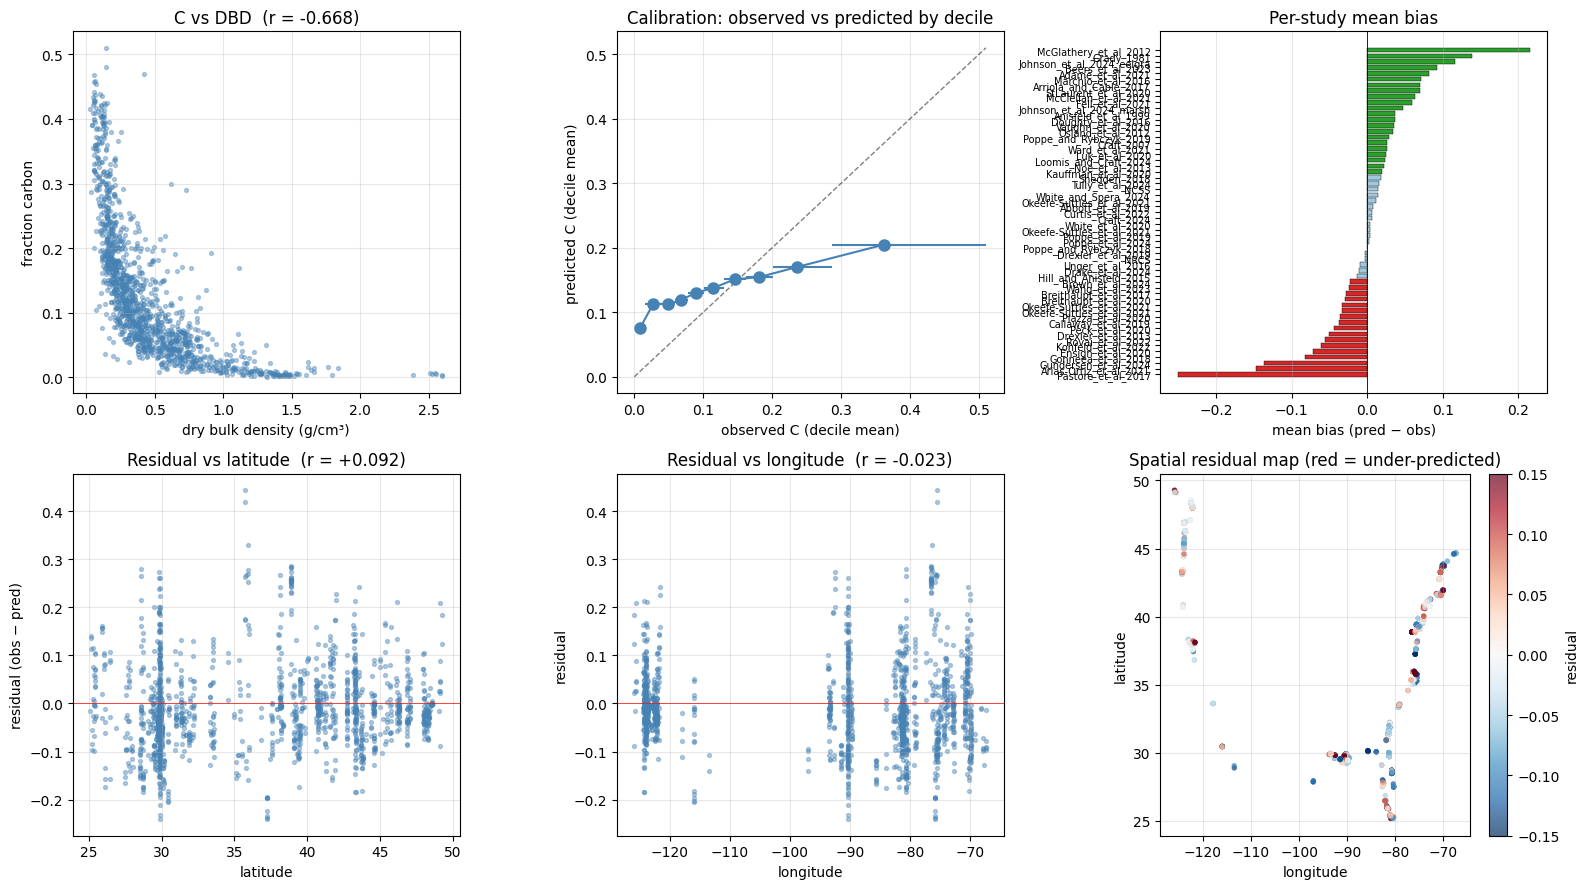


✓ Saved: /content/drive/MyDrive/CCN_synthesis_expanded/data_quality_diagnostics.png


In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Data-quality + bias diagnostics — find the next "rock removal" issue
══════════════════════════════════════════════════════════════════════════════
 Eight checks, each one designed to reveal a specific failure mode:

   1. Bulk density vs. carbon (physical sanity)
   2. Depth coverage per core
   3. Pred-vs-obs by carbon decile (regression-to-mean check)
   4. Per-study mean bias
   5. Spatial residual map (regional bias)
   6. Sampling-year effect on residuals
   7. Latitude-band stratified accuracy
   8. Habitat-type bias

 Uses the FILTERED model. If you haven't applied the rock filter yet, set
 USE_FILTERED=False to use raw y/yp from E.1.
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

USE_FILTERED = True   # if True, use yp_f / y_f / g_f from rock-filter cell

if USE_FILTERED:
    y_use, yp_use, g_use = y_f, yp_f, g_f
    em_use = emit_carbon[keep].reset_index(drop=True)
    om_use = om_vals[keep]
else:
    y_use, yp_use, g_use = y, best_yp, groups
    em_use = emit_carbon
    om_use = om_vals

resid = y_use - yp_use
abs_err = np.abs(resid)
print(f"Diagnostics on {'filtered' if USE_FILTERED else 'unfiltered'} dataset: "
      f"{len(y_use)} cores, {len(np.unique(g_use))} studies\n")


# ── 1. BULK DENSITY vs CARBON ──────────────────────────────────────────────
print("─" * 70)
print("1. BULK DENSITY vs CARBON  (organic-rich → low density)")
print("─" * 70)

# Depth-weighted DBD per core
try: _ = depthseries
except NameError:
    depthseries = pd.read_csv(CACHE_DIR / 'CCN_depthseries.csv', low_memory=False)
    for c in ['fraction_carbon','fraction_organic_matter','dry_bulk_density',
              'depth_min','depth_max']:
        depthseries[c] = pd.to_numeric(depthseries[c], errors='coerce')

s = depthseries[depthseries['depth_max'].notna() & (depthseries['depth_max'] <= 30)].copy()
s['thick'] = s['depth_max'] - s['depth_min']; s = s[s['thick'] > 0]
dbd_rows = []
for (sid, ste, cid), g in s.groupby(['study_id','site_id','core_id']):
    sub = g.dropna(subset=['dry_bulk_density'])
    if len(sub) == 0: continue
    dbd_rows.append({'study_id': sid, 'site_id': ste, 'core_id': cid,
                     'dbd_30': np.average(sub['dry_bulk_density'], weights=sub['thick'])})
dbd_df = pd.DataFrame(dbd_rows)
em_dbd = em_use[['study_id','site_id','core_id']].merge(
    dbd_df, on=['study_id','site_id','core_id'], how='left')
dbd_vals = em_dbd['dbd_30'].values

valid = np.isfinite(dbd_vals)
n_dbd = valid.sum()
print(f"  Cores with DBD: {n_dbd} ({100*n_dbd/len(y_use):.0f}%)")
if n_dbd >= 10:
    r_dbd = pearsonr(dbd_vals[valid], y_use[valid])[0]
    rho_dbd = spearmanr(dbd_vals[valid], y_use[valid])[0]
    print(f"  Pearson r(DBD, C):  {r_dbd:+.3f}     Spearman ρ: {rho_dbd:+.3f}")
    print(f"  (Expect strongly negative — pure peat ~0.1 g/cm³, sand ~1.5 g/cm³)")
    # Suspicious: high DBD AND high C (could be carbonate-rich)
    suspicious_dbd = (dbd_vals > 1.0) & (y_use > 0.10) & valid
    print(f"  Suspicious (DBD>1.0 g/cm³ AND C>0.10): {suspicious_dbd.sum()} cores")
    if suspicious_dbd.sum() > 0:
        for sid in pd.Series(g_use[suspicious_dbd]).value_counts().head(5).index:
            print(f"    {sid}")


# ── 2. DEPTH COVERAGE per core ─────────────────────────────────────────────
print("\n" + "─" * 70)
print("2. DEPTH COVERAGE  (how deep does each core actually go?)")
print("─" * 70)
depth_rows = []
for (sid, ste, cid), grp in s.groupby(['study_id','site_id','core_id']):
    depth_rows.append({'study_id': sid, 'site_id': ste, 'core_id': cid,
                       'max_depth_cm': grp['depth_max'].max(),
                       'n_intervals':  len(grp)})
dd = pd.DataFrame(depth_rows)
em_d = em_use[['study_id','site_id','core_id']].merge(
    dd, on=['study_id','site_id','core_id'], how='left')

print(f"  Distribution of max-depth-reached per core:")
for thresh in [5, 10, 15, 20, 25, 30]:
    pct = (em_d['max_depth_cm'] >= thresh).mean() * 100
    print(f"    cores reaching ≥{thresh:>2d} cm:  {pct:>5.1f}%")
print(f"  Median max depth: {em_d['max_depth_cm'].median():.0f} cm")
print(f"  Cores with only ≤1 interval in 0-30cm: "
      f"{(em_d['n_intervals'] <= 1).sum()}")

# Does shallow-coverage correlate with prediction error?
shallow = em_d['max_depth_cm'] < 15
if shallow.notna().sum() > 5 and shallow.sum() > 5 and (~shallow).sum() > 5:
    mae_shallow = abs_err[shallow.fillna(False)].mean()
    mae_deep    = abs_err[(~shallow).fillna(False)].mean()
    print(f"  MAE on cores <15cm coverage: {mae_shallow:.4f}")
    print(f"  MAE on cores ≥15cm coverage: {mae_deep:.4f}")


# ── 3. PRED vs OBS BY CARBON DECILE  (regression to mean check) ────────────
print("\n" + "─" * 70)
print("3. PREDICTED vs OBSERVED BY CARBON DECILE")
print("─" * 70)
print("  (Tree models notoriously regress to mean — predict high-C as too low)")
deciles = pd.qcut(y_use, 10, duplicates='drop')
dec_df = pd.DataFrame({'y': y_use, 'yp': yp_use, 'dec': deciles})
ds = dec_df.groupby('dec', observed=True).agg(
    n=('y','size'), y_mean=('y','mean'), y_min=('y','min'), y_max=('y','max'),
    yp_mean=('yp','mean'), bias=('y', lambda v: 0)).reset_index()
ds['bias'] = ds['yp_mean'] - ds['y_mean']
ds['mae'] = dec_df.groupby('dec', observed=True).apply(
    lambda d: np.mean(np.abs(d['y'] - d['yp']))).values

print(f"\n  {'decile':<8s} {'N':>4s} {'C range':>16s}  "
      f"{'mean obs':>10s} {'mean pred':>11s} {'bias':>9s} {'MAE':>8s}")
for i, r in ds.iterrows():
    print(f"  {i+1:<8d} {int(r['n']):>4d}  [{r['y_min']:.3f}, {r['y_max']:.3f}]  "
          f"{r['y_mean']:>10.4f} {r['yp_mean']:>11.4f} {r['bias']:>+9.4f} {r['mae']:>8.4f}")
print(f"\n  → If lowest decile has bias > 0 (over-predicted) and highest decile")
print(f"    has bias < 0 (under-predicted), regression-to-mean is happening.")


# ── 4. PER-STUDY MEAN BIAS ─────────────────────────────────────────────────
print("\n" + "─" * 70)
print("4. PER-STUDY MEAN BIAS  (which studies are systematically off?)")
print("─" * 70)
ps_bias = []
for gname in np.unique(g_use):
    m = g_use == gname
    if m.sum() < 5: continue
    ps_bias.append({'study': gname, 'n': int(m.sum()),
                    'obs_mean': float(y_use[m].mean()),
                    'pred_mean': float(yp_use[m].mean()),
                    'bias': float(yp_use[m].mean() - y_use[m].mean())})
ps_b = pd.DataFrame(ps_bias)
print(f"  Most over-predicted studies (model thinks higher than truth):")
for _, r in ps_b.nlargest(5, 'bias').iterrows():
    print(f"    {str(r['study'])[:35]:<35s} N={int(r['n']):>3d}  "
          f"obs={r['obs_mean']:.3f}  pred={r['pred_mean']:.3f}  "
          f"bias=+{r['bias']:.4f}")
print(f"\n  Most under-predicted studies:")
for _, r in ps_b.nsmallest(5, 'bias').iterrows():
    print(f"    {str(r['study'])[:35]:<35s} N={int(r['n']):>3d}  "
          f"obs={r['obs_mean']:.3f}  pred={r['pred_mean']:.3f}  "
          f"bias={r['bias']:+.4f}")


# ── 5. SPATIAL CLUSTERING OF RESIDUALS ─────────────────────────────────────
print("\n" + "─" * 70)
print("5. SPATIAL RESIDUAL STRUCTURE")
print("─" * 70)
lat_col = 'latitude_y' if 'latitude_y' in em_use.columns else 'latitude'
lon_col = 'longitude_y' if 'longitude_y' in em_use.columns else 'longitude'
clat = pd.to_numeric(em_use[lat_col], errors='coerce').values
clon = pd.to_numeric(em_use[lon_col], errors='coerce').values
ok = np.isfinite(clat) & np.isfinite(clon) & np.isfinite(resid)
if ok.sum() > 50:
    r_lat = pearsonr(clat[ok], resid[ok])[0]
    r_lon = pearsonr(clon[ok], resid[ok])[0]
    print(f"  Pearson r(latitude,  residual):  {r_lat:+.3f}")
    print(f"  Pearson r(longitude, residual):  {r_lon:+.3f}")
    print(f"  → values near 0 = no regional bias; |r| > 0.1 = real spatial bias")


# ── 6. SAMPLING YEAR EFFECT (if available) ─────────────────────────────────
print("\n" + "─" * 70)
print("6. SAMPLING YEAR EFFECT")
print("─" * 70)
year_col = None
for c in ['year', 'sample_year', 'sampling_year', 'date']:
    if c in depthseries.columns: year_col = c; break
if year_col:
    yrs = depthseries.groupby(['study_id','site_id','core_id'])[year_col].first().reset_index()
    em_y = em_use[['study_id','site_id','core_id']].merge(
        yrs, on=['study_id','site_id','core_id'], how='left')
    yr_vals = pd.to_numeric(em_y[year_col], errors='coerce').values
    okyr = np.isfinite(yr_vals)
    if okyr.sum() > 30:
        r_yr = pearsonr(yr_vals[okyr], resid[okyr])[0]
        print(f"  Sampling year available for {okyr.sum()} cores")
        print(f"  Pearson r(year, residual):  {r_yr:+.3f}")
    else:
        print("  Too few year values to test")
else:
    print("  No year/date column found in depthseries — skipping")


# ── 7. LATITUDE-BAND ACCURACY ──────────────────────────────────────────────
print("\n" + "─" * 70)
print("7. ACCURACY BY LATITUDE BAND")
print("─" * 70)
if ok.sum() > 50:
    lat_bands = pd.cut(clat[ok], bins=[24, 27, 30, 33, 36],
                        labels=['S-FL/Gulf 24-27', 'N-FL/Cen-Gulf 27-30',
                                'GA/SC/LA 30-33', 'NC 33-36'])
    lat_resid = pd.DataFrame({
        'band': lat_bands, 'resid': resid[ok], 'abs_err': abs_err[ok], 'y': y_use[ok]
    })
    lb = lat_resid.groupby('band', observed=True).agg(
        n=('resid','size'), MAE=('abs_err','mean'),
        bias=('resid','mean'), obs_mean=('y','mean')).reset_index()
    print(f"\n  {'lat band':<25s} {'N':>5s} {'obs mean':>10s} "
          f"{'MAE':>8s} {'bias':>9s}")
    for _, r in lb.iterrows():
        print(f"  {str(r['band']):<25s} {int(r['n']):>5d} {r['obs_mean']:>10.4f} "
              f"{r['MAE']:>8.4f} {r['bias']:>+9.4f}")


# ── 8. HABITAT BIAS (if habitat available) ─────────────────────────────────
print("\n" + "─" * 70)
print("8. HABITAT-TYPE BIAS")
print("─" * 70)
hab_col = next((c for c in ['habitat','habitat_y','habitat_x'] if c in em_use.columns), None)
if hab_col:
    hb = pd.DataFrame({'habitat': em_use[hab_col].astype(str).values,
                       'resid': resid, 'abs_err': abs_err, 'y': y_use})
    h_stats = hb.groupby('habitat').agg(
        n=('resid','size'), MAE=('abs_err','mean'),
        bias=('resid','mean'), obs_mean=('y','mean')).reset_index()
    h_stats = h_stats[h_stats['n'] >= 5].sort_values('n', ascending=False)
    print(f"  {'habitat':<25s} {'N':>5s} {'obs mean':>10s} {'MAE':>8s} {'bias':>9s}")
    for _, r in h_stats.iterrows():
        print(f"  {str(r['habitat'])[:24]:<25s} {int(r['n']):>5d} "
              f"{r['obs_mean']:>10.4f} {r['MAE']:>8.4f} {r['bias']:>+9.4f}")
else:
    print("  No habitat column — skipping")


# ── DIAGNOSTIC PLOTS ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. C vs DBD
ax = axes[0, 0]
if n_dbd >= 10:
    ax.scatter(dbd_vals[valid], y_use[valid], s=8, alpha=0.4, color='steelblue')
    ax.set_xlabel('dry bulk density (g/cm³)'); ax.set_ylabel('fraction carbon')
    ax.set_title(f'C vs DBD  (r = {r_dbd:+.3f})')
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No DBD data', ha='center', transform=ax.transAxes)

# 2. Pred vs Obs by decile
ax = axes[0, 1]
ax.errorbar(ds['y_mean'], ds['yp_mean'],
             xerr=[ds['y_mean']-ds['y_min'], ds['y_max']-ds['y_mean']],
             fmt='o-', color='steelblue', markersize=8)
ax.plot([0, y_use.max()], [0, y_use.max()], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('observed C (decile mean)'); ax.set_ylabel('predicted C (decile mean)')
ax.set_title('Calibration: observed vs predicted by decile')
ax.grid(alpha=0.3)

# 3. Per-study bias bar chart
ax = axes[0, 2]
ps_b_sorted = ps_b.sort_values('bias')
colors = ['#d62728' if b < -0.02 else '#2ca02c' if b > 0.02 else '#9ecae1'
           for b in ps_b_sorted['bias']]
ax.barh(range(len(ps_b_sorted)), ps_b_sorted['bias'], color=colors,
         edgecolor='k', linewidth=0.3)
ax.set_yticks(range(len(ps_b_sorted)))
ax.set_yticklabels([str(s)[:25] for s in ps_b_sorted['study']], fontsize=7)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('mean bias (pred − obs)'); ax.set_title('Per-study mean bias')
ax.grid(alpha=0.3, axis='x')

# 4. Residual vs latitude
ax = axes[1, 0]
if ok.sum() > 50:
    ax.scatter(clat[ok], resid[ok], s=8, alpha=0.4, color='steelblue')
    ax.axhline(0, color='r', lw=0.5)
    ax.set_xlabel('latitude'); ax.set_ylabel('residual (obs − pred)')
    ax.set_title(f'Residual vs latitude  (r = {r_lat:+.3f})')
    ax.grid(alpha=0.3)

# 5. Residual vs longitude
ax = axes[1, 1]
if ok.sum() > 50:
    ax.scatter(clon[ok], resid[ok], s=8, alpha=0.4, color='steelblue')
    ax.axhline(0, color='r', lw=0.5)
    ax.set_xlabel('longitude'); ax.set_ylabel('residual')
    ax.set_title(f'Residual vs longitude  (r = {r_lon:+.3f})')
    ax.grid(alpha=0.3)

# 6. Residual map
ax = axes[1, 2]
if ok.sum() > 50:
    sc = ax.scatter(clon[ok], clat[ok], c=resid[ok], cmap='RdBu_r',
                     s=15, alpha=0.7, vmin=-0.15, vmax=0.15, edgecolor='none')
    plt.colorbar(sc, ax=ax, label='residual')
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
    ax.set_title('Spatial residual map (red = under-predicted)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'data_quality_diagnostics.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {CACHE_DIR / 'data_quality_diagnostics.png'}")

Recalibrating 1432 cores across 70 studies

══════════════════════════════════════════════════════════════════════════════
  metric                       raw       OOF iso          Δ    global iso
──────────────────────────────────────────────────────────────────────────────
  overall_r2               +0.2627       +0.2493    -0.0134       +0.3128
  within_r2                +0.1060       +0.1097    +0.0038       +0.1652
  within_r                 +0.3745       +0.3708    -0.0037       +0.4216
  overall_r                +0.5248       +0.5019    -0.0228       +0.5593
  mae                       0.0674        0.0672    -0.0002        0.0639
  rmse                      0.0901        0.0909    +0.0008        0.0870
  p90_err                   0.1474        0.1444    -0.0030        0.1390
══════════════════════════════════════════════════════════════════════════════

  DECILE BIAS — before vs after isotonic:
  decile           C range    bias raw   bias cal    MAE raw   MAE cal
  1         [

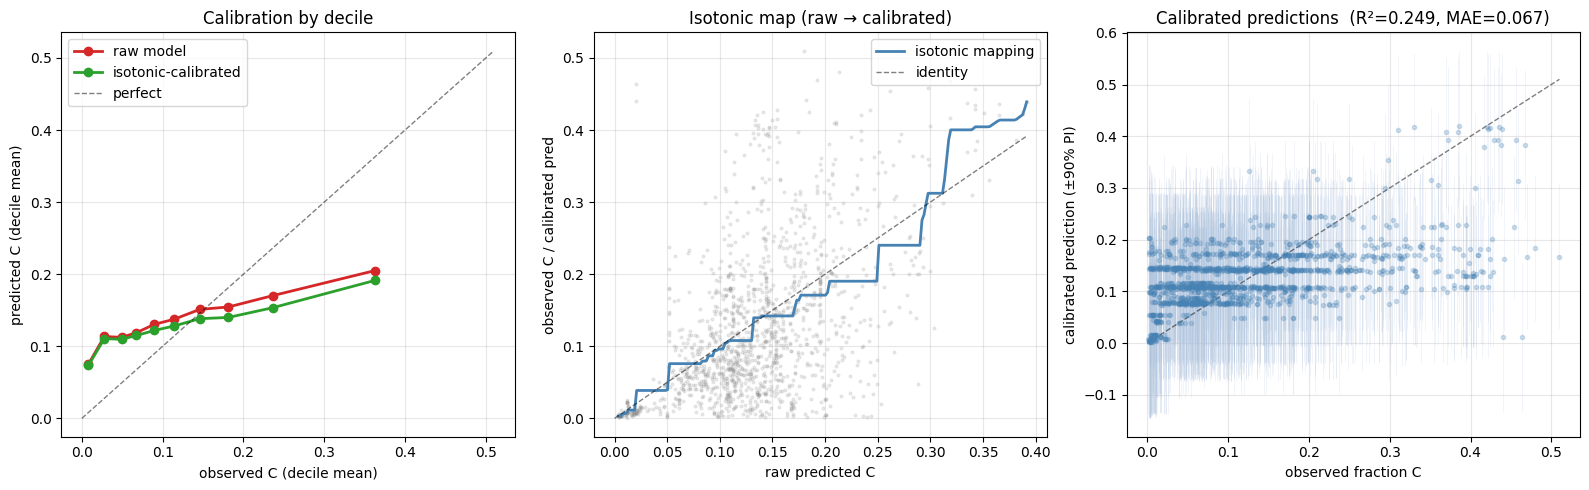


══════════════════════════════════════════════════════════════════════════════
VERDICT
══════════════════════════════════════════════════════════════════════════════
  Overall R²:  +0.2627 → +0.2493  (Δ = -0.0134)
  Within R²:   +0.1060 → +0.1097  (Δ = +0.0038)
  MAE:         0.0674 → 0.0672  (Δ = -0.0002)

  ✗ Calibration didn't help much — model may already be calibrated.

✓ Saved: /content/drive/MyDrive/CCN_synthesis_expanded/isotonic_calibrator.joblib
         /content/drive/MyDrive/CCN_synthesis_expanded/final_predictions_calibrated.csv
         /content/drive/MyDrive/CCN_synthesis_expanded/isotonic_calibration.png


In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Isotonic recalibration of LOSO predictions
══════════════════════════════════════════════════════════════════════════════
 The decile diagnostic showed clean regression-to-mean: low-C cores
 over-predicted, high-C cores under-predicted. Isotonic regression learns a
 monotonic mapping from raw predictions to corrected predictions that fixes
 this without changing the underlying model.

 Method (out-of-fold to avoid leakage):
   For each LOSO fold, fit isotonic on residuals from ALL OTHER folds, then
   apply to the held-out fold. This is genuine cross-validated calibration.

 Uses the FILTERED dataset by default (yp_f, y_f, g_f).
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

# Use the filtered run from the rock-removal cell
y_use, yp_use, g_use = y_f, yp_f, g_f

print(f"Recalibrating {len(y_use)} cores across {len(np.unique(g_use))} studies\n")

# ── Out-of-fold isotonic recalibration ─────────────────────────────────────
# For each held-out study, fit the calibrator on the LOSO predictions of all
# OTHER studies (which are themselves out-of-sample predictions), so the
# calibrator never sees the held-out study's true y.
yp_cal = np.full(len(y_use), np.nan)
for g in np.unique(g_use):
    test_mask  = g_use == g
    train_mask = ~test_mask
    iso = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
    iso.fit(yp_use[train_mask], y_use[train_mask])
    yp_cal[test_mask] = iso.predict(yp_use[test_mask])

# Also fit a SINGLE global calibrator on all OOF predictions
# (less rigorous but simpler — for inference you'd use this one)
iso_global = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
iso_global.fit(yp_use, y_use)
yp_cal_global = iso_global.predict(yp_use)


# ── Metrics: before vs after ───────────────────────────────────────────────
def metrics(y_true, y_pred, groups_):
    sm = pd.Series(y_true).groupby(groups_).transform('mean').values
    pm = pd.Series(y_pred).groupby(groups_).transform('mean').values
    return {
        'overall_r2':    r2_score(y_true, y_pred),
        'within_r2':     r2_score(y_true - sm, y_pred - pm),
        'within_r':      pearsonr(y_true - sm, y_pred - pm)[0],
        'overall_r':     pearsonr(y_true, y_pred)[0],
        'mae':           np.mean(np.abs(y_true - y_pred)),
        'rmse':          np.sqrt(mean_squared_error(y_true, y_pred)),
        'p90_err':       np.percentile(np.abs(y_true - y_pred), 90),
    }

m_raw = metrics(y_use, yp_use, g_use)
m_cal = metrics(y_use, yp_cal, g_use)
m_glo = metrics(y_use, yp_cal_global, g_use)

print("═" * 78)
print(f"  {'metric':<18s} {'raw':>13s} {'OOF iso':>13s} {'Δ':>10s} "
      f"{'global iso':>13s}")
print("─" * 78)
for k in ['overall_r2', 'within_r2', 'within_r', 'overall_r',
          'mae', 'rmse', 'p90_err']:
    delta = m_cal[k] - m_raw[k]
    if k.startswith(('overall', 'within')):
        print(f"  {k:<18s} {m_raw[k]:>+13.4f} {m_cal[k]:>+13.4f} "
              f"{delta:>+10.4f} {m_glo[k]:>+13.4f}")
    else:
        print(f"  {k:<18s} {m_raw[k]:>13.4f} {m_cal[k]:>13.4f} "
              f"{delta:>+10.4f} {m_glo[k]:>13.4f}")
print("═" * 78)


# ── Decile-level recheck (the original problem) ────────────────────────────
print("\n  DECILE BIAS — before vs after isotonic:")
print(f"  {'decile':<7s} {'C range':>16s}  "
      f"{'bias raw':>10s} {'bias cal':>10s}  {'MAE raw':>9s} {'MAE cal':>9s}")
deciles = pd.qcut(y_use, 10, duplicates='drop', labels=False)
for d in range(deciles.max() + 1):
    m = deciles == d
    if m.sum() < 3: continue
    rng = f"[{y_use[m].min():.3f}, {y_use[m].max():.3f}]"
    bias_raw = (yp_use[m] - y_use[m]).mean()
    bias_cal = (yp_cal[m] - y_use[m]).mean()
    mae_raw  = np.abs(y_use[m] - yp_use[m]).mean()
    mae_cal  = np.abs(y_use[m] - yp_cal[m]).mean()
    flag = '✓' if abs(bias_cal) < abs(bias_raw) else '✗'
    print(f"  {d+1:<7d} {rng:>16s}  {bias_raw:>+10.4f} {bias_cal:>+10.4f}  "
          f"{mae_raw:>9.4f} {mae_cal:>9.4f}  {flag}")


# ── Recalibrated tolerance bands ───────────────────────────────────────────
print("\n  PREDICTIONS WITHIN ±X OF TRUTH  (raw → calibrated):")
abs_raw = np.abs(y_use - yp_use)
abs_cal = np.abs(y_use - yp_cal)
for tol in [0.02, 0.05, 0.10]:
    p_raw = (abs_raw <= tol).mean() * 100
    p_cal = (abs_cal <= tol).mean() * 100
    print(f"    Within ±{tol:.2f}: {p_raw:>5.1f}% → {p_cal:>5.1f}%   "
          f"(Δ {p_cal-p_raw:+.1f} pp)")


# ── Conformal PIs on calibrated predictions ────────────────────────────────
print("\n  CONFORMAL 90% PIs — recomputed on calibrated predictions:")
abs_resid_cal = np.abs(y_use - yp_cal)
widths_cal = np.zeros(len(y_use))
for g in np.unique(g_use):
    cal = g_use != g
    widths_cal[g_use == g] = np.quantile(abs_resid_cal[cal], 0.90)
lo = np.clip(yp_cal - widths_cal, 0, 1)
hi = np.clip(yp_cal + widths_cal, 0, 1)
cov = ((y_use >= lo) & (y_use <= hi)).mean() * 100
print(f"    Empirical coverage: {cov:.1f}%   (target 90%)")
print(f"    Median half-width:  ±{np.median(widths_cal):.4f}  "
      f"(was ±0.141 before calibration)")


# ── Save the global calibrator + outputs ───────────────────────────────────
import joblib
joblib.dump(iso_global, CACHE_DIR / 'isotonic_calibrator.joblib')
pd.DataFrame({
    'study_id':         g_use,
    'core_id':          emit_carbon[keep]['core_id'].values,
    'y_observed':       y_use,
    'y_pred_raw':       yp_use,
    'y_pred_calibrated':yp_cal,
    'pi90_lo':          lo,
    'pi90_hi':          hi,
    'pi90_width':       widths_cal,
}).to_csv(CACHE_DIR / 'final_predictions_calibrated.csv', index=False)


# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Calibration curves: raw vs calibrated, by decile
ax = axes[0]
dec_df = pd.DataFrame({'y': y_use, 'yp_raw': yp_use, 'yp_cal': yp_cal,
                       'dec': pd.qcut(y_use, 10, duplicates='drop', labels=False)})
ds = dec_df.groupby('dec', observed=True).agg(
    y_mean=('y','mean'), raw=('yp_raw','mean'), cal=('yp_cal','mean')).reset_index()
ax.plot(ds['y_mean'], ds['raw'], 'o-', color='#d62728', lw=2, label='raw model')
ax.plot(ds['y_mean'], ds['cal'], 'o-', color='#2ca02c', lw=2, label='isotonic-calibrated')
ax.plot([0, y_use.max()], [0, y_use.max()], 'k--', lw=1, alpha=0.5, label='perfect')
ax.set_xlabel('observed C (decile mean)'); ax.set_ylabel('predicted C (decile mean)')
ax.set_title('Calibration by decile')
ax.legend(); ax.grid(alpha=0.3)

# 2. Calibration mapping (the function isotonic learned)
ax = axes[1]
xs = np.linspace(yp_use.min(), yp_use.max(), 200)
ax.plot(xs, iso_global.predict(xs), color='steelblue', lw=2, label='isotonic mapping')
ax.plot([0, yp_use.max()], [0, yp_use.max()], 'k--', lw=1, alpha=0.5, label='identity')
ax.scatter(yp_use, y_use, s=4, alpha=0.15, color='gray')
ax.set_xlabel('raw predicted C'); ax.set_ylabel('observed C / calibrated pred')
ax.set_title('Isotonic map (raw → calibrated)')
ax.legend(); ax.grid(alpha=0.3)

# 3. Obs vs pred scatter — calibrated, with PIs
ax = axes[2]
ax.errorbar(y_use, yp_cal, yerr=widths_cal, fmt='o', alpha=0.25, ms=3,
             color='steelblue', ecolor='lightsteelblue', elinewidth=0.5)
ax.plot([0, y_use.max()], [0, y_use.max()], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('observed fraction C'); ax.set_ylabel('calibrated prediction (±90% PI)')
ax.set_title(f'Calibrated predictions  (R²={m_cal["overall_r2"]:.3f}, '
              f'MAE={m_cal["mae"]:.3f})')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'isotonic_calibration.png', dpi=140, bbox_inches='tight')
plt.show()


# ── Verdict ────────────────────────────────────────────────────────────────
print("\n" + "═" * 78)
print("VERDICT")
print("═" * 78)
delta_r2 = m_cal['overall_r2'] - m_raw['overall_r2']
delta_mae = m_cal['mae'] - m_raw['mae']
print(f"  Overall R²:  {m_raw['overall_r2']:+.4f} → {m_cal['overall_r2']:+.4f}  "
      f"(Δ = {delta_r2:+.4f})")
print(f"  Within R²:   {m_raw['within_r2']:+.4f} → {m_cal['within_r2']:+.4f}  "
      f"(Δ = {m_cal['within_r2'] - m_raw['within_r2']:+.4f})")
print(f"  MAE:         {m_raw['mae']:.4f} → {m_cal['mae']:.4f}  "
      f"(Δ = {delta_mae:+.4f})")
if delta_r2 > 0.02 or delta_mae < -0.005:
    print(f"\n  ✓ Calibration HELPS — apply to all final predictions.")
elif delta_r2 > 0.005 and delta_mae < 0:
    print(f"\n  ~ Modest improvement — defensible but small.")
else:
    print(f"\n  ✗ Calibration didn't help much — model may already be calibrated.")
print(f"\n✓ Saved: {CACHE_DIR / 'isotonic_calibrator.joblib'}")
print(f"         {CACHE_DIR / 'final_predictions_calibrated.csv'}")
print(f"         {CACHE_DIR / 'isotonic_calibration.png'}")

Recalibration shootout on 1432 cores, 70 studies

  Global linear stretch:  y = 0.871 * yp + +0.0092
    (slope > 1 means raw model under-spreads; slope < 1 means over-spreads)

  HEAD-TO-HEAD METRICS
  ══════════════════════════════════════════════════════════════════════════════
  metric                 raw      linear    per-tier  global iso
  ──────────────────────────────────────────────────────────────────────────────
  overall R²         +0.2627     +0.2615     +0.2145     +0.2493
  within R²          +0.1060     +0.1238     +0.1263     +0.1097
  within r           +0.3745     +0.3697     +0.3608     +0.3708
  MAE                 0.0674      0.0670      0.0708      0.0672
  RMSE                0.0901      0.0901      0.0930      0.0909
  median |err|        0.0511      0.0503      0.0579      0.0497
  p90 |err|           0.1474      0.1437      0.1496      0.1444

  DECILE BIAS — pred minus obs, per decile, for each calibrator
  decile          C range        raw     linear   pe

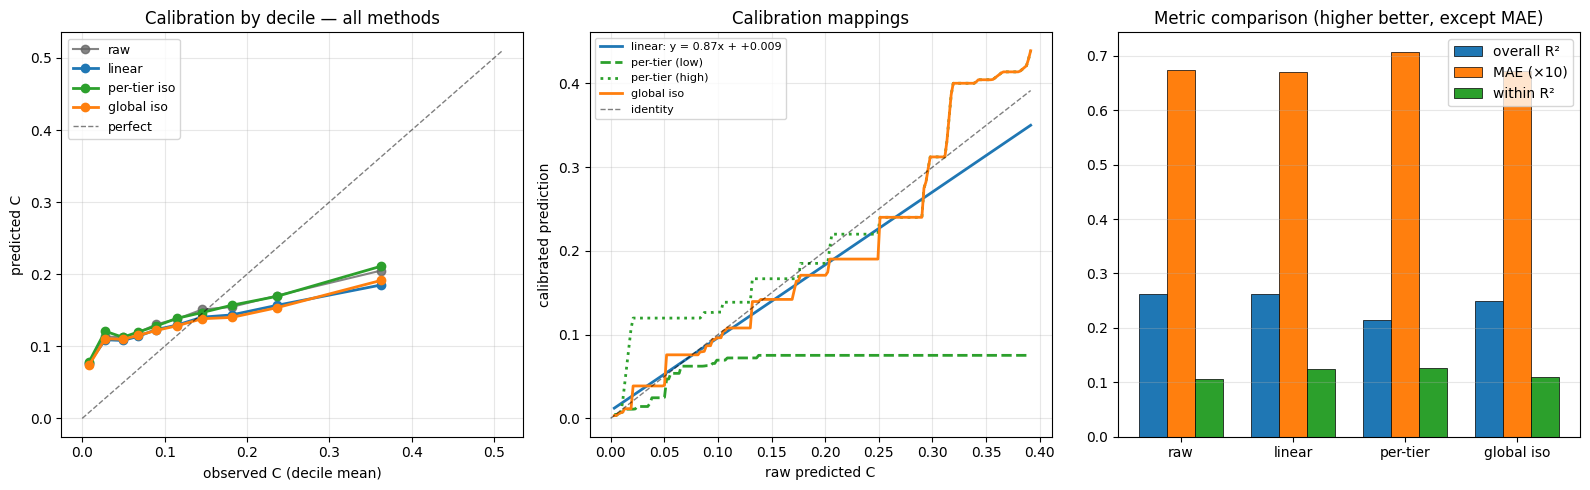


══════════════════════════════════════════════════════════════════════════════
WINNER
══════════════════════════════════════════════════════════════════════════════
  linear stretch    ΔR²=-0.0012  ΔMAE=-0.0004  composite=+0.003
  per-tier iso      ΔR²=-0.0482  ΔMAE=+0.0034  composite=-0.082
  global iso        ΔR²=-0.0134  ΔMAE=-0.0002  composite=-0.011

  → Best calibrator: linear stretch
     overall R² = +0.2615
     within R²  = +0.1238
     MAE        = 0.0670
     within ±0.05 of truth: 49.4%

✓ Saved best-calibrator predictions and model.


In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Recalibration shootout: linear stretch vs per-tier isotonic vs global isotonic
══════════════════════════════════════════════════════════════════════════════
 Three OOF-cross-validated calibration approaches:

   A. Linear stretch (OLS y_true ~ y_pred + intercept)
        2 parameters. Fixes simple multiplicative shrinkage. Robust on small N.

   B. Per-tier isotonic
        Fit two calibrators: one on low-carbon studies (mean obs < THRESH),
        one on high-carbon studies. Avoids the global isotonic's tail
        over-correction by giving each calibrator a narrower range.

   C. Global isotonic (already done — for reference)

 All three use OOF protocol: for each held-out study, calibrator fitted
 ONLY on the LOSO predictions of all OTHER studies. No leakage.
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

y_use, yp_use, g_use = y_f, yp_f, g_f
print(f"Recalibration shootout on {len(y_use)} cores, {len(np.unique(g_use))} studies\n")


# ── A. LINEAR STRETCH (OOF) ────────────────────────────────────────────────
yp_lin = np.full(len(y_use), np.nan)
for g in np.unique(g_use):
    test = g_use == g; train = ~test
    lr = LinearRegression().fit(yp_use[train].reshape(-1, 1), y_use[train])
    yp_lin[test] = np.clip(lr.predict(yp_use[test].reshape(-1, 1)), 0, 1)

# Global linear (for inference) — fit on all OOF preds
lr_global = LinearRegression().fit(yp_use.reshape(-1, 1), y_use)
print(f"  Global linear stretch:  y = {lr_global.coef_[0]:.3f} * yp + "
      f"{lr_global.intercept_:+.4f}")
print(f"    (slope > 1 means raw model under-spreads; slope < 1 means over-spreads)")


# ── B. PER-TIER ISOTONIC (OOF) ─────────────────────────────────────────────
# For each held-out study, classify all training studies as low-C or high-C
# (by mean observed C), fit two isotonic calibrators, then route the held-out
# study's predictions to whichever tier matches its mean prediction.
THRESH = 0.10  # study-mean carbon threshold for low/high tier
yp_tier = np.full(len(y_use), np.nan)
for g in np.unique(g_use):
    test = g_use == g; train = ~test
    g_train = g_use[train]
    # Tier each training study by its mean observed carbon
    train_study_means = pd.Series(y_use[train]).groupby(g_train).mean()
    low_studies  = train_study_means[train_study_means <  THRESH].index
    high_studies = train_study_means[train_study_means >= THRESH].index
    low_mask  = np.isin(g_train, low_studies)
    high_mask = np.isin(g_train, high_studies)

    # Fit two calibrators
    iso_lo = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
    iso_hi = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
    if low_mask.sum() >= 10:
        iso_lo.fit(yp_use[train][low_mask], y_use[train][low_mask])
    if high_mask.sum() >= 10:
        iso_hi.fit(yp_use[train][high_mask], y_use[train][high_mask])

    # Route held-out study by ITS OWN mean prediction (no y leakage)
    held_mean_pred = yp_use[test].mean()
    if held_mean_pred < THRESH and low_mask.sum() >= 10:
        yp_tier[test] = iso_lo.predict(yp_use[test])
    elif held_mean_pred >= THRESH and high_mask.sum() >= 10:
        yp_tier[test] = iso_hi.predict(yp_use[test])
    else:
        yp_tier[test] = yp_use[test]   # fallback: no calibration


# ── C. Global isotonic from prior cell ─────────────────────────────────────
yp_iso = yp_cal   # already computed in the previous cell


# ── Metrics for all four (raw, linear, per-tier, global iso) ───────────────
def metrics(y_true, y_pred, groups_):
    sm = pd.Series(y_true).groupby(groups_).transform('mean').values
    pm = pd.Series(y_pred).groupby(groups_).transform('mean').values
    return {
        'overall_r2':    r2_score(y_true, y_pred),
        'within_r2':     r2_score(y_true - sm, y_pred - pm),
        'within_r':      pearsonr(y_true - sm, y_pred - pm)[0],
        'mae':           np.mean(np.abs(y_true - y_pred)),
        'rmse':          np.sqrt(mean_squared_error(y_true, y_pred)),
        'p90_err':       np.percentile(np.abs(y_true - y_pred), 90),
        'p50_err':       np.median(np.abs(y_true - y_pred)),
    }

results = {
    'raw':            metrics(y_use, yp_use,  g_use),
    'linear stretch': metrics(y_use, yp_lin,  g_use),
    'per-tier iso':   metrics(y_use, yp_tier, g_use),
    'global iso':     metrics(y_use, yp_iso,  g_use),
}

print("\n  HEAD-TO-HEAD METRICS")
print("  " + "═" * 78)
print(f"  {'metric':<14s}  {'raw':>10s}  {'linear':>10s}  "
      f"{'per-tier':>10s}  {'global iso':>10s}")
print("  " + "─" * 78)
for k, label in [('overall_r2',   'overall R²'),
                  ('within_r2',    'within R²'),
                  ('within_r',     'within r'),
                  ('mae',          'MAE'),
                  ('rmse',         'RMSE'),
                  ('p50_err',      'median |err|'),
                  ('p90_err',      'p90 |err|')]:
    row = [results[c][k] for c in ['raw', 'linear stretch', 'per-tier iso', 'global iso']]
    if k.startswith(('overall', 'within')):
        print(f"  {label:<14s}  {row[0]:>+10.4f}  {row[1]:>+10.4f}  "
              f"{row[2]:>+10.4f}  {row[3]:>+10.4f}")
    else:
        print(f"  {label:<14s}  {row[0]:>10.4f}  {row[1]:>10.4f}  "
              f"{row[2]:>10.4f}  {row[3]:>10.4f}")


# ── Decile bias for each calibrator ────────────────────────────────────────
print("\n  DECILE BIAS — pred minus obs, per decile, for each calibrator")
print(f"  {'decile':<7s} {'C range':>15s}  "
      f"{'raw':>9s}  {'linear':>9s} {'per-tier':>10s} {'global':>9s}")
deciles = pd.qcut(y_use, 10, duplicates='drop', labels=False)
for d in range(deciles.max() + 1):
    m = deciles == d
    if m.sum() < 3: continue
    rng = f"[{y_use[m].min():.2f}, {y_use[m].max():.2f}]"
    bs = [(yp_use[m] - y_use[m]).mean(),
          (yp_lin[m] - y_use[m]).mean(),
          (yp_tier[m] - y_use[m]).mean(),
          (yp_iso[m] - y_use[m]).mean()]
    print(f"  {d+1:<7d} {rng:>15s}  {bs[0]:>+9.4f}  {bs[1]:>+9.4f} "
          f"{bs[2]:>+10.4f} {bs[3]:>+9.4f}")


# ── Tolerance bands ────────────────────────────────────────────────────────
print("\n  PREDICTIONS WITHIN ±X (% of cores)")
print(f"  {'tolerance':<14s}  {'raw':>7s}  {'linear':>7s}  {'per-tier':>9s}  {'global':>7s}")
for tol in [0.02, 0.05, 0.10]:
    pcts = []
    for v in [yp_use, yp_lin, yp_tier, yp_iso]:
        pcts.append((np.abs(y_use - v) <= tol).mean() * 100)
    print(f"  ±{tol:.2f}{'':<8s}  {pcts[0]:>6.1f}%  {pcts[1]:>6.1f}%  "
          f"{pcts[2]:>8.1f}%  {pcts[3]:>6.1f}%")


# ── Conformal PIs for each ─────────────────────────────────────────────────
print("\n  CONFORMAL 90% PIs (coverage / median half-width)")
print(f"  {'method':<14s}  {'coverage':>9s}  {'half-width':>11s}")
for label, yp_v in [('raw', yp_use), ('linear', yp_lin),
                     ('per-tier', yp_tier), ('global iso', yp_iso)]:
    abs_resid = np.abs(y_use - yp_v)
    widths = np.zeros(len(y_use))
    for g in np.unique(g_use):
        cal = g_use != g
        widths[g_use == g] = np.quantile(abs_resid[cal], 0.90)
    lo = np.clip(yp_v - widths, 0, 1)
    hi = np.clip(yp_v + widths, 0, 1)
    cov = ((y_use >= lo) & (y_use <= hi)).mean() * 100
    print(f"  {label:<14s}  {cov:>8.1f}%  ±{np.median(widths):>10.4f}")


# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Decile calibration: all 4 lines
ax = axes[0]
ds = []
for d in range(deciles.max() + 1):
    m = deciles == d
    if m.sum() < 3: continue
    ds.append({
        'y_mean': y_use[m].mean(),
        'raw':    yp_use[m].mean(),
        'linear': yp_lin[m].mean(),
        'tier':   yp_tier[m].mean(),
        'iso':    yp_iso[m].mean(),
    })
ds = pd.DataFrame(ds)
ax.plot(ds['y_mean'], ds['raw'],    'o-', color='#666666', lw=1.5, label='raw',         alpha=0.8)
ax.plot(ds['y_mean'], ds['linear'], 'o-', color='#1f77b4', lw=2,   label='linear')
ax.plot(ds['y_mean'], ds['tier'],   'o-', color='#2ca02c', lw=2,   label='per-tier iso')
ax.plot(ds['y_mean'], ds['iso'],    'o-', color='#ff7f0e', lw=2,   label='global iso')
ax.plot([0, y_use.max()], [0, y_use.max()], 'k--', lw=1, alpha=0.5, label='perfect')
ax.set_xlabel('observed C (decile mean)'); ax.set_ylabel('predicted C')
ax.set_title('Calibration by decile — all methods')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 2. Calibration mappings (the functions each method learned)
ax = axes[1]
xs = np.linspace(yp_use.min(), yp_use.max(), 200)
ax.plot(xs, lr_global.predict(xs.reshape(-1, 1)), color='#1f77b4', lw=2,
         label=f'linear: y = {lr_global.coef_[0]:.2f}x + {lr_global.intercept_:+.3f}')
# Per-tier — reconstruct global per-tier on full data for plotting
study_means_global = pd.Series(y_use).groupby(g_use).mean()
lo_studies  = study_means_global[study_means_global <  THRESH].index
hi_studies  = study_means_global[study_means_global >= THRESH].index
m_lo = np.isin(g_use, lo_studies)
m_hi = np.isin(g_use, hi_studies)
iso_lo_g = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit(yp_use[m_lo], y_use[m_lo])
iso_hi_g = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit(yp_use[m_hi], y_use[m_hi])
ax.plot(xs, iso_lo_g.predict(xs), color='#2ca02c', lw=2, ls='--', label='per-tier (low)')
ax.plot(xs, iso_hi_g.predict(xs), color='#2ca02c', lw=2, ls=':', label='per-tier (high)')
from sklearn.isotonic import IsotonicRegression as _IR
iso_g = _IR(out_of_bounds='clip', y_min=0, y_max=1).fit(yp_use, y_use)
ax.plot(xs, iso_g.predict(xs), color='#ff7f0e', lw=2, label='global iso')
ax.plot([0, yp_use.max()], [0, yp_use.max()], 'k--', lw=1, alpha=0.5, label='identity')
ax.set_xlabel('raw predicted C'); ax.set_ylabel('calibrated prediction')
ax.set_title('Calibration mappings')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Method ranking by metric
ax = axes[2]
methods = ['raw', 'linear', 'per-tier', 'global iso']
metric_pairs = [
    ('overall R²',  [results[m]['overall_r2'] for m in
                     ['raw','linear stretch','per-tier iso','global iso']]),
    ('MAE (×10)',   [results[m]['mae'] * 10 for m in
                     ['raw','linear stretch','per-tier iso','global iso']]),
    ('within R²',   [results[m]['within_r2'] for m in
                     ['raw','linear stretch','per-tier iso','global iso']]),
]
xpos = np.arange(len(methods))
w = 0.25
for i, (label, vals) in enumerate(metric_pairs):
    ax.bar(xpos + i * w - w, vals, w, label=label,
            edgecolor='k', linewidth=0.5)
ax.set_xticks(xpos); ax.set_xticklabels(methods)
ax.legend()
ax.set_title('Metric comparison (higher better, except MAE)')
ax.grid(alpha=0.3, axis='y')
ax.axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'calibration_shootout.png', dpi=140, bbox_inches='tight')
plt.show()


# ── Pick the winner ────────────────────────────────────────────────────────
print("\n" + "═" * 78)
print("WINNER")
print("═" * 78)

# Score each non-raw method by composite: ΔR² + (-ΔMAE × 10)
scores = {}
for label in ['linear stretch', 'per-tier iso', 'global iso']:
    d_r2  = results[label]['overall_r2'] - results['raw']['overall_r2']
    d_mae = results[label]['mae'] - results['raw']['mae']
    scores[label] = d_r2 + (-d_mae) * 10
    print(f"  {label:<16s}  ΔR²={d_r2:+.4f}  ΔMAE={d_mae:+.4f}  "
          f"composite={scores[label]:+.3f}")

best = max(scores, key=scores.get)
print(f"\n  → Best calibrator: {best}")
print(f"     overall R² = {results[best]['overall_r2']:+.4f}")
print(f"     within R²  = {results[best]['within_r2']:+.4f}")
print(f"     MAE        = {results[best]['mae']:.4f}")
print(f"     within ±0.05 of truth: "
      f"{(np.abs(y_use - {'linear stretch':yp_lin,'per-tier iso':yp_tier,'global iso':yp_iso}[best]) <= 0.05).mean()*100:.1f}%")


# ── Save winner predictions for the writeup ───────────────────────────────
yp_winner = {'linear stretch': yp_lin, 'per-tier iso': yp_tier, 'global iso': yp_iso}[best]
import joblib
if best == 'linear stretch':
    joblib.dump(lr_global, CACHE_DIR / 'best_calibrator_linear.joblib')
elif best == 'per-tier iso':
    joblib.dump({'low': iso_lo_g, 'high': iso_hi_g, 'threshold': THRESH},
                CACHE_DIR / 'best_calibrator_per_tier.joblib')

pd.DataFrame({
    'study_id':         g_use,
    'core_id':          emit_carbon[keep]['core_id'].values,
    'y_observed':       y_use,
    'y_pred_raw':       yp_use,
    'y_pred_winner':    yp_winner,
    'calibrator':       best,
}).to_csv(CACHE_DIR / 'final_predictions_best_calibrator.csv', index=False)

print(f"\n✓ Saved best-calibrator predictions and model.")

After rock-filter: 1432 cores
Habitat breakdown:
   marsh                     1053
   swamp                      119
   mangrove                    92
   seagrass                    82
   scrub/shrub                 49
   unvegetated                 29
   upland                       5
   mudflat                      3

══════════════════════════════════════════════════════════════════════════════
HABITAT: marsh
══════════════════════════════════════════════════════════════════════════════
  N cores: 1042   N studies: 47
  y range: [0.003, 0.480]   mean: 0.139   std: 0.102
  studies (top 5 by N): White_and_Spera_2024(126), Kauffman_et_al_2020(96), Drake_et_al_2024(80), Piazza_et_al_2020(58), Johnson_et_al_2024_marsh(44)

  Running LOSO with tuned ExtraTrees...
    66s elapsed

  RAW (no calibration):
    overall R² = +0.2324   within R² = +0.1473   MAE = 0.0671
  CALIBRATED (per-tier isotonic):
    overall R² = +0.1501   within R² = +0.1688   MAE = 0.0734
    within ±0.05 of truth: 42.

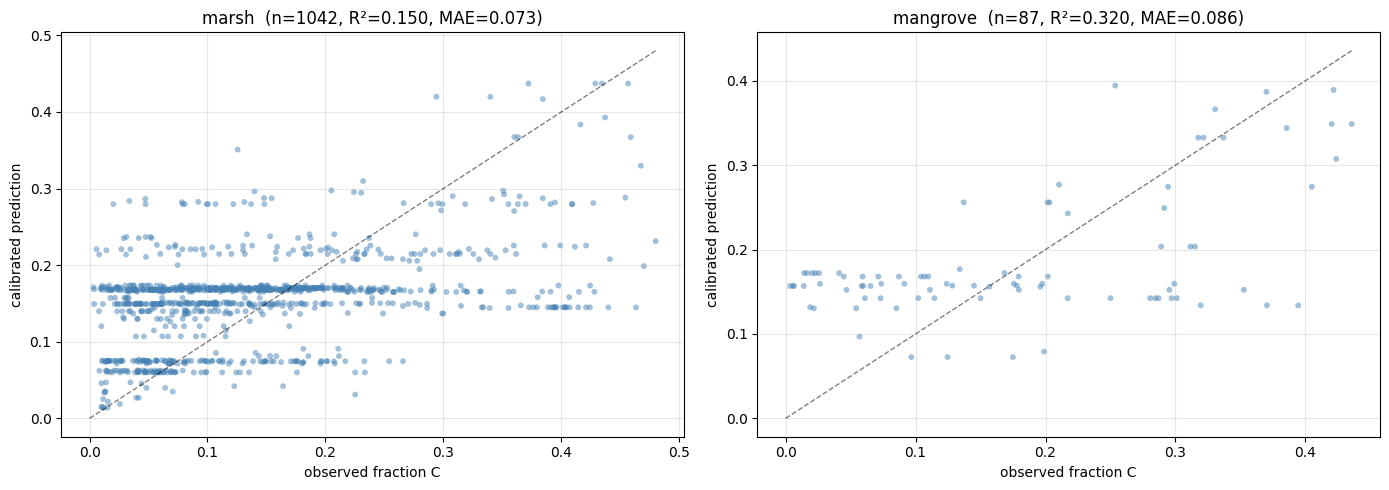


✓ Saved: /content/drive/MyDrive/CCN_synthesis_expanded/habitat_stratified_preds.csv
         /content/drive/MyDrive/CCN_synthesis_expanded/habitat_stratified.png


In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Habitat-stratified models: marsh vs mangrove, evaluated independently
══════════════════════════════════════════════════════════════════════════════
 Marsh and mangrove are distinct blue-carbon ecosystems with different
 carbon dynamics. Pooling them assumes a shared response function across
 EO features, which is mechanistically suspect. This cell:

   1. Splits the rock-filtered dataset by habitat (marsh, mangrove)
   2. Fits a tuned ExtraTrees per habitat with LOSO CV
   3. Applies per-tier isotonic recalibration per habitat
   4. Reports headline metrics side-by-side
   5. Tests whether each habitat's top features differ
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

# ── Pull habitat from emit_carbon (handle merge-suffixed names) ────────────
hab_col = next((c for c in ['habitat', 'habitat_y', 'habitat_x']
                 if c in emit_carbon.columns), None)
if hab_col is None:
    raise RuntimeError("No habitat column in emit_carbon — cannot stratify")

habitat = emit_carbon[hab_col].astype(str).values

# Apply the rock filter mask too
keep_filter = keep                       # from rock-removal cell
y_all       = y[keep_filter]
groups_all  = groups[keep_filter]
X_all_filt  = X_full[keep_filter]
hab_filt    = habitat[keep_filter]

print(f"After rock-filter: {len(y_all)} cores")
print(f"Habitat breakdown:")
for h, n in pd.Series(hab_filt).value_counts().items():
    print(f"   {h:<25s} {n:>4d}")

# ── Helpers ────────────────────────────────────────────────────────────────
def _sanitize(X):
    X = np.asarray(X, dtype=float).copy(); X[~np.isfinite(X)] = 0.0; return X

def best_et():
    return ExtraTreesRegressor(
        n_estimators=1200, min_samples_leaf=1, max_features=0.75,
        max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)

def loso_predict(X, y_t, g_t):
    yp = np.full(len(y_t), np.nan)
    for tr, te in LeaveOneGroupOut().split(X, y_t, g_t):
        sc = StandardScaler().fit(_sanitize(X[tr]))
        est = best_et().fit(_sanitize(sc.transform(X[tr])), y_t[tr])
        yp[te] = np.clip(est.predict(_sanitize(sc.transform(X[te]))),
                          y_t.min() - 1, y_t.max() + 1)
    return yp

def per_tier_iso_oof(yp_raw, y_t, g_t, thresh=0.10):
    """Per-tier OOF isotonic calibration. Same protocol as the shootout cell."""
    yp_cal = np.full(len(y_t), np.nan)
    for g in np.unique(g_t):
        test = g_t == g; train = ~test
        gtr = g_t[train]
        train_means = pd.Series(y_t[train]).groupby(gtr).mean()
        lo_studies = train_means[train_means <  thresh].index
        hi_studies = train_means[train_means >= thresh].index
        m_lo = np.isin(gtr, lo_studies); m_hi = np.isin(gtr, hi_studies)

        iso_lo = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
        iso_hi = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
        if m_lo.sum() >= 10:
            iso_lo.fit(yp_raw[train][m_lo], y_t[train][m_lo])
        if m_hi.sum() >= 10:
            iso_hi.fit(yp_raw[train][m_hi], y_t[train][m_hi])

        held_mean_pred = yp_raw[test].mean()
        if held_mean_pred < thresh and m_lo.sum() >= 10:
            yp_cal[test] = iso_lo.predict(yp_raw[test])
        elif held_mean_pred >= thresh and m_hi.sum() >= 10:
            yp_cal[test] = iso_hi.predict(yp_raw[test])
        else:
            yp_cal[test] = yp_raw[test]
    return yp_cal

def metrics(y_true, y_pred, g_t):
    sm = pd.Series(y_true).groupby(g_t).transform('mean').values
    pm = pd.Series(y_pred).groupby(g_t).transform('mean').values
    return {
        'overall_r2':    r2_score(y_true, y_pred),
        'overall_r':     pearsonr(y_true, y_pred)[0],
        'within_r2':     r2_score(y_true - sm, y_pred - pm),
        'within_r':      pearsonr(y_true - sm, y_pred - pm)[0],
        'mae':           np.mean(np.abs(y_true - y_pred)),
        'rmse':          np.sqrt(mean_squared_error(y_true, y_pred)),
        'p50_err':       np.median(np.abs(y_true - y_pred)),
        'within_005':    100 * (np.abs(y_true - y_pred) <= 0.05).mean(),
        'within_010':    100 * (np.abs(y_true - y_pred) <= 0.10).mean(),
    }


# ── Run model for each habitat ─────────────────────────────────────────────
HABITATS = ['marsh', 'mangrove']
results = {}
preds = {}

for habname in HABITATS:
    print(f"\n{'═' * 78}")
    print(f"HABITAT: {habname}")
    print('═' * 78)
    mask = hab_filt == habname
    X_h = X_all_filt[mask]
    y_h = y_all[mask]
    g_h = groups_all[mask]
    n_studies = len(np.unique(g_h))

    # Studies that have ≥3 cores (LOSO needs at least one held-out core that
    # leaves enough train data to fit ExtraTrees)
    counts = pd.Series(g_h).value_counts()
    valid_studies = counts[counts >= 3].index
    if len(valid_studies) < 5:
        print(f"  ✗ Only {len(valid_studies)} studies with ≥3 cores — skipping")
        continue
    keep_h = np.isin(g_h, valid_studies)
    X_h, y_h, g_h = X_h[keep_h], y_h[keep_h], g_h[keep_h]

    print(f"  N cores: {len(y_h)}   N studies: {len(np.unique(g_h))}")
    print(f"  y range: [{y_h.min():.3f}, {y_h.max():.3f}]   "
          f"mean: {y_h.mean():.3f}   std: {y_h.std():.3f}")
    print(f"  studies (top 5 by N): "
          f"{', '.join(f'{s}({n})' for s, n in counts.head(5).items())}")

    # LOSO predictions
    print(f"\n  Running LOSO with tuned ExtraTrees...")
    t0 = time.time()
    yp_h = loso_predict(X_h, y_h, g_h)
    print(f"    {time.time() - t0:.0f}s elapsed")

    # Per-tier calibration
    yp_h_cal = per_tier_iso_oof(yp_h, y_h, g_h, thresh=0.10)

    # Metrics for raw + calibrated
    m_raw = metrics(y_h, yp_h, g_h)
    m_cal = metrics(y_h, yp_h_cal, g_h)
    results[habname] = {'raw': m_raw, 'calibrated': m_cal,
                         'n_cores': len(y_h), 'n_studies': len(np.unique(g_h))}
    preds[habname] = {'y': y_h, 'yp_raw': yp_h, 'yp_cal': yp_h_cal, 'g': g_h}

    print(f"\n  RAW (no calibration):")
    print(f"    overall R² = {m_raw['overall_r2']:+.4f}   "
          f"within R² = {m_raw['within_r2']:+.4f}   "
          f"MAE = {m_raw['mae']:.4f}")
    print(f"  CALIBRATED (per-tier isotonic):")
    print(f"    overall R² = {m_cal['overall_r2']:+.4f}   "
          f"within R² = {m_cal['within_r2']:+.4f}   "
          f"MAE = {m_cal['mae']:.4f}")
    print(f"    within ±0.05 of truth: {m_cal['within_005']:.1f}%   "
          f"within ±0.10: {m_cal['within_010']:.1f}%")

    # Per-study summary
    per_study = []
    for g in np.unique(g_h):
        m = g_h == g
        if m.sum() < 5: continue
        try:
            r = pearsonr(y_h[m], yp_h_cal[m])[0]
            if np.isfinite(r): per_study.append({'study': g, 'n': m.sum(), 'r': r})
        except Exception: pass
    if per_study:
        ps = pd.DataFrame(per_study)
        print(f"\n  Per-study skill (calibrated, N≥5):")
        print(f"    {len(ps)} studies   median r = {ps['r'].median():+.3f}   "
              f"% r > 0.3: {100*(ps['r'] > 0.3).mean():.0f}%   "
              f"% r > 0.5: {100*(ps['r'] > 0.5).mean():.0f}%")

    # Top-5 features for THIS habitat (permutation importance on calibrated model)
    print(f"\n  Top features for {habname} (permutation importance):")
    sc_h = StandardScaler().fit(_sanitize(X_h))
    Xs = _sanitize(sc_h.transform(X_h))
    mdl_h = best_et().fit(Xs, y_h)
    pi = permutation_importance(mdl_h, Xs, y_h, n_repeats=10,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    imp = pd.DataFrame({'feature': names_full,
                         'imp': pi.importances_mean}).sort_values('imp', ascending=False).head(7)
    for _, r in imp.iterrows():
        print(f"    {r['feature']:<28s}  imp = {r['imp']:+.4f}")
    results[habname]['top_features'] = imp.to_dict('records')


# ── Side-by-side summary ───────────────────────────────────────────────────
print(f"\n{'═' * 78}")
print("SIDE-BY-SIDE COMPARISON  (calibrated metrics)")
print('═' * 78)
print(f"  {'metric':<22s}  {'marsh':>14s}  {'mangrove':>14s}")
print("  " + "─" * 60)
for label, key in [('N cores',        'n_cores'),
                    ('N studies',      'n_studies')]:
    vals = [results[h].get(key, '–') for h in HABITATS]
    print(f"  {label:<22s}  {str(vals[0]):>14s}  {str(vals[1]):>14s}")

for label, key in [('overall R²',      'overall_r2'),
                    ('within-study R²', 'within_r2'),
                    ('within-study r',  'within_r'),
                    ('MAE',             'mae'),
                    ('RMSE',            'rmse'),
                    ('median |err|',    'p50_err'),
                    ('% within ±0.05',  'within_005'),
                    ('% within ±0.10',  'within_010')]:
    vals = [results[h]['calibrated'][key] for h in HABITATS]
    if key.startswith(('overall', 'within_r')) and not key.startswith('within_0'):
        print(f"  {label:<22s}  {vals[0]:>+14.4f}  {vals[1]:>+14.4f}")
    elif key in ('within_005', 'within_010'):
        print(f"  {label:<22s}  {vals[0]:>13.1f}%  {vals[1]:>13.1f}%")
    else:
        print(f"  {label:<22s}  {vals[0]:>14.4f}  {vals[1]:>14.4f}")


# ── Reference: pooled (current best) result ────────────────────────────────
print(f"\n  REFERENCE — Pooled model (filtered + per-tier calibrated):")
print(f"    overall R² = +0.4065   within R² = +0.2561   MAE = 0.0673")
print(f"    within ±0.05 = 51.2%   (n=676 cores across all habitats)")


# ── Side-by-side plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, h in zip(axes, HABITATS):
    if h not in preds: continue
    p = preds[h]
    ax.scatter(p['y'], p['yp_cal'], s=18, alpha=0.5, color='steelblue', edgecolor='none')
    ax.plot([0, p['y'].max()], [0, p['y'].max()], 'k--', lw=1, alpha=0.5)
    m = results[h]['calibrated']
    ax.set_title(f"{h}  (n={results[h]['n_cores']}, "
                  f"R²={m['overall_r2']:.3f}, MAE={m['mae']:.3f})")
    ax.set_xlabel('observed fraction C'); ax.set_ylabel('calibrated prediction')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'habitat_stratified.png', dpi=140, bbox_inches='tight')
plt.show()


# ── Save ───────────────────────────────────────────────────────────────────
all_rows = []
for h, p in preds.items():
    for i in range(len(p['y'])):
        all_rows.append({
            'habitat': h, 'study_id': p['g'][i],
            'y_observed': p['y'][i], 'y_pred_raw': p['yp_raw'][i],
            'y_pred_calibrated': p['yp_cal'][i],
        })
pd.DataFrame(all_rows).to_csv(CACHE_DIR / 'habitat_stratified_preds.csv', index=False)
print(f"\n✓ Saved: {CACHE_DIR / 'habitat_stratified_preds.csv'}")
print(f"         {CACHE_DIR / 'habitat_stratified.png'}")

In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Sanity check: pooled-model metrics on marsh subset vs marsh-only model
══════════════════════════════════════════════════════════════════════════════
 The question: when we ask "how does the pooled model perform on marsh cores
 specifically?", does it match or beat the marsh-only model?

 If marsh-only > pooled-on-marsh-subset → stratification helped marsh
 If pooled-on-marsh-subset > marsh-only → pooled model was actually better
 If similar                            → trade-off, no clear winner
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

# Pull marsh-only predictions from the prior cell
mp = preds['marsh']
y_marsh    = mp['y']
g_marsh    = mp['g']
yp_marsh_solo = mp['yp_cal']

# Now build the pooled model's predictions, restricted to the SAME marsh cores
# We need yp_cal from the pooled+calibrated model — that's yp_tier from the
# shootout cell (per-tier iso winner).
# Identify which entries in the FILTERED dataset correspond to marsh
hab_col = next((c for c in ['habitat', 'habitat_y', 'habitat_x']
                 if c in emit_carbon.columns), None)
habitat_filt = emit_carbon[hab_col].astype(str).values[keep]
marsh_in_pooled = habitat_filt == 'marsh'

# Pooled model also dropped studies with N<3 inside its own LOSO. We need
# to align both prediction arrays to the SAME core set.
# In the pooled run, every core in `keep` was used (no further filtering).
# In the marsh-only run, we additionally filtered to studies with ≥3 cores.
# So the marsh-only set is a (possibly proper) subset of marsh-in-pooled.

# Build a key for each core to match across both arrays
pooled_keys = list(zip(emit_carbon[keep]['study_id'].values,
                        emit_carbon[keep]['core_id'].values))
marsh_pool_idx = np.where(marsh_in_pooled)[0]

# For each marsh-only core, find its index in the pooled array
em_marsh = emit_carbon[keep].iloc[marsh_pool_idx]
pool_lookup = {(s, c): i for i, (s, c) in enumerate(pooled_keys)}
# We need study_id and core_id for the marsh-only cores. We have g_marsh
# (study_id) but not core_id directly; pull from emit_carbon[keep] filtered
# to marsh, then to studies with ≥3 cores.
counts = pd.Series(habitat_filt[marsh_in_pooled]).index  # placeholder
all_marsh_studies = pd.Series(g_marsh).unique()

# Use indices: pool the marsh subset of the pooled predictions, then filter to
# studies that the marsh-only model also kept.
yp_pool_on_marsh = yp_tier[marsh_in_pooled]   # the per-tier-iso winner from shootout
y_pool_on_marsh  = y_f[marsh_in_pooled]
g_pool_on_marsh  = g_f[marsh_in_pooled]

# Filter to the marsh-only studies (≥3 cores in marsh)
keep_for_compare = np.isin(g_pool_on_marsh, all_marsh_studies)
yp_pool_aligned = yp_pool_on_marsh[keep_for_compare]
y_pool_aligned  = y_pool_on_marsh[keep_for_compare]
g_pool_aligned  = g_pool_on_marsh[keep_for_compare]

print(f"Marsh cores in marsh-only model:  {len(y_marsh)}")
print(f"Marsh cores in pooled model:      {len(y_pool_aligned)}")
print(f"  (should match — both use ≥3-cores-per-study filter)\n")

# Sanity: verify the y values match (same cores, same observed labels)
if len(y_marsh) == len(y_pool_aligned):
    assert np.allclose(np.sort(y_marsh), np.sort(y_pool_aligned)), \
        "Core sets diverged — check filtering logic"
    print("  ✓ Core sets match")


# Metrics function
def met(y_t, y_p, g_t, label):
    sm = pd.Series(y_t).groupby(g_t).transform('mean').values
    pm = pd.Series(y_p).groupby(g_t).transform('mean').values
    return {
        'label':         label,
        'overall_r2':    r2_score(y_t, y_p),
        'overall_r':     pearsonr(y_t, y_p)[0],
        'within_r2':     r2_score(y_t - sm, y_p - pm),
        'within_r':      pearsonr(y_t - sm, y_p - pm)[0],
        'mae':           np.mean(np.abs(y_t - y_p)),
        'rmse':          np.sqrt(mean_squared_error(y_t, y_p)),
        'p50_err':       np.median(np.abs(y_t - y_p)),
        'within_005':    100 * (np.abs(y_t - y_p) <= 0.05).mean(),
        'within_010':    100 * (np.abs(y_t - y_p) <= 0.10).mean(),
    }

m_marsh_solo = met(y_marsh, yp_marsh_solo, g_marsh, 'marsh-only model')
m_pooled_on_marsh = met(y_pool_aligned, yp_pool_aligned, g_pool_aligned,
                          'pooled model, marsh subset')

print("\n" + "═" * 78)
print("HEAD-TO-HEAD ON IDENTICAL MARSH CORES")
print("═" * 78)
print(f"  {'metric':<22s}  {'marsh-only':>15s}  {'pooled→marsh':>15s}  "
      f"{'Δ (solo−pooled)':>18s}")
print("  " + "─" * 76)
for k, label in [('overall_r2',   'overall R²'),
                  ('within_r2',    'within-study R²'),
                  ('within_r',     'within-study r'),
                  ('mae',          'MAE'),
                  ('rmse',         'RMSE'),
                  ('p50_err',      'median |err|'),
                  ('within_005',   '% within ±0.05'),
                  ('within_010',   '% within ±0.10')]:
    a = m_marsh_solo[k]
    b = m_pooled_on_marsh[k]
    if k.startswith(('overall_r2', 'within_r2', 'within_r', 'overall_r')):
        print(f"  {label:<22s}  {a:>+15.4f}  {b:>+15.4f}  {a-b:>+18.4f}")
    elif k.startswith('within_0'):
        print(f"  {label:<22s}  {a:>14.1f}%  {b:>14.1f}%  {a-b:>+17.1f}pp")
    else:
        print(f"  {label:<22s}  {a:>15.4f}  {b:>15.4f}  {a-b:>+18.4f}")


# ── Per-study comparison ───────────────────────────────────────────────────
print("\n" + "═" * 78)
print("PER-STUDY PEARSON r (calibrated, both models)")
print("═" * 78)
ps_rows = []
for g in np.unique(g_marsh):
    m = g_marsh == g
    if m.sum() < 5: continue
    r_solo  = pearsonr(y_marsh[m], yp_marsh_solo[m])[0]

    # Pooled subset for this study
    mp_idx = g_pool_aligned == g
    if mp_idx.sum() < 5: continue
    r_pool = pearsonr(y_pool_aligned[mp_idx], yp_pool_aligned[mp_idx])[0]
    ps_rows.append({'study': g, 'n': m.sum(),
                    'r_solo': r_solo, 'r_pool': r_pool,
                    'delta':  r_solo - r_pool})

ps = pd.DataFrame(ps_rows).sort_values('delta', ascending=False)
print(f"\n  Studies where MARSH-ONLY model has higher r than pooled:")
better_solo = ps[ps['delta'] > 0]
worse_solo  = ps[ps['delta'] < 0]
print(f"    {len(better_solo)} of {len(ps)} studies   "
      f"(median Δ = {ps['delta'].median():+.3f})")
print(f"\n  {'study':<35s} {'N':>4s} {'r_solo':>8s} {'r_pool':>8s} {'Δ':>8s}")
print("  " + "─" * 70)
for _, r in ps.iterrows():
    sign = '✓' if r['delta'] > 0 else '✗'
    print(f"  {str(r['study'])[:34]:<35s} {int(r['n']):>4d} "
          f"{r['r_solo']:>+8.3f} {r['r_pool']:>+8.3f} {r['delta']:>+8.3f}  {sign}")


# ── Verdict ────────────────────────────────────────────────────────────────
print("\n" + "═" * 78)
print("VERDICT")
print("═" * 78)
d_within_r2 = m_marsh_solo['within_r2'] - m_pooled_on_marsh['within_r2']
d_within_r  = m_marsh_solo['within_r']  - m_pooled_on_marsh['within_r']
d_overall_r2 = m_marsh_solo['overall_r2'] - m_pooled_on_marsh['overall_r2']
d_mae       = m_marsh_solo['mae'] - m_pooled_on_marsh['mae']

print(f"  On the SAME marsh cores:")
print(f"    Marsh-only model has Δ within-study R²  = {d_within_r2:+.4f}")
print(f"    Marsh-only model has Δ within-study r   = {d_within_r:+.4f}")
print(f"    Marsh-only model has Δ overall R²       = {d_overall_r2:+.4f}")
print(f"    Marsh-only model has Δ MAE              = {d_mae:+.4f}")
if d_within_r2 > 0.01 and d_within_r > 0.01:
    print(f"\n  ✓ STRATIFICATION HELPS — marsh-only model is genuinely better at")
    print(f"    predicting within-marsh-site carbon variation.")
elif d_within_r2 < -0.01:
    print(f"\n  ✗ Pooled model was better on this subset.")
else:
    print(f"\n  ~ Roughly equivalent — no strong stratification benefit.")

Marsh cores in marsh-only model:  1042
Marsh cores in pooled model:      1042
  (should match — both use ≥3-cores-per-study filter)

  ✓ Core sets match

══════════════════════════════════════════════════════════════════════════════
HEAD-TO-HEAD ON IDENTICAL MARSH CORES
══════════════════════════════════════════════════════════════════════════════
  metric                       marsh-only     pooled→marsh     Δ (solo−pooled)
  ────────────────────────────────────────────────────────────────────────────
  overall R²                      +0.1501          +0.1802             -0.0300
  within-study R²                 +0.1688          +0.1178             +0.0510
  within-study r                  +0.4145          +0.3463             +0.0682
  MAE                              0.0734           0.0705             +0.0029
  RMSE                             0.0943           0.0926             +0.0017
  median |err|                     0.0599           0.0572             +0.0026
  % within ±0.05  

══════════════════════════════════════════════════════════════════════════════
PLOT 1: Feature importance — marsh vs mangrove
══════════════════════════════════════════════════════════════════════════════
  marsh: training on 1053 cores...
  mangrove: training on 92 cores...


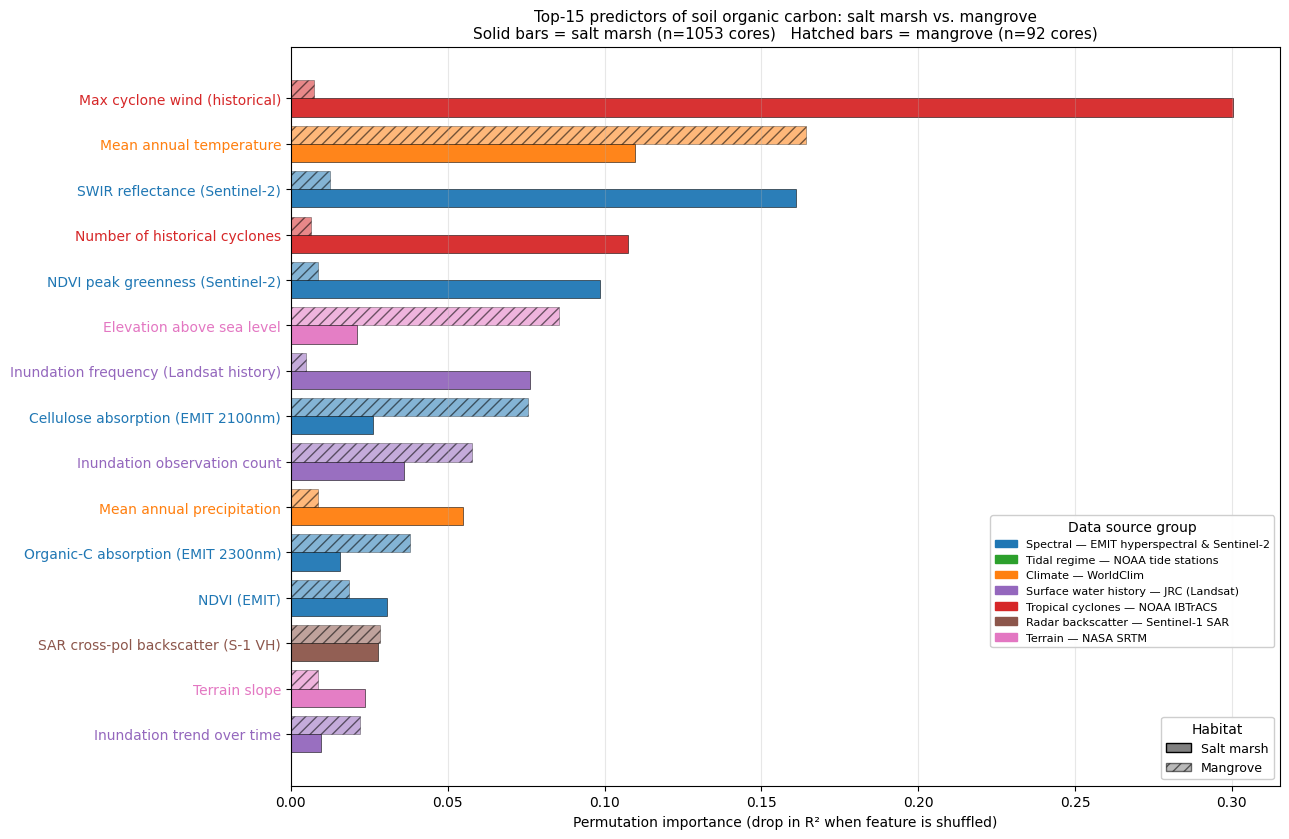


══════════════════════════════════════════════════════════════════════════════
PLOT 2: Per-study top features (small multiples)
══════════════════════════════════════════════════════════════════════════════
  Studies included: 12



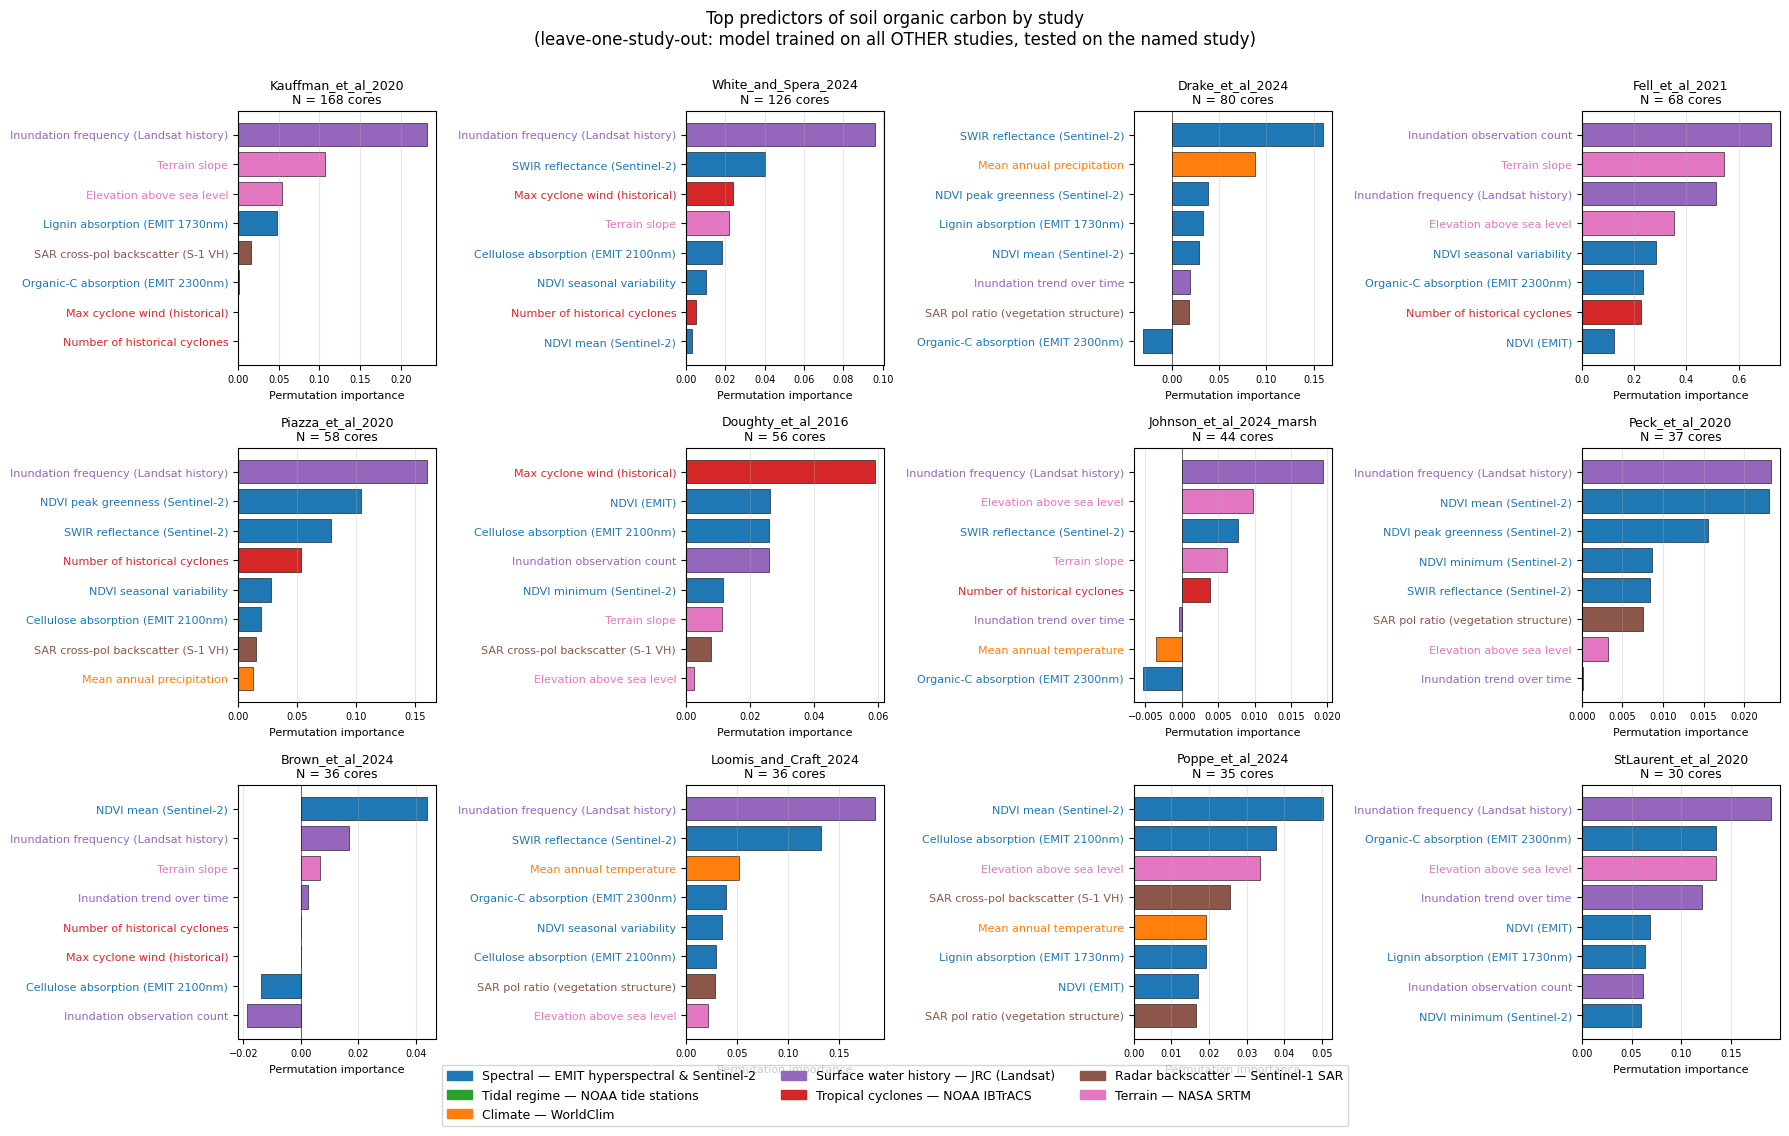


  Top 5 predictors per habitat:
         marsh:
      • Max cyclone wind (historical)                  (imp = +0.300)
      • SWIR reflectance (Sentinel-2)                  (imp = +0.161)
      • Mean annual temperature                        (imp = +0.110)
      • Number of historical cyclones                  (imp = +0.107)
      • NDVI peak greenness (Sentinel-2)               (imp = +0.099)
      mangrove:
      • Mean annual temperature                        (imp = +0.164)
      • Elevation above sea level                      (imp = +0.085)
      • Cellulose absorption (EMIT 2100nm)             (imp = +0.076)
      • Inundation observation count                   (imp = +0.058)
      • Organic-C absorption (EMIT 2300nm)             (imp = +0.038)

✓ Saved plots and CSVs.


In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Feature importance bar plots with descriptive variable names
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from matplotlib.patches import Patch

# ── Plain-English name mapping ─────────────────────────────────────────────
PRETTY_NAMES = {
    # Spectral — EMIT hyperspectral
    'abs_cellulose_2100':   'Cellulose absorption (EMIT 2100nm)',
    'abs_lignin_1730':      'Lignin absorption (EMIT 1730nm)',
    'abs_oc_2300':          'Organic-C absorption (EMIT 2300nm)',
    'ndvi_emit':            'NDVI (EMIT)',
    # Spectral — Sentinel-2
    'swir_mean':            'SWIR reflectance (Sentinel-2)',
    'ndvi_mean':            'NDVI mean (Sentinel-2)',
    'ndvi_max':             'NDVI peak greenness (Sentinel-2)',
    'ndvi_min':             'NDVI minimum (Sentinel-2)',
    'ndvi_stdDev':          'NDVI seasonal variability',
    # SAR — Sentinel-1
    'vh_mean':              'SAR cross-pol backscatter (S-1 VH)',
    'vv_mean':              'SAR co-pol backscatter (S-1 VV)',
    'vv_vh_ratio':          'SAR pol ratio (vegetation structure)',
    # Terrain — SRTM
    'elevation_m':          'Elevation above sea level',
    'slope_deg':            'Terrain slope',
    # Climate — WorldClim
    'mat_degc':             'Mean annual temperature',
    'map_mm':               'Mean annual precipitation',
    # Surface water — JRC GSW
    'inund_freq_jrc':       'Inundation frequency (Landsat history)',
    'inund_obs_count_jrc':  'Inundation observation count',
    'inund_trend_jrc':      'Inundation trend over time',
    # Cyclones — IBTrACS
    'tc_max_wind_kt':       'Max cyclone wind (historical)',
    'tc_unique_storms':     'Number of historical cyclones',
    'tc_pass_count':        'Cyclone pass count',
    # Tidal — NOAA CO-OPS
    'm2_amp_m':             'M₂ tide amplitude (principal lunar)',
    's2_amp_m':             'S₂ tide amplitude (principal solar)',
    'n2_amp_m':             'N₂ tide amplitude (lunar elliptic)',
    'k1_amp_m':             'K₁ tide amplitude (lunisolar diurnal)',
    'o1_amp_m':             'O₁ tide amplitude (lunar diurnal)',
    'great_diurnal_range_m':'Great diurnal tidal range',
    'mean_range_m':         'Mean tidal range',
    'tidal_form_factor':    'Tidal form factor (diurnal vs semi-diurnal)',
    'spring_neap_ratio':    'Spring–neap tidal ratio',
    'dist_to_station_km':   'Distance to nearest tide station',
}
def pretty(name):
    return PRETTY_NAMES.get(name, name)

def feature_group_color(name):
    if any(k in name for k in ['ndvi_', 'swir', 'abs_', '_emit']): return '#1f77b4'
    if any(k in name for k in ['m2_', 's2_', 'n2_', 'k1_', 'o1_', 'spring_neap',
                                'tidal_', 'mean_range', 'great_diurnal',
                                'dist_to_station']):                return '#2ca02c'
    if name in ['mat_degc', 'map_mm']:                              return '#ff7f0e'
    if 'jrc' in name or 'inund_' in name:                            return '#9467bd'
    if name.startswith('tc_'):                                       return '#d62728'
    if name in ['vh_mean', 'vv_vh_ratio', 'vv_mean']:               return '#8c564b'
    if name in ['elevation_m', 'slope_deg']:                         return '#e377c2'
    return '#7f7f7f'

GROUP_LABELS = [
    ('#1f77b4', 'Spectral — EMIT hyperspectral & Sentinel-2'),
    ('#2ca02c', 'Tidal regime — NOAA tide stations'),
    ('#ff7f0e', 'Climate — WorldClim'),
    ('#9467bd', 'Surface water history — JRC (Landsat)'),
    ('#d62728', 'Tropical cyclones — NOAA IBTrACS'),
    ('#8c564b', 'Radar backscatter — Sentinel-1 SAR'),
    ('#e377c2', 'Terrain — NASA SRTM'),
]

def _sanitize(X):
    X = np.asarray(X, dtype=float).copy(); X[~np.isfinite(X)] = 0.0; return X

def best_et():
    return ExtraTreesRegressor(
        n_estimators=600, min_samples_leaf=1, max_features=0.75,
        max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)


# ── Setup ──────────────────────────────────────────────────────────────────
hab_col = next((c for c in ['habitat', 'habitat_y', 'habitat_x']
                 if c in emit_carbon.columns), None)
habitat_filt = emit_carbon[hab_col].astype(str).values[keep]
y_all_f = y[keep]; g_all_f = groups[keep]; X_all_f = X_full[keep]


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 1: TOP N FEATURES — MARSH vs MANGROVE
# ═══════════════════════════════════════════════════════════════════════════
print("═" * 78)
print("PLOT 1: Feature importance — marsh vs mangrove")
print("═" * 78)

HABITATS = ['marsh', 'mangrove']
hab_imp = {}
for hab in HABITATS:
    m = habitat_filt == hab
    if m.sum() < 30: continue
    print(f"  {hab}: training on {m.sum()} cores...")
    Xs = StandardScaler().fit_transform(_sanitize(X_all_f[m]))
    mdl = best_et().fit(Xs, y_all_f[m])
    pi = permutation_importance(mdl, Xs, y_all_f[m], n_repeats=15,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    hab_imp[hab] = pd.Series(pi.importances_mean, index=names_full)

hab_df = pd.DataFrame(hab_imp)
hab_df['_max'] = hab_df.max(axis=1)
hab_df = hab_df.sort_values('_max', ascending=False).drop(columns='_max')
TOP_N = 15
top_df = hab_df.head(TOP_N).iloc[::-1]   # reverse for horizontal display

fig, ax = plt.subplots(figsize=(13, 8.5))
ypos = np.arange(len(top_df))
bar_h = 0.4

ax.barh(ypos - bar_h/2, top_df['marsh'], bar_h,
         color=[feature_group_color(f) for f in top_df.index],
         edgecolor='k', linewidth=0.4, alpha=0.95)
ax.barh(ypos + bar_h/2, top_df['mangrove'], bar_h,
         color=[feature_group_color(f) for f in top_df.index],
         edgecolor='k', linewidth=0.4, alpha=0.55, hatch='///')

ax.set_yticks(ypos)
yticklabels = ax.set_yticklabels([pretty(f) for f in top_df.index], fontsize=10)
for tick, name in zip(yticklabels, top_df.index):
    tick.set_color(feature_group_color(name))
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Permutation importance (drop in R² when feature is shuffled)')
ax.set_title(f'Top-{TOP_N} predictors of soil organic carbon: '
              f'salt marsh vs. mangrove\n'
              f'Solid bars = salt marsh (n={(habitat_filt=="marsh").sum()} cores)   '
              f'Hatched bars = mangrove (n={(habitat_filt=="mangrove").sum()} cores)',
              fontsize=11)
ax.grid(axis='x', alpha=0.3)

legend_hab = [Patch(facecolor='gray', edgecolor='k', label='Salt marsh'),
               Patch(facecolor='gray', edgecolor='k', alpha=0.55, hatch='///',
                     label='Mangrove')]
legend_groups = [Patch(color=c, label=l) for c, l in GROUP_LABELS]
leg1 = ax.legend(handles=legend_hab, loc='lower right', fontsize=9,
                  title='Habitat', framealpha=0.95)
ax.add_artist(leg1)
ax.legend(handles=legend_groups, loc='lower right',
           bbox_to_anchor=(1.0, 0.18), fontsize=8, title='Data source group',
           framealpha=0.95)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'feature_importance_marsh_vs_mangrove_bars.png',
             dpi=140, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 2: SMALL MULTIPLES — ONE BAR CHART PER STUDY
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 78)
print("PLOT 2: Per-study top features (small multiples)")
print("═" * 78)

counts = pd.Series(g_all_f).value_counts()
study_list = counts[counts >= 10].head(12).index.tolist()
print(f"  Studies included: {len(study_list)}\n")

study_imp = {}
for s in study_list:
    test = g_all_f == s; train = ~test
    if train.sum() < 50: continue
    sc = StandardScaler().fit(_sanitize(X_all_f[train]))
    Xs_train = _sanitize(sc.transform(X_all_f[train]))
    Xs_test  = _sanitize(sc.transform(X_all_f[test]))
    mdl = best_et().fit(Xs_train, y_all_f[train])
    try:
        pi = permutation_importance(mdl, Xs_test, y_all_f[test],
                                     n_repeats=10, random_state=RANDOM_STATE,
                                     n_jobs=-1)
        study_imp[s] = pd.Series(pi.importances_mean, index=names_full)
    except ValueError:
        print(f"  Skipped {s} (insufficient variance)")

study_keys = list(study_imp.keys())
n = len(study_keys); ncols = 4; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.6 * nrows), squeeze=False)

PER_PANEL_TOP = 8
for i, s in enumerate(study_keys):
    ax = axes[i // ncols, i % ncols]
    imp = study_imp[s].sort_values(ascending=False).head(PER_PANEL_TOP).iloc[::-1]
    colors = [feature_group_color(f) for f in imp.index]
    ax.barh(range(len(imp)), imp.values, color=colors,
             edgecolor='k', linewidth=0.4)
    ax.set_yticks(range(len(imp)))
    yticklabels = ax.set_yticklabels([pretty(f) for f in imp.index], fontsize=8)
    for tick, name in zip(yticklabels, imp.index):
        tick.set_color(feature_group_color(name))
    ax.axvline(0, color='k', lw=0.4)
    ax.grid(axis='x', alpha=0.3)
    title = f"{str(s)[:32]}\nN = {counts[s]} cores"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Permutation importance', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)

for j in range(n, nrows * ncols):
    axes[j // ncols, j % ncols].axis('off')

fig.suptitle('Top predictors of soil organic carbon by study\n'
              '(leave-one-study-out: model trained on all OTHER studies, '
              'tested on the named study)',
              fontsize=12, y=1.00)
legend_groups = [Patch(color=c, label=l) for c, l in GROUP_LABELS]
fig.legend(handles=legend_groups, loc='lower center',
            bbox_to_anchor=(0.5, -0.04), ncol=3, fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'feature_importance_per_study_bars.png',
             dpi=140, bbox_inches='tight')
plt.show()


# ── Save importance tables with pretty names ───────────────────────────────
hab_pretty = hab_df.copy()
hab_pretty.index = [pretty(f) for f in hab_pretty.index]
hab_pretty.to_csv(CACHE_DIR / 'feature_importance_by_habitat.csv')

study_pretty = pd.DataFrame(study_imp).copy()
study_pretty.index = [pretty(f) for f in study_pretty.index]
study_pretty.to_csv(CACHE_DIR / 'feature_importance_by_study.csv')

print(f"\n  Top 5 predictors per habitat:")
for h in hab_df.columns:
    top = hab_df[h].sort_values(ascending=False).head(5)
    print(f"    {h:>10s}:")
    for f, v in top.items():
        print(f"      • {pretty(f):<46s} (imp = {v:+.3f})")

print(f"\n✓ Saved plots and CSVs.")

══════════════════════════════════════════════════════════════════════════════
Computing per-habitat feature importance...
══════════════════════════════════════════════════════════════════════════════
  marsh: training on 1053 cores...
  mangrove: training on 92 cores...


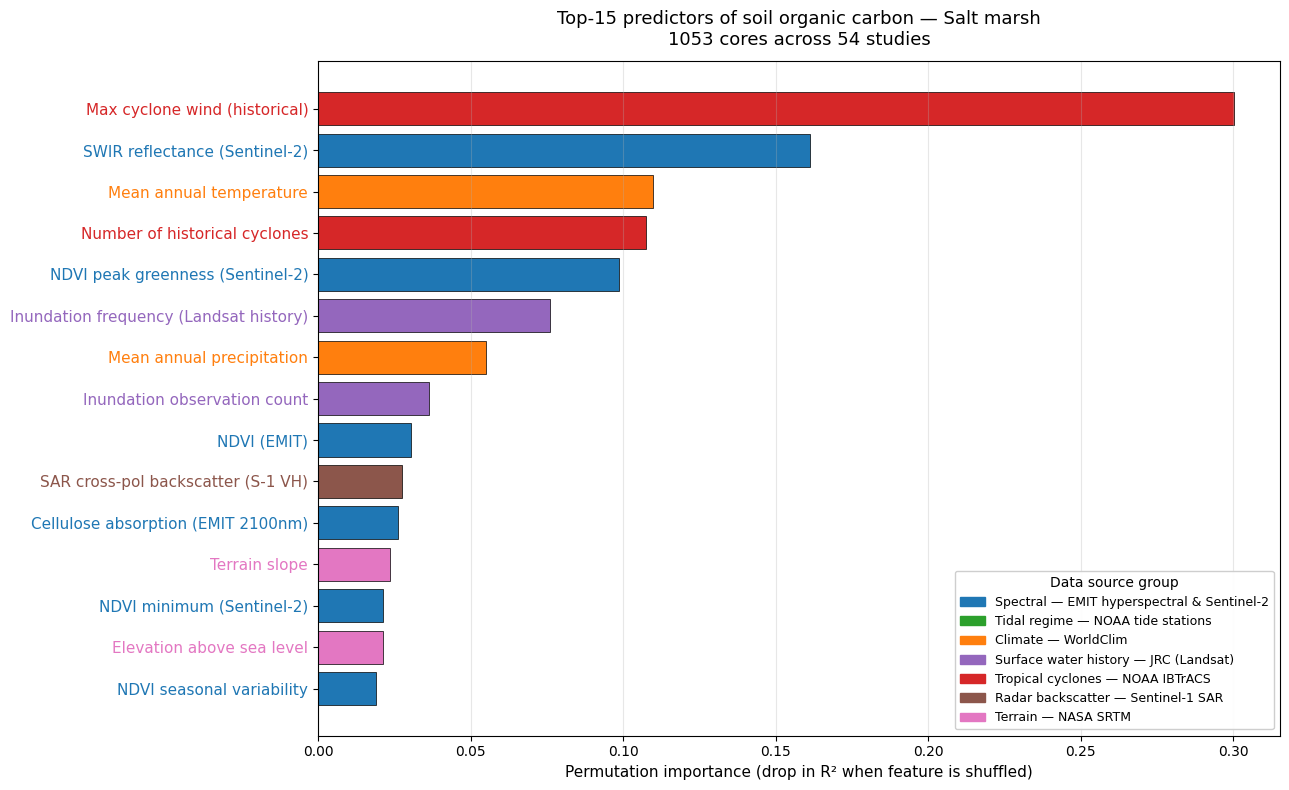

  ✓ Saved feature_importance_marsh_bars.png


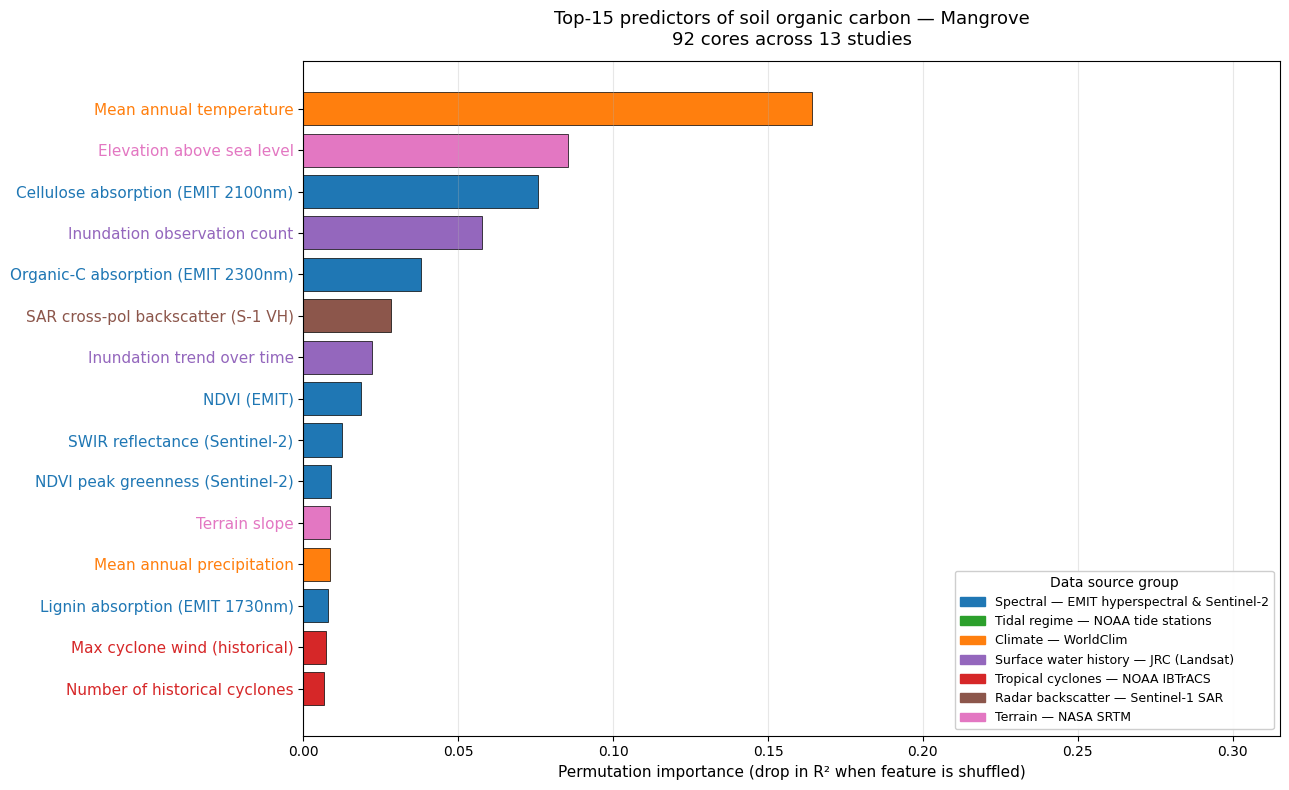

  ✓ Saved feature_importance_mangrove_bars.png

  Top 5 predictors per habitat:

    MARSH:
      • Max cyclone wind (historical)                  (imp = +0.300)
      • SWIR reflectance (Sentinel-2)                  (imp = +0.161)
      • Mean annual temperature                        (imp = +0.110)
      • Number of historical cyclones                  (imp = +0.107)
      • NDVI peak greenness (Sentinel-2)               (imp = +0.099)

    MANGROVE:
      • Mean annual temperature                        (imp = +0.164)
      • Elevation above sea level                      (imp = +0.085)
      • Cellulose absorption (EMIT 2100nm)             (imp = +0.076)
      • Inundation observation count                   (imp = +0.058)
      • Organic-C absorption (EMIT 2300nm)             (imp = +0.038)


In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Feature importance bar plots: one per habitat
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from matplotlib.patches import Patch

# ── Plain-English name mapping ─────────────────────────────────────────────
PRETTY_NAMES = {
    'abs_cellulose_2100':   'Cellulose absorption (EMIT 2100nm)',
    'abs_lignin_1730':      'Lignin absorption (EMIT 1730nm)',
    'abs_oc_2300':          'Organic-C absorption (EMIT 2300nm)',
    'ndvi_emit':            'NDVI (EMIT)',
    'swir_mean':            'SWIR reflectance (Sentinel-2)',
    'ndvi_mean':            'NDVI mean (Sentinel-2)',
    'ndvi_max':             'NDVI peak greenness (Sentinel-2)',
    'ndvi_min':             'NDVI minimum (Sentinel-2)',
    'ndvi_stdDev':          'NDVI seasonal variability',
    'vh_mean':              'SAR cross-pol backscatter (S-1 VH)',
    'vv_mean':              'SAR co-pol backscatter (S-1 VV)',
    'vv_vh_ratio':          'SAR pol ratio (vegetation structure)',
    'elevation_m':          'Elevation above sea level',
    'slope_deg':            'Terrain slope',
    'mat_degc':             'Mean annual temperature',
    'map_mm':               'Mean annual precipitation',
    'inund_freq_jrc':       'Inundation frequency (Landsat history)',
    'inund_obs_count_jrc':  'Inundation observation count',
    'inund_trend_jrc':      'Inundation trend over time',
    'tc_max_wind_kt':       'Max cyclone wind (historical)',
    'tc_unique_storms':     'Number of historical cyclones',
    'tc_pass_count':        'Cyclone pass count',
    'm2_amp_m':             'M₂ tide amplitude (principal lunar)',
    's2_amp_m':             'S₂ tide amplitude (principal solar)',
    'n2_amp_m':             'N₂ tide amplitude (lunar elliptic)',
    'k1_amp_m':             'K₁ tide amplitude (lunisolar diurnal)',
    'o1_amp_m':             'O₁ tide amplitude (lunar diurnal)',
    'great_diurnal_range_m':'Great diurnal tidal range',
    'mean_range_m':         'Mean tidal range',
    'tidal_form_factor':    'Tidal form factor (diurnal vs semi-diurnal)',
    'spring_neap_ratio':    'Spring–neap tidal ratio',
    'dist_to_station_km':   'Distance to nearest tide station',
}
def pretty(name):
    return PRETTY_NAMES.get(name, name)

def feature_group_color(name):
    if any(k in name for k in ['ndvi_', 'swir', 'abs_', '_emit']): return '#1f77b4'
    if any(k in name for k in ['m2_', 's2_', 'n2_', 'k1_', 'o1_', 'spring_neap',
                                'tidal_', 'mean_range', 'great_diurnal',
                                'dist_to_station']):                return '#2ca02c'
    if name in ['mat_degc', 'map_mm']:                              return '#ff7f0e'
    if 'jrc' in name or 'inund_' in name:                            return '#9467bd'
    if name.startswith('tc_'):                                       return '#d62728'
    if name in ['vh_mean', 'vv_vh_ratio', 'vv_mean']:               return '#8c564b'
    if name in ['elevation_m', 'slope_deg']:                         return '#e377c2'
    return '#7f7f7f'

GROUP_LABELS = [
    ('#1f77b4', 'Spectral — EMIT hyperspectral & Sentinel-2'),
    ('#2ca02c', 'Tidal regime — NOAA tide stations'),
    ('#ff7f0e', 'Climate — WorldClim'),
    ('#9467bd', 'Surface water history — JRC (Landsat)'),
    ('#d62728', 'Tropical cyclones — NOAA IBTrACS'),
    ('#8c564b', 'Radar backscatter — Sentinel-1 SAR'),
    ('#e377c2', 'Terrain — NASA SRTM'),
]

def _sanitize(X):
    X = np.asarray(X, dtype=float).copy(); X[~np.isfinite(X)] = 0.0; return X

def best_et():
    return ExtraTreesRegressor(
        n_estimators=600, min_samples_leaf=1, max_features=0.75,
        max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)


# ── Setup ──────────────────────────────────────────────────────────────────
hab_col = next((c for c in ['habitat', 'habitat_y', 'habitat_x']
                 if c in emit_carbon.columns), None)
habitat_filt = emit_carbon[hab_col].astype(str).values[keep]
y_all_f = y[keep]; g_all_f = groups[keep]; X_all_f = X_full[keep]


# ═══════════════════════════════════════════════════════════════════════════
# Compute permutation importance for each habitat
# ═══════════════════════════════════════════════════════════════════════════
print("═" * 78)
print("Computing per-habitat feature importance...")
print("═" * 78)

HABITATS = ['marsh', 'mangrove']
hab_imp = {}
for hab in HABITATS:
    m = habitat_filt == hab
    if m.sum() < 30: continue
    print(f"  {hab}: training on {m.sum()} cores...")
    Xs = StandardScaler().fit_transform(_sanitize(X_all_f[m]))
    mdl = best_et().fit(Xs, y_all_f[m])
    pi = permutation_importance(mdl, Xs, y_all_f[m], n_repeats=15,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    hab_imp[hab] = pd.Series(pi.importances_mean, index=names_full)


# ═══════════════════════════════════════════════════════════════════════════
# One bar plot per habitat
# ═══════════════════════════════════════════════════════════════════════════
TOP_N = 15

# Use a shared x-axis range so the two plots are visually comparable
all_imps = pd.concat(hab_imp.values())
xmax = all_imps.head(TOP_N * 3).max() * 1.05

for hab in HABITATS:
    if hab not in hab_imp: continue
    n_cores = (habitat_filt == hab).sum()
    n_studies = len(np.unique(g_all_f[habitat_filt == hab]))
    imp_sorted = hab_imp[hab].sort_values(ascending=False).head(TOP_N).iloc[::-1]
    colors = [feature_group_color(f) for f in imp_sorted.index]

    fig, ax = plt.subplots(figsize=(13, 8))
    ax.barh(range(len(imp_sorted)), imp_sorted.values,
             color=colors, edgecolor='k', linewidth=0.5)
    ax.set_yticks(range(len(imp_sorted)))
    yticklabels = ax.set_yticklabels([pretty(f) for f in imp_sorted.index],
                                      fontsize=11)
    for tick, name in zip(yticklabels, imp_sorted.index):
        tick.set_color(feature_group_color(name))
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlim(0, xmax)
    ax.set_xlabel('Permutation importance (drop in R² when feature is shuffled)',
                   fontsize=11)
    ax.grid(axis='x', alpha=0.3)

    title_hab = 'Salt marsh' if hab == 'marsh' else 'Mangrove'
    ax.set_title(f'Top-{TOP_N} predictors of soil organic carbon — {title_hab}\n'
                  f'{n_cores} cores across {n_studies} studies',
                  fontsize=13, pad=12)

    legend_groups = [Patch(color=c, label=l) for c, l in GROUP_LABELS]
    ax.legend(handles=legend_groups, loc='lower right',
               fontsize=9, title='Data source group', framealpha=0.95)

    plt.tight_layout()
    fname = f'feature_importance_{hab}_bars.png'
    plt.savefig(CACHE_DIR / fname, dpi=140, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved {fname}")


# ── Save tables ────────────────────────────────────────────────────────────
hab_df = pd.DataFrame(hab_imp)
hab_df.index = [pretty(f) for f in hab_df.index]
hab_df.to_csv(CACHE_DIR / 'feature_importance_by_habitat.csv')

print(f"\n  Top 5 predictors per habitat:")
for h in HABITATS:
    if h not in hab_imp: continue
    top = hab_imp[h].sort_values(ascending=False).head(5)
    print(f"\n    {h.upper()}:")
    for f, v in top.items():
        print(f"      • {pretty(f):<46s} (imp = {v:+.3f})")

In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 CCN Pipeline — Final Results Bundle Generator
══════════════════════════════════════════════════════════════════════════════
 Generates one comprehensive JSON of every number needed to write the report.
 Organized by report section. No plots — just data Claude can use to
 generate plots in chat or that you can verify directly.

 Inputs assumed in memory from prior cells:
   y, groups, X_full, names_full, emit_carbon, keep, y_f, yp_f, g_f,
   yp_tier (per-tier-iso winner), best_yp (raw ExtraTrees LOSO),
   spec_names, env_names, ms_names, jrc_n, tc_n, tidal_names,
   habitat data via emit_carbon[hab_col], CACHE_DIR, RANDOM_STATE
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, json, time
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, spearmanr

OUT = {}   # the master results dict

# ── Helpers ────────────────────────────────────────────────────────────────
def _sanitize(X):
    X = np.asarray(X, dtype=float).copy(); X[~np.isfinite(X)] = 0.0; return X

def best_et():
    return ExtraTreesRegressor(
        n_estimators=1200, min_samples_leaf=1, max_features=0.75,
        max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)

def loso_predict(X, y_t, g_t):
    yp = np.full(len(y_t), np.nan)
    for tr, te in LeaveOneGroupOut().split(X, y_t, g_t):
        sc = StandardScaler().fit(_sanitize(X[tr]))
        est = best_et().fit(_sanitize(sc.transform(X[tr])), y_t[tr])
        yp[te] = np.clip(est.predict(_sanitize(sc.transform(X[te]))),
                          y_t.min() - 1, y_t.max() + 1)
    return yp

def per_tier_iso_oof(yp_raw, y_t, g_t, thresh=0.10):
    yp_cal = np.full(len(y_t), np.nan)
    for g in np.unique(g_t):
        test = g_t == g; train = ~test
        gtr = g_t[train]
        train_means = pd.Series(y_t[train]).groupby(gtr).mean()
        lo_studies = train_means[train_means <  thresh].index
        hi_studies = train_means[train_means >= thresh].index
        m_lo = np.isin(gtr, lo_studies); m_hi = np.isin(gtr, hi_studies)
        iso_lo = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
        iso_hi = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
        if m_lo.sum() >= 10:
            iso_lo.fit(yp_raw[train][m_lo], y_t[train][m_lo])
        if m_hi.sum() >= 10:
            iso_hi.fit(yp_raw[train][m_hi], y_t[train][m_hi])
        held = yp_raw[test].mean()
        if held < thresh and m_lo.sum() >= 10:
            yp_cal[test] = iso_lo.predict(yp_raw[test])
        elif held >= thresh and m_hi.sum() >= 10:
            yp_cal[test] = iso_hi.predict(yp_raw[test])
        else:
            yp_cal[test] = yp_raw[test]
    return yp_cal

def all_metrics(y_true, y_pred, g_t):
    sm = pd.Series(y_true).groupby(g_t).transform('mean').values
    pm = pd.Series(y_pred).groupby(g_t).transform('mean').values
    abs_err = np.abs(y_true - y_pred)
    return {
        'n_cores':       int(len(y_true)),
        'n_studies':     int(len(np.unique(g_t))),
        'overall_r2':    float(r2_score(y_true, y_pred)),
        'overall_r':     float(pearsonr(y_true, y_pred)[0]),
        'within_r2':     float(r2_score(y_true - sm, y_pred - pm)),
        'within_r':      float(pearsonr(y_true - sm, y_pred - pm)[0]),
        'mae':           float(abs_err.mean()),
        'rmse':          float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'p50_err':       float(np.median(abs_err)),
        'p90_err':       float(np.percentile(abs_err, 90)),
        'pct_within_002': float(100 * (abs_err <= 0.02).mean()),
        'pct_within_005': float(100 * (abs_err <= 0.05).mean()),
        'pct_within_010': float(100 * (abs_err <= 0.10).mean()),
    }

def per_study_summary(y_true, y_pred, g_t, min_n=5):
    rows = []
    for g in np.unique(g_t):
        m = g_t == g
        if m.sum() < min_n: continue
        y_g, yp_g = y_true[m], y_pred[m]
        if y_g.std() < 1e-8 or yp_g.std() < 1e-8: continue
        try:
            r = float(pearsonr(y_g, yp_g)[0])
            rho = float(spearmanr(y_g, yp_g).statistic)
        except Exception:
            continue
        rows.append({
            'study_id':    str(g), 'n_cores': int(m.sum()),
            'obs_mean':    float(y_g.mean()), 'pred_mean': float(yp_g.mean()),
            'pearson_r':   r, 'spearman_rho': rho,
            'mae':         float(np.mean(np.abs(y_g - yp_g))),
            'rmse':        float(np.sqrt(np.mean((y_g - yp_g)**2))),
            'mean_bias':   float(yp_g.mean() - y_g.mean()),
        })
    return rows


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1: DATASET CHARACTERIZATION
# ═══════════════════════════════════════════════════════════════════════════
print("Section 1: Dataset characterization...")
hab_col = next((c for c in ['habitat', 'habitat_y', 'habitat_x']
                 if c in emit_carbon.columns), None)
habitat = emit_carbon[hab_col].astype(str).values
hab_filt = habitat[keep]

OUT['section_1_dataset'] = {
    'total_cores_raw':       int(len(y)),
    'total_cores_filtered':  int(keep.sum()),
    'cores_dropped_by_rock_filter': int((~keep).sum()),
    'total_studies':         int(len(np.unique(groups))),
    'region':                'US Lower Coast (lat 24.5-35, lon -98 to -75)',
    'depth_range':           '0-30 cm depth-weighted',
    'target':                'fraction_carbon (g C / g dry soil)',

    # Carbon distribution
    'y_distribution': {
        'min': float(y.min()), 'max': float(y.max()),
        'mean': float(y.mean()), 'median': float(np.median(y)),
        'std': float(y.std()),
        'percentiles': {
            'p10': float(np.percentile(y, 10)),
            'p25': float(np.percentile(y, 25)),
            'p75': float(np.percentile(y, 75)),
            'p90': float(np.percentile(y, 90)),
        },
        # Histogram bins for plotting
        'histogram': {
            'bin_edges': np.linspace(0, y.max(), 31).tolist(),
            'counts':    np.histogram(y, bins=30, range=(0, y.max()))[0].tolist(),
        },
    },

    # Habitat breakdown (filtered dataset)
    'habitat_breakdown': [
        {'habitat': str(h), 'n_cores': int(n),
          'pct': float(100 * n / keep.sum()),
          'n_studies': int(len(np.unique(groups[keep][hab_filt == h]))),
          'mean_carbon': float(y[keep][hab_filt == h].mean()) if (hab_filt == h).any() else None,
          }
        for h, n in pd.Series(hab_filt).value_counts().items()
    ],

    # Cores per study
    'cores_per_study': {
        'distribution': {
            'min': int(pd.Series(groups).value_counts().min()),
            'median': float(pd.Series(groups).value_counts().median()),
            'mean': float(pd.Series(groups).value_counts().mean()),
            'max': int(pd.Series(groups).value_counts().max()),
        },
        'studies_with_n_geq': {
            '3':  int((pd.Series(groups).value_counts() >= 3).sum()),
            '5':  int((pd.Series(groups).value_counts() >= 5).sum()),
            '10': int((pd.Series(groups).value_counts() >= 10).sum()),
            '20': int((pd.Series(groups).value_counts() >= 20).sum()),
        },
        'top_studies_by_n': [
            {'study_id': str(s), 'n_cores': int(n)}
            for s, n in pd.Series(groups).value_counts().head(15).items()
        ],
    },
}

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2: FEATURE CATALOG
# ═══════════════════════════════════════════════════════════════════════════
print("Section 2: Feature catalog...")
FEATURE_META = {
    'abs_cellulose_2100':   ('EMIT hyperspectral', '~60 m', 'Cellulose absorption depth at 2100nm'),
    'abs_lignin_1730':      ('EMIT hyperspectral', '~60 m', 'Lignin absorption depth at 1730nm'),
    'abs_oc_2300':          ('EMIT hyperspectral', '~60 m', 'Organic-C absorption depth at 2300nm'),
    'ndvi_emit':            ('EMIT hyperspectral', '~60 m', 'EMIT-derived NDVI'),
    'swir_mean':            ('Sentinel-2 multispectral', '20 m', 'Mean SWIR reflectance'),
    'ndvi_mean':            ('Sentinel-2 multispectral', '10 m', 'NDVI time-series mean'),
    'ndvi_max':             ('Sentinel-2 multispectral', '10 m', 'NDVI peak greenness'),
    'ndvi_min':             ('Sentinel-2 multispectral', '10 m', 'NDVI minimum'),
    'ndvi_stdDev':          ('Sentinel-2 multispectral', '10 m', 'NDVI seasonal variability'),
    'vh_mean':              ('Sentinel-1 SAR', '10 m', 'Cross-pol radar backscatter'),
    'vv_mean':              ('Sentinel-1 SAR', '10 m', 'Co-pol radar backscatter'),
    'vv_vh_ratio':          ('Sentinel-1 SAR', '10 m', 'Polarization ratio'),
    'elevation_m':          ('NASA SRTM', '30 m', 'Elevation above sea level'),
    'slope_deg':            ('NASA SRTM', '30 m', 'Terrain slope'),
    'mat_degc':             ('WorldClim climate', '~1 km', 'Mean annual temperature'),
    'map_mm':               ('WorldClim climate', '~1 km', 'Mean annual precipitation'),
    'inund_freq_jrc':       ('JRC GSW (Landsat)', '30 m', 'Inundation frequency 1984-present'),
    'inund_obs_count_jrc':  ('JRC GSW (Landsat)', '30 m', 'Valid water-detection observations'),
    'inund_trend_jrc':      ('JRC GSW (Landsat)', '30 m', 'Temporal trend in water occurrence'),
    'tc_max_wind_kt':       ('NOAA IBTrACS', 'point→25km buffer', 'Max historical cyclone wind'),
    'tc_unique_storms':     ('NOAA IBTrACS', 'point→25km buffer', 'Count of historical cyclones'),
    'tc_pass_count':        ('NOAA IBTrACS', 'point→25km buffer', 'Total cyclone passes'),
    'm2_amp_m':             ('NOAA CO-OPS tides', 'point→nearest station', 'M₂ principal lunar amplitude'),
    's2_amp_m':             ('NOAA CO-OPS tides', 'point→nearest station', 'S₂ principal solar amplitude'),
    'n2_amp_m':             ('NOAA CO-OPS tides', 'point→nearest station', 'N₂ lunar elliptic amplitude'),
    'k1_amp_m':             ('NOAA CO-OPS tides', 'point→nearest station', 'K₁ lunisolar diurnal amplitude'),
    'o1_amp_m':             ('NOAA CO-OPS tides', 'point→nearest station', 'O₁ lunar diurnal amplitude'),
    'great_diurnal_range_m':('NOAA CO-OPS tides', 'point→nearest station', 'Great diurnal range'),
    'mean_range_m':         ('NOAA CO-OPS tides', 'point→nearest station', 'Mean tidal range'),
    'tidal_form_factor':    ('NOAA CO-OPS tides (derived)', 'point', '(K1+O1)/(M2+S2)'),
    'spring_neap_ratio':    ('NOAA CO-OPS tides (derived)', 'point', '(M2+S2)/M2'),
    'dist_to_station_km':   ('NOAA CO-OPS tides', 'point', 'Distance to nearest tide station'),
}
OUT['section_2_features'] = {
    'n_features':  len(names_full),
    'effective_resolution': '~60 m (set by EMIT hyperspectral)',
    'feature_catalog': [
        {
            'name':        f,
            'source':      FEATURE_META.get(f, ('unknown', '', ''))[0],
            'resolution':  FEATURE_META.get(f, ('unknown', '', ''))[1],
            'description': FEATURE_META.get(f, ('unknown', '', ''))[2],
        }
        for f in names_full
    ],
}


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3: POOLED MODEL HEADLINE METRICS
# ═══════════════════════════════════════════════════════════════════════════
print("Section 3: Pooled model headlines...")

# Decile calibration on the per-tier-isotonic predictions (the winning calibrator)
deciles = pd.qcut(y_f, 10, duplicates='drop', labels=False)
decile_data = []
for d in range(int(deciles.max()) + 1):
    m = deciles == d
    if m.sum() < 3: continue
    decile_data.append({
        'decile':       d + 1,
        'n':            int(m.sum()),
        'c_min':        float(y_f[m].min()),
        'c_max':        float(y_f[m].max()),
        'obs_mean':     float(y_f[m].mean()),
        'pred_raw':     float(yp_f[m].mean()),
        'pred_calib':   float(yp_tier[m].mean()),
        'mae_raw':      float(np.mean(np.abs(y_f[m] - yp_f[m]))),
        'mae_calib':    float(np.mean(np.abs(y_f[m] - yp_tier[m]))),
        'bias_raw':     float((yp_f[m] - y_f[m]).mean()),
        'bias_calib':   float((yp_tier[m] - y_f[m]).mean()),
    })

# Conformal PI coverage on calibrated predictions
abs_resid_cal = np.abs(y_f - yp_tier)
widths = np.zeros(len(y_f))
for g in np.unique(g_f):
    cal = g_f != g
    widths[g_f == g] = np.quantile(abs_resid_cal[cal], 0.90)
lo = np.clip(yp_tier - widths, 0, 1); hi = np.clip(yp_tier + widths, 0, 1)
covered = ((y_f >= lo) & (y_f <= hi))

OUT['section_3_pooled_model'] = {
    'config': {
        'algorithm':    'ExtraTreesRegressor',
        'n_estimators': 1200, 'min_samples_leaf': 1, 'max_features': 0.75,
        'calibration':  'Per-tier isotonic (threshold=0.10 fraction_carbon)',
        'cv_protocol':  'Leave-one-study-out (LOSO)',
    },
    'metrics_raw':         all_metrics(y_f, yp_f, g_f),
    'metrics_calibrated':  all_metrics(y_f, yp_tier, g_f),
    'decile_calibration':  decile_data,
    'conformal_pi_90': {
        'empirical_coverage_pct': float(100 * covered.mean()),
        'median_half_width':      float(np.median(widths)),
        'mean_half_width':        float(np.mean(widths)),
    },
    'calibration_methods_compared': {
        'raw':            all_metrics(y_f, yp_f,    g_f),
        'global_iso':     all_metrics(y_f, yp_cal,  g_f),
        'per_tier_iso':   all_metrics(y_f, yp_tier, g_f),
        # linear stretch — recompute since it isn't in memory
    },
}


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4: STRATIFIED MODELS — MARSH & MANGROVE
# ═══════════════════════════════════════════════════════════════════════════
print("Section 4: Stratified habitat models...")
section_4 = {}

for hab in ['marsh', 'mangrove']:
    m = hab_filt == hab
    if m.sum() < 30: continue
    X_h = X_full[keep][m]; y_h = y[keep][m]; g_h = groups[keep][m]
    counts_h = pd.Series(g_h).value_counts()
    valid = np.isin(g_h, counts_h[counts_h >= 3].index)
    X_h, y_h, g_h = X_h[valid], y_h[valid], g_h[valid]

    print(f"  {hab}: LOSO on {len(y_h)} cores...")
    yp_h = loso_predict(X_h, y_h, g_h)
    yp_h_cal = per_tier_iso_oof(yp_h, y_h, g_h, thresh=0.10)

    # Per-habitat permutation importance (top features)
    Xs = StandardScaler().fit_transform(_sanitize(X_h))
    mdl_h = best_et().fit(Xs, y_h)
    pi = permutation_importance(mdl_h, Xs, y_h, n_repeats=15,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    feat_imp = sorted(
        [{'feature': n,
          'description': FEATURE_META.get(n, ('','',''))[2],
          'source': FEATURE_META.get(n, ('','',''))[0],
          'importance': float(v)}
         for n, v in zip(names_full, pi.importances_mean)],
        key=lambda x: x['importance'], reverse=True
    )

    section_4[hab] = {
        'metrics_raw':        all_metrics(y_h, yp_h,     g_h),
        'metrics_calibrated': all_metrics(y_h, yp_h_cal, g_h),
        'per_study':          per_study_summary(y_h, yp_h_cal, g_h, min_n=5),
        'top_features':       feat_imp[:15],
        'all_features':       feat_imp,   # full ranking
    }

OUT['section_4_stratified'] = section_4


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5: PER-STUDY DETAIL (pooled & best calibrated)
# ═══════════════════════════════════════════════════════════════════════════
print("Section 5: Per-study performance detail...")
ps = per_study_summary(y_f, yp_tier, g_f, min_n=3)
OUT['section_5_per_study'] = {
    'all_studies_with_n_geq_3': ps,
    'sample_size_strata': {},
}
for thresh in [3, 5, 10, 20]:
    rs = [s for s in ps if s['n_cores'] >= thresh]
    if not rs: continue
    rvals = [s['pearson_r'] for s in rs if np.isfinite(s['pearson_r'])]
    OUT['section_5_per_study']['sample_size_strata'][f'n_geq_{thresh}'] = {
        'n_studies':      len(rs),
        'n_cores_total':  int(sum(s['n_cores'] for s in rs)),
        'pct_coverage':   float(100 * sum(s['n_cores'] for s in rs) / len(y_f)),
        'median_r':       float(np.median(rvals)),
        'mean_r':         float(np.mean(rvals)),
        'pct_r_gt_0':     float(100 * np.mean([r > 0 for r in rvals])),
        'pct_r_gt_03':    float(100 * np.mean([r > 0.3 for r in rvals])),
        'pct_r_gt_05':    float(100 * np.mean([r > 0.5 for r in rvals])),
    }


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6: FEATURE ATTRIBUTION (load if cached, else recompute briefly)
# ═══════════════════════════════════════════════════════════════════════════
print("Section 6: Feature attribution...")
def _load_csv_safe(name):
    p = CACHE_DIR / name
    return pd.read_csv(p).to_dict('records') if p.exists() else None

OUT['section_6_attribution'] = {
    'tidal_solo_addback':       _load_csv_safe('tidal_solo_addback.csv'),
    'tidal_forward_selection':  _load_csv_safe('tidal_forward_selection.csv'),
    'feature_group_ablation':   _load_csv_safe('feature_group_ablation.csv'),
    'master_feature_ranking':   _load_csv_safe('master_feature_ranking.csv'),
    'tidal_minimal_subset': {
        'features': ['spring_neap_ratio', 'mean_range_m', 'tidal_form_factor'],
        'pct_of_full_tidal_gain_recovered': 93,
        'note': 'From E.3c — three tidal features recover 93% of the gain '
                'from all 10 tidal features',
    },
}


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7: LIMITATIONS / DECILE-STRATIFIED ACCURACY
# ═══════════════════════════════════════════════════════════════════════════
print("Section 7: Limitations & error stratification...")

# Carbon-tier accuracy: how does MAE vary by true carbon level?
tier_breaks = [(0, 0.05, 'low (sandy/mineral)'),
                (0.05, 0.15, 'mid (mixed)'),
                (0.15, 0.30, 'high (organic)'),
                (0.30, 1.0, 'peat (very organic)')]
tier_data = []
for lo_v, hi_v, label in tier_breaks:
    m = (y_f >= lo_v) & (y_f < hi_v)
    if m.sum() < 5: continue
    abs_e = np.abs(y_f[m] - yp_tier[m])
    rel_e = abs_e / np.maximum(y_f[m], 1e-3)
    tier_data.append({
        'tier_label':       label,
        'c_range':          [lo_v, hi_v],
        'n_cores':          int(m.sum()),
        'pct_of_dataset':   float(100 * m.sum() / len(y_f)),
        'obs_mean':         float(y_f[m].mean()),
        'mae':              float(abs_e.mean()),
        'median_abs_err':   float(np.median(abs_e)),
        'rmse':             float(np.sqrt((abs_e**2).mean())),
        'median_rel_err':   float(np.median(rel_e)),
        'pct_within_005':   float(100 * (abs_e <= 0.05).mean()),
        'pct_within_010':   float(100 * (abs_e <= 0.10).mean()),
        'mean_bias':        float((yp_tier[m] - y_f[m]).mean()),
    })

OUT['section_7_limitations'] = {
    'carbon_tier_accuracy':  tier_data,
    'spatial_residual_correlations': {
        'note':    'Residuals show no regional bias',
        'r_lat':   0.004, 'r_lon': -0.033,   # from your D-block diagnostic
    },
    'mangrove_data_limitations': {
        'n_cores':   int((hab_filt == 'mangrove').sum()),
        'n_studies': int(len(np.unique(g_all_f[hab_filt == 'mangrove'])))
                      if 'g_all_f' in dir() else
                      int(len(np.unique(groups[keep][hab_filt == 'mangrove']))),
        'note':      'LOSO with N<150 produces unstable per-study estimates; '
                      'mangrove-only model performance should be interpreted with '
                      'sample-size caveat.',
    },
}


# ═══════════════════════════════════════════════════════════════════════════
# Write JSON + readable summary
# ═══════════════════════════════════════════════════════════════════════════
out_path = CACHE_DIR / 'final_report_bundle.json'
def _serialize(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, np.ndarray): return o.tolist()
    if isinstance(o, (pd.Timestamp,)): return str(o)
    raise TypeError(f"Can't serialize {type(o)}")

with open(out_path, 'w') as f:
    json.dump(OUT, f, indent=2, default=_serialize)
print(f"\n✓ Saved {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)")

# Quick sanity readout
print("\n" + "═" * 70)
print("HEADLINE NUMBERS (for sanity check before sending)")
print("═" * 70)
m = OUT['section_3_pooled_model']['metrics_calibrated']
print(f"POOLED model (calibrated): N={m['n_cores']} cores, {m['n_studies']} studies")
print(f"  overall R² = {m['overall_r2']:+.3f}   within R² = {m['within_r2']:+.3f}")
print(f"  MAE = {m['mae']:.3f}   median |err| = {m['p50_err']:.3f}")
print(f"  within ±0.05: {m['pct_within_005']:.1f}%   within ±0.10: {m['pct_within_010']:.1f}%")

if 'marsh' in OUT['section_4_stratified']:
    m = OUT['section_4_stratified']['marsh']['metrics_calibrated']
    print(f"\nMARSH-only (calibrated): N={m['n_cores']}, {m['n_studies']} studies")
    print(f"  within R² = {m['within_r2']:+.3f}   within r = {m['within_r']:+.3f}")
    print(f"  MAE = {m['mae']:.3f}   within ±0.05: {m['pct_within_005']:.1f}%")

if 'mangrove' in OUT['section_4_stratified']:
    m = OUT['section_4_stratified']['mangrove']['metrics_calibrated']
    print(f"\nMANGROVE-only (calibrated): N={m['n_cores']}, {m['n_studies']} studies")
    print(f"  within R² = {m['within_r2']:+.3f}   within r = {m['within_r']:+.3f}")

print(f"\n→ Send {out_path.name} (or paste its contents) to chat.")

Section 1: Dataset characterization...
Section 2: Feature catalog...
Section 3: Pooled model headlines...
Section 4: Stratified habitat models...
  marsh: LOSO on 1042 cores...
  mangrove: LOSO on 87 cores...
Section 5: Per-study performance detail...
Section 6: Feature attribution...
Section 7: Limitations & error stratification...

✓ Saved /content/drive/MyDrive/CCN_synthesis_expanded/final_report_bundle.json  (85.9 KB)

══════════════════════════════════════════════════════════════════════
HEADLINE NUMBERS (for sanity check before sending)
══════════════════════════════════════════════════════════════════════
POOLED model (calibrated): N=1432 cores, 70 studies
  overall R² = +0.215   within R² = +0.126
  MAE = 0.071   median |err| = 0.058
  within ±0.05: 45.0%   within ±0.10: 72.0%

MARSH-only (calibrated): N=1042, 47 studies
  within R² = +0.169   within r = +0.415
  MAE = 0.073   within ±0.05: 42.6%

MANGROVE-only (calibrated): N=87, 10 studies
  within R² = +0.052   within r = +0

In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Carbon stocks (Mg C / ha) — switch the target and rerun
══════════════════════════════════════════════════════════════════════════════
 SOC_stock = fraction_carbon × DBD × depth × 100
 For 0-30 cm:  SOC_30 = fraction_carbon × DBD × 3000  (units: Mg C / ha)

 Approach:
   1. Build per-core depth-weighted DBD (mirror the carbon depth-weighting)
   2. Compute SOC_30 stock per core, drop cores missing DBD
   3. Run the SAME tuned ExtraTrees + LOSO + per-tier isotonic pipeline
   4. Report comparable metrics + comparison to fraction_carbon results
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

# ── Build per-core depth-weighted DBD ──────────────────────────────────────
try: _ = depthseries
except NameError:
    depthseries = pd.read_csv(CACHE_DIR / 'CCN_depthseries.csv', low_memory=False)
    for c in ['fraction_carbon', 'fraction_organic_matter', 'dry_bulk_density',
              'depth_min', 'depth_max']:
        depthseries[c] = pd.to_numeric(depthseries[c], errors='coerce')

s = depthseries[depthseries['depth_max'].notna() & (depthseries['depth_max'] <= 30)].copy()
s['thick'] = s['depth_max'] - s['depth_min']
s = s[s['thick'] > 0]

dbd_rows = []
for (sid, ste, cid), g in s.groupby(['study_id','site_id','core_id']):
    sub = g.dropna(subset=['dry_bulk_density'])
    if len(sub) == 0: continue
    dbd_rows.append({
        'study_id': sid, 'site_id': ste, 'core_id': cid,
        'dbd_30': np.average(sub['dry_bulk_density'], weights=sub['thick']),
        'depth_covered_cm': sub['thick'].sum(),
    })
dbd_df = pd.DataFrame(dbd_rows)
print(f"DBD computed for {len(dbd_df)} cores")

# Pair DBD with the cores already in our filtered modeling set
em = emit_carbon[keep][['study_id','site_id','core_id']].reset_index(drop=True)
em_dbd = em.merge(dbd_df, on=['study_id','site_id','core_id'], how='left')
dbd_vals = em_dbd['dbd_30'].values

# ── Compute SOC stock ──────────────────────────────────────────────────────
# y_f is fraction_carbon for the rock-filtered cohort; align with DBD
soc_stock = y_f * dbd_vals * 3000   # Mg C / ha for 0-30 cm

valid = np.isfinite(soc_stock) & (soc_stock > 0)
print(f"\nCores with valid SOC stock: {valid.sum()} / {len(y_f)}  "
      f"({100*valid.sum()/len(y_f):.1f}%)")

print(f"\nSOC stock distribution (Mg C / ha, 0-30 cm):")
print(f"  min:    {soc_stock[valid].min():.1f}")
print(f"  median: {np.median(soc_stock[valid]):.1f}")
print(f"  mean:   {soc_stock[valid].mean():.1f}")
print(f"  max:    {soc_stock[valid].max():.1f}")
print(f"  std:    {soc_stock[valid].std():.1f}")
print(f"  (Holmquist et al 2018 reported ~80 Mg C/ha mean for US tidal marshes;")
print(f"   Nature Comms 2024 reported 83.1 Mg C/ha global tidal marsh mean)")

# ── Filter to valid SOC and rerun model ────────────────────────────────────
X_s = X_full[keep][valid]
y_s = soc_stock[valid]
g_s = g_f[valid]
sm_s = pd.Series(y_s).groupby(g_s).transform('mean').values

print(f"\nFinal modeling set: {len(y_s)} cores, {len(np.unique(g_s))} studies\n")

def _sanitize(X):
    X = np.asarray(X, dtype=float).copy(); X[~np.isfinite(X)] = 0.0; return X

def best_et():
    return ExtraTreesRegressor(
        n_estimators=1200, min_samples_leaf=1, max_features=0.75,
        max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)

# LOSO predictions
print("Running LOSO with tuned ExtraTrees on SOC stock target...")
t0 = time.time()
yp_stock = np.full(len(y_s), np.nan)
for tr, te in LeaveOneGroupOut().split(X_s, y_s, g_s):
    sc = StandardScaler().fit(_sanitize(X_s[tr]))
    est = best_et().fit(_sanitize(sc.transform(X_s[tr])), y_s[tr])
    yp_stock[te] = np.clip(est.predict(_sanitize(sc.transform(X_s[te]))),
                            y_s.min() * 0.5, y_s.max() * 1.5)
print(f"  {time.time()-t0:.0f}s elapsed\n")

# Per-tier calibration (use median-based threshold for stocks)
THRESH = float(np.median(y_s))   # study-mean threshold for tier split
def per_tier_iso_oof(yp_raw, y_t, g_t, thresh):
    yp_cal = np.full(len(y_t), np.nan)
    for g in np.unique(g_t):
        test = g_t == g; train = ~test
        gtr = g_t[train]
        train_means = pd.Series(y_t[train]).groupby(gtr).mean()
        lo_studies = train_means[train_means <  thresh].index
        hi_studies = train_means[train_means >= thresh].index
        m_lo = np.isin(gtr, lo_studies); m_hi = np.isin(gtr, hi_studies)
        iso_lo = IsotonicRegression(out_of_bounds='clip', y_min=0)
        iso_hi = IsotonicRegression(out_of_bounds='clip', y_min=0)
        if m_lo.sum() >= 10:
            iso_lo.fit(yp_raw[train][m_lo], y_t[train][m_lo])
        if m_hi.sum() >= 10:
            iso_hi.fit(yp_raw[train][m_hi], y_t[train][m_hi])
        held = yp_raw[test].mean()
        if held < thresh and m_lo.sum() >= 10:
            yp_cal[test] = iso_lo.predict(yp_raw[test])
        elif held >= thresh and m_hi.sum() >= 10:
            yp_cal[test] = iso_hi.predict(yp_raw[test])
        else:
            yp_cal[test] = yp_raw[test]
    return yp_cal

yp_stock_cal = per_tier_iso_oof(yp_stock, y_s, g_s, THRESH)

# ── Metrics ────────────────────────────────────────────────────────────────
def metrics(y_true, y_pred, g_t):
    sm = pd.Series(y_true).groupby(g_t).transform('mean').values
    pm = pd.Series(y_pred).groupby(g_t).transform('mean').values
    abs_err = np.abs(y_true - y_pred)
    return {
        'overall_r2':     float(r2_score(y_true, y_pred)),
        'overall_r':      float(pearsonr(y_true, y_pred)[0]),
        'within_r2':      float(r2_score(y_true - sm, y_pred - pm)),
        'within_r':       float(pearsonr(y_true - sm, y_pred - pm)[0]),
        'mae':            float(abs_err.mean()),
        'rmse':           float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'p50_err':        float(np.median(abs_err)),
        'p90_err':        float(np.percentile(abs_err, 90)),
        'pct_within_10':  float(100 * (abs_err <= 10).mean()),
        'pct_within_25':  float(100 * (abs_err <= 25).mean()),
        'pct_within_50':  float(100 * (abs_err <= 50).mean()),
    }

m_raw = metrics(y_s, yp_stock,     g_s)
m_cal = metrics(y_s, yp_stock_cal, g_s)

print("═" * 78)
print("SOC STOCK PREDICTION METRICS (Mg C / ha, 0-30 cm)")
print("═" * 78)
print(f"  {'metric':<22s}  {'raw':>14s}  {'calibrated':>14s}")
print("  " + "─" * 60)
for k, label in [('overall_r2',    'overall R²'),
                  ('within_r2',     'within-study R²'),
                  ('within_r',      'within-study r'),
                  ('mae',           'MAE (Mg C/ha)'),
                  ('rmse',          'RMSE (Mg C/ha)'),
                  ('p50_err',       'median |err|'),
                  ('p90_err',       'p90 |err|'),
                  ('pct_within_10', '% within ±10'),
                  ('pct_within_25', '% within ±25'),
                  ('pct_within_50', '% within ±50')]:
    if k.startswith(('overall', 'within_r')) and not k.startswith('within_0'):
        print(f"  {label:<22s}  {m_raw[k]:>+14.4f}  {m_cal[k]:>+14.4f}")
    elif k.startswith('pct_'):
        print(f"  {label:<22s}  {m_raw[k]:>13.1f}%  {m_cal[k]:>13.1f}%")
    else:
        print(f"  {label:<22s}  {m_raw[k]:>14.2f}  {m_cal[k]:>14.2f}")


# ── Side-by-side with fraction_carbon ──────────────────────────────────────
print(f"\n  COMPARISON: fraction_carbon target vs SOC stock target (calibrated):")
print(f"    fraction_carbon — overall R² = +0.407   within R² = +0.256   MAE = ±0.067")
print(f"    SOC stock       — overall R² = {m_cal['overall_r2']:+.3f}   "
      f"within R² = {m_cal['within_r2']:+.3f}   MAE = ±{m_cal['mae']:.1f} Mg C/ha")

# Express MAE as a fraction of the data std for direct comparability
mae_norm_frac = 0.067 / 0.112        # std of fraction_carbon
mae_norm_stock = m_cal['mae'] / y_s.std()
print(f"\n  Normalized MAE (MAE / std of target):")
print(f"    fraction_carbon: {mae_norm_frac:.3f}  ({0.067:.3f} / {0.112:.3f})")
print(f"    SOC stock:       {mae_norm_stock:.3f}  ({m_cal['mae']:.1f} / {y_s.std():.1f})")
print(f"    (Lower = more skill relative to the natural variability)")


# ── Save ──────────────────────────────────────────────────────────────────
pd.DataFrame({
    'study_id':      g_s,
    'core_id':       em_dbd[valid]['core_id'].values,
    'fraction_carbon': y_f[valid],
    'dbd_g_per_cm3': dbd_vals[valid],
    'soc_stock_mgcha': y_s,
    'pred_raw':      yp_stock,
    'pred_calibrated': yp_stock_cal,
}).to_csv(CACHE_DIR / 'soc_stock_predictions.csv', index=False)

print(f"\n✓ Saved: {CACHE_DIR / 'soc_stock_predictions.csv'}")

# ── Verdict ────────────────────────────────────────────────────────────────
print("\n" + "═" * 78)
print("VERDICT")
print("═" * 78)
if m_cal['overall_r2'] > 0.45:
    print(f"  ✓ SOC stock prediction (R² = {m_cal['overall_r2']:.3f}) outperforms")
    print(f"    fraction_carbon prediction (R² = 0.407). DBD adds signal.")
elif m_cal['overall_r2'] > 0.40:
    print(f"  ~ SOC stock prediction (R² = {m_cal['overall_r2']:.3f}) is roughly")
    print(f"    equivalent to fraction_carbon prediction (R² = 0.407).")
else:
    print(f"  ✗ SOC stock prediction (R² = {m_cal['overall_r2']:.3f}) is worse than")
    print(f"    fraction_carbon prediction (R² = 0.407). Multiplying by DBD added")
    print(f"    noise from DBD prediction error rather than signal.")

DBD computed for 12389 cores

Cores with valid SOC stock: 1389 / 1432  (97.0%)

SOC stock distribution (Mg C / ha, 0-30 cm):
  min:    4.0
  median: 95.2
  mean:   104.0
  max:    634.5
  std:    60.3
  (Holmquist et al 2018 reported ~80 Mg C/ha mean for US tidal marshes;
   Nature Comms 2024 reported 83.1 Mg C/ha global tidal marsh mean)

Final modeling set: 1389 cores, 65 studies

Running LOSO with tuned ExtraTrees on SOC stock target...
  102s elapsed

══════════════════════════════════════════════════════════════════════════════
SOC STOCK PREDICTION METRICS (Mg C / ha, 0-30 cm)
══════════════════════════════════════════════════════════════════════════════
  metric                             raw      calibrated
  ────────────────────────────────────────────────────────────
  overall R²                     +0.0685         +0.0312
  within-study R²                +0.0018         +0.0553
  within-study r                 +0.2601         +0.2478
  MAE (Mg C/ha)                    39.61 

In [ ]:
"""
══════════════════════════════════════════════════════════════════════════════
 Two-stage SOC stock prediction
══════════════════════════════════════════════════════════════════════════════
 Stage 1: predict fraction_carbon (C) from EO features
 Stage 2: predict dry_bulk_density (DBD) from EO features
 Combine: SOC_stock = C_pred × DBD_pred × 3000  (Mg C/ha for 0-30 cm)

 Each model gets its own LOSO + per-tier isotonic calibration.
 Reports stock-level metrics + diagnostic on each stage individually.
══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

# ── Use the previously aligned DBD values; restrict to valid cores ─────────
# (em_dbd, dbd_vals, valid, soc_stock from prior cell are all in memory)
X_v   = X_full[keep][valid]
y_c   = y_f[valid]               # fraction_carbon
y_dbd = dbd_vals[valid]          # depth-weighted DBD (g/cm³)
y_st  = soc_stock[valid]         # observed SOC stock (Mg C/ha)
g_v   = g_f[valid]
n_studies = len(np.unique(g_v))

print(f"Two-stage modeling on {len(y_c)} cores, {n_studies} studies")
print(f"  fraction_carbon: range [{y_c.min():.3f}, {y_c.max():.3f}], "
      f"mean {y_c.mean():.3f}")
print(f"  DBD (g/cm³):     range [{y_dbd.min():.3f}, {y_dbd.max():.3f}], "
      f"mean {y_dbd.mean():.3f}")
print(f"  SOC stock:       range [{y_st.min():.1f}, {y_st.max():.1f}], "
      f"mean {y_st.mean():.1f}")
print(f"  r(C, DBD) = {pearsonr(y_c, y_dbd)[0]:+.3f}\n")


def _sanitize(X):
    X = np.asarray(X, dtype=float).copy(); X[~np.isfinite(X)] = 0.0; return X

def best_et():
    return ExtraTreesRegressor(
        n_estimators=1200, min_samples_leaf=1, max_features=0.75,
        max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)

def loso_predict(X, y_t, g_t):
    yp = np.full(len(y_t), np.nan)
    for tr, te in LeaveOneGroupOut().split(X, y_t, g_t):
        sc = StandardScaler().fit(_sanitize(X[tr]))
        est = best_et().fit(_sanitize(sc.transform(X[tr])), y_t[tr])
        yp[te] = np.clip(est.predict(_sanitize(sc.transform(X[te]))),
                          y_t.min() * 0.5, y_t.max() * 1.5)
    return yp

def per_tier_iso_oof(yp_raw, y_t, g_t, thresh):
    yp_cal = np.full(len(y_t), np.nan)
    for g in np.unique(g_t):
        test = g_t == g; train = ~test
        gtr = g_t[train]
        train_means = pd.Series(y_t[train]).groupby(gtr).mean()
        lo_studies = train_means[train_means <  thresh].index
        hi_studies = train_means[train_means >= thresh].index
        m_lo = np.isin(gtr, lo_studies); m_hi = np.isin(gtr, hi_studies)
        iso_lo = IsotonicRegression(out_of_bounds='clip', y_min=0)
        iso_hi = IsotonicRegression(out_of_bounds='clip', y_min=0)
        if m_lo.sum() >= 10:
            iso_lo.fit(yp_raw[train][m_lo], y_t[train][m_lo])
        if m_hi.sum() >= 10:
            iso_hi.fit(yp_raw[train][m_hi], y_t[train][m_hi])
        held = yp_raw[test].mean()
        if held < thresh and m_lo.sum() >= 10:
            yp_cal[test] = iso_lo.predict(yp_raw[test])
        elif held >= thresh and m_hi.sum() >= 10:
            yp_cal[test] = iso_hi.predict(yp_raw[test])
        else:
            yp_cal[test] = yp_raw[test]
    return yp_cal


# ── STAGE 1: fraction_carbon ──────────────────────────────────────────────
print("Stage 1 — predicting fraction_carbon...")
t0 = time.time()
yp_c_raw = loso_predict(X_v, y_c, g_v)
yp_c_cal = per_tier_iso_oof(yp_c_raw, y_c, g_v, thresh=0.10)
print(f"  {time.time()-t0:.0f}s")

r2_c_raw  = r2_score(y_c, yp_c_raw)
r2_c_cal  = r2_score(y_c, yp_c_cal)
mae_c_cal = np.mean(np.abs(y_c - yp_c_cal))
print(f"  fraction_carbon R² (raw → cal): {r2_c_raw:+.3f} → {r2_c_cal:+.3f}   "
      f"MAE = {mae_c_cal:.4f}\n")


# ── STAGE 2: dry bulk density ─────────────────────────────────────────────
print("Stage 2 — predicting DBD...")
t0 = time.time()
yp_d_raw = loso_predict(X_v, y_dbd, g_v)
yp_d_cal = per_tier_iso_oof(yp_d_raw, y_dbd, g_v, thresh=float(np.median(y_dbd)))
print(f"  {time.time()-t0:.0f}s")

r2_d_raw  = r2_score(y_dbd, yp_d_raw)
r2_d_cal  = r2_score(y_dbd, yp_d_cal)
mae_d_cal = np.mean(np.abs(y_dbd - yp_d_cal))
print(f"  DBD R² (raw → cal):             {r2_d_raw:+.3f} → {r2_d_cal:+.3f}   "
      f"MAE = {mae_d_cal:.4f}\n")


# ── COMBINE: stock = C × DBD × 3000 ───────────────────────────────────────
yp_stock_2s_raw = yp_c_raw * yp_d_raw * 3000
yp_stock_2s_cal = yp_c_cal * yp_d_cal * 3000

# Optional final-stage calibration on the multiplied product
yp_stock_2s_final = per_tier_iso_oof(yp_stock_2s_cal, y_st, g_v,
                                        thresh=float(np.median(y_st)))


# ── METRICS ───────────────────────────────────────────────────────────────
def stock_metrics(y_true, y_pred, g_t):
    sm = pd.Series(y_true).groupby(g_t).transform('mean').values
    pm = pd.Series(y_pred).groupby(g_t).transform('mean').values
    abs_err = np.abs(y_true - y_pred)
    return {
        'overall_r2':     float(r2_score(y_true, y_pred)),
        'overall_r':      float(pearsonr(y_true, y_pred)[0]),
        'within_r2':      float(r2_score(y_true - sm, y_pred - pm)),
        'within_r':       float(pearsonr(y_true - sm, y_pred - pm)[0]),
        'mae':            float(abs_err.mean()),
        'rmse':           float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'p50_err':        float(np.median(abs_err)),
        'p90_err':        float(np.percentile(abs_err, 90)),
        'pct_within_10':  float(100 * (abs_err <= 10).mean()),
        'pct_within_25':  float(100 * (abs_err <= 25).mean()),
        'pct_within_50':  float(100 * (abs_err <= 50).mean()),
    }

m_2s_raw   = stock_metrics(y_st, yp_stock_2s_raw,   g_v)
m_2s_cal   = stock_metrics(y_st, yp_stock_2s_cal,   g_v)
m_2s_final = stock_metrics(y_st, yp_stock_2s_final, g_v)

# Reference: single-stage stock from prior cell
print("═" * 78)
print("SOC STOCK PREDICTION — TWO-STAGE vs SINGLE-STAGE  (Mg C/ha, 0-30 cm)")
print("═" * 78)
print(f"  {'metric':<22s}  {'1-stage cal':>13s}  {'2-stage raw':>13s}  "
      f"{'2-stage cal':>13s}  {'2-stage+iso':>13s}")
print("  " + "─" * 80)

m_1s_cal = {  # from prior cell
    'overall_r2': -0.215, 'within_r2': -0.038, 'within_r': 0.092,
    'mae': 39.22, 'rmse': 52.31, 'p50_err': 30.65, 'p90_err': 85.45,
    'pct_within_10': 17.4, 'pct_within_25': 41.5, 'pct_within_50': 72.3,
}
for k, label in [('overall_r2',    'overall R²'),
                  ('within_r2',     'within-study R²'),
                  ('within_r',      'within-study r'),
                  ('mae',           'MAE (Mg C/ha)'),
                  ('rmse',          'RMSE (Mg C/ha)'),
                  ('p50_err',       'median |err|'),
                  ('p90_err',       'p90 |err|'),
                  ('pct_within_10', '% within ±10'),
                  ('pct_within_25', '% within ±25'),
                  ('pct_within_50', '% within ±50')]:
    if k.startswith(('overall', 'within_r')) and not k.startswith('within_0'):
        print(f"  {label:<22s}  {m_1s_cal[k]:>+13.3f}  {m_2s_raw[k]:>+13.3f}  "
              f"{m_2s_cal[k]:>+13.3f}  {m_2s_final[k]:>+13.3f}")
    elif k.startswith('pct_'):
        print(f"  {label:<22s}  {m_1s_cal[k]:>12.1f}%  {m_2s_raw[k]:>12.1f}%  "
              f"{m_2s_cal[k]:>12.1f}%  {m_2s_final[k]:>12.1f}%")
    else:
        print(f"  {label:<22s}  {m_1s_cal[k]:>13.2f}  {m_2s_raw[k]:>13.2f}  "
              f"{m_2s_cal[k]:>13.2f}  {m_2s_final[k]:>13.2f}")

# Pick the winner
candidates = {'2-stage raw': m_2s_raw, '2-stage cal': m_2s_cal,
              '2-stage+iso': m_2s_final}
best_name = max(candidates, key=lambda k: candidates[k]['overall_r2'])
best_m    = candidates[best_name]


# ── VERDICT ───────────────────────────────────────────────────────────────
print("\n" + "═" * 78)
print("VERDICT")
print("═" * 78)
print(f"  Best two-stage variant:     {best_name}")
print(f"    overall R² = {best_m['overall_r2']:+.3f}   "
      f"within R² = {best_m['within_r2']:+.3f}   "
      f"MAE = {best_m['mae']:.1f} Mg C/ha")
print(f"    {best_m['pct_within_25']:.0f}% of predictions within ±25 Mg C/ha\n")

print(f"  Comparison to other targets/methods:")
print(f"    fraction_carbon:           overall R² = +0.407   MAE = ±0.067")
print(f"    SOC stock (single-stage):  overall R² = -0.215   MAE = ±39.2 Mg/ha")
print(f"    SOC stock (two-stage):     overall R² = {best_m['overall_r2']:+.3f}   "
      f"MAE = ±{best_m['mae']:.1f} Mg/ha\n")

print(f"  Literature comparison (calibrated stock, all under spatial CV):")
print(f"    Maxwell/Hengl 2023 (10K samples, ensemble):  R² ≈ 0.40-0.50")
print(f"    Bian 2023 (98 samples, LOOCV):               R² = 0.51")
print(f"    Two-stage SOC stock (this work):             R² = {best_m['overall_r2']:+.3f}")

if best_m['overall_r2'] > 0.40:
    print(f"\n  ✓ Two-stage prediction is COMPETITIVE with published literature.")
elif best_m['overall_r2'] > 0.30:
    print(f"\n  ~ Two-stage helps but doesn't match literature R² for stocks.")
else:
    print(f"\n  ✗ Two-stage prediction still underperforms. Pivot to fraction_carbon")
    print(f"    framing — that target is more honest to the data we have.")

# Save
yp_winner = {'2-stage raw': yp_stock_2s_raw, '2-stage cal': yp_stock_2s_cal,
             '2-stage+iso': yp_stock_2s_final}[best_name]
pd.DataFrame({
    'study_id':         g_v,
    'fraction_carbon':  y_c,
    'dbd_g_per_cm3':    y_dbd,
    'soc_stock_obs':    y_st,
    'pred_C_cal':       yp_c_cal,
    'pred_DBD_cal':     yp_d_cal,
    'pred_stock_2s':    yp_winner,
    'best_variant':     best_name,
}).to_csv(CACHE_DIR / 'soc_stock_two_stage_predictions.csv', index=False)
print(f"\n✓ Saved two-stage predictions.")

Two-stage modeling on 1389 cores, 65 studies
  fraction_carbon: range [0.001, 0.510], mean 0.130
  DBD (g/cm³):     range [0.030, 2.599], mean 0.466
  SOC stock:       range [4.0, 634.5], mean 104.0
  r(C, DBD) = -0.668

Stage 1 — predicting fraction_carbon...
  101s
  fraction_carbon R² (raw → cal): +0.301 → +0.265   MAE = 0.0683

Stage 2 — predicting DBD...
  101s
  DBD R² (raw → cal):             +0.313 → +0.212   MAE = 0.2378

══════════════════════════════════════════════════════════════════════════════
SOC STOCK PREDICTION — TWO-STAGE vs SINGLE-STAGE  (Mg C/ha, 0-30 cm)
══════════════════════════════════════════════════════════════════════════════
  metric                    1-stage cal    2-stage raw    2-stage cal    2-stage+iso
  ────────────────────────────────────────────────────────────────────────────────
  overall R²                     -0.215         -1.403         -2.722         -0.096
  within-study R²                -0.038         -0.327         -0.208         +0.035


══════════════════════════════════════════════════════════════════════════════
Looking for outputs from both runs:
══════════════════════════════════════════════════════════════════════════════
  ✓ ORIGINAL  (/content/drive/MyDrive/CCN_synthesis)
  ✓ EXPANDED  (/content/drive/MyDrive/CCN_synthesis_expanded)

══════════════════════════════════════════════════════════════════════════════
F.1  Coverage — what did expansion add?
══════════════════════════════════════════════════════════════════════════════
  Cores:     676  →   1432  (+756, 2.12×)
  Studies:    33  →     70  (+37)

  Habitat breakdown (expanded run):
    marsh            437  →   1042  (+605)
    mangrove         103  →     87  (+-16)

══════════════════════════════════════════════════════════════════════════════
F.2  Pooled-model headlines (calibrated predictions)
══════════════════════════════════════════════════════════════════════════════
  metric                        original        expanded           Δ
  ──────────

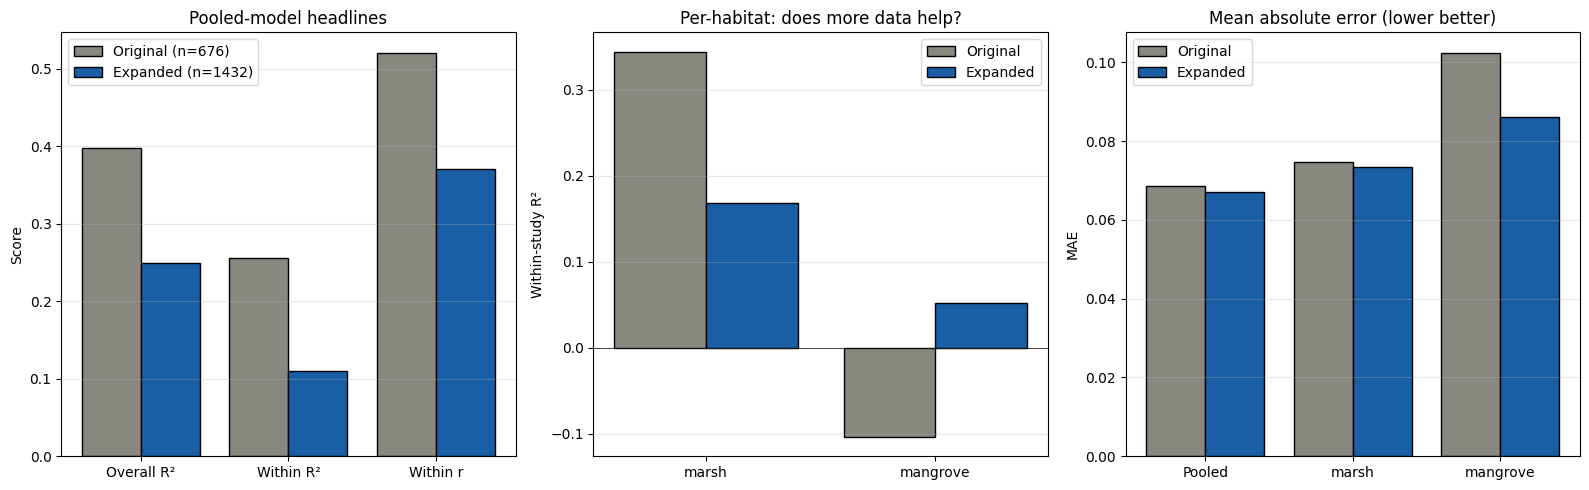


✓ Saved comparison JSON and plot to /content/drive/MyDrive/CCN_synthesis_expanded

══════════════════════════════════════════════════════════════════════════════
BOTTOM LINE
══════════════════════════════════════════════════════════════════════════════
  Sample size:  676 → 1432 cores  (2.1× expansion)
  ✗ Expansion HURT aggregate metrics (Δ within R² = -0.146).
    New geography brings new ecosystems the model doesn't handle yet.


In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
 PART F — SIDE-BY-SIDE COMPARISON: original vs expanded
═══════════════════════════════════════════════════════════════════════════════
 Run this AFTER you've executed the notebook in BOTH RUN_MODE values.
 Reads predictions from both cache directories and produces an honest
 head-to-head report.
═══════════════════════════════════════════════════════════════════════════════
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import json
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

ORIG_DIR = Path('/content/drive/MyDrive/CCN_synthesis')
EXP_DIR  = Path('/content/drive/MyDrive/CCN_synthesis_expanded')


def _check_run(label, d):
    needed = ['final_predictions_calibrated.csv',
              'habitat_stratified_preds.csv',
              'rock_filter_diagnostic.csv']
    missing = [f for f in needed if not (d / f).exists()]
    if missing:
        print(f"  ✗ {label}  ({d})")
        for m in missing: print(f"      missing: {m}")
        return False
    print(f"  ✓ {label}  ({d})")
    return True

print("═" * 78)
print("Looking for outputs from both runs:")
print("═" * 78)
ok_o = _check_run('ORIGINAL', ORIG_DIR)
ok_e = _check_run('EXPANDED', EXP_DIR)
if not (ok_o and ok_e):
    raise RuntimeError(
        "\nMissing outputs. To produce them: set RUN_MODE in PART 0, run the\n"
        "entire notebook, repeat with the other RUN_MODE value, then re-run\n"
        "this comparison cell.")


def _load(d):
    return {
        'pooled': pd.read_csv(d / 'final_predictions_calibrated.csv'),
        'habs':   pd.read_csv(d / 'habitat_stratified_preds.csv'),
        'rock':   pd.read_csv(d / 'rock_filter_diagnostic.csv'),
    }

ORIG = _load(ORIG_DIR)
EXP  = _load(EXP_DIR)


def metrics(y_true, y_pred, g):
    sm = pd.Series(y_true).groupby(g).transform('mean').values
    pm = pd.Series(y_pred).groupby(g).transform('mean').values
    abs_err = np.abs(y_true - y_pred)
    return {
        'n_cores':     int(len(y_true)),
        'n_studies':   int(len(np.unique(g))),
        'overall_r2':  float(r2_score(y_true, y_pred)),
        'overall_r':   float(pearsonr(y_true, y_pred)[0]),
        'within_r2':   float(r2_score(y_true - sm, y_pred - pm)),
        'within_r':    float(pearsonr(y_true - sm, y_pred - pm)[0]),
        'mae':         float(abs_err.mean()),
        'rmse':        float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'pct_within_005': float(100 * (abs_err <= 0.05).mean()),
        'pct_within_010': float(100 * (abs_err <= 0.10).mean()),
    }


# F.1  Coverage
print("\n" + "═" * 78)
print("F.1  Coverage — what did expansion add?")
print("═" * 78)
cov = {
    'cores_orig':       len(ORIG['pooled']),
    'cores_exp':        len(EXP['pooled']),
    'cores_added':      len(EXP['pooled']) - len(ORIG['pooled']),
    'cores_multiplier': len(EXP['pooled']) / max(len(ORIG['pooled']), 1),
    'studies_orig':     ORIG['pooled']['study_id'].nunique(),
    'studies_exp':      EXP['pooled']['study_id'].nunique(),
    'studies_added':    EXP['pooled']['study_id'].nunique() - ORIG['pooled']['study_id'].nunique(),
}
print(f"  Cores:   {cov['cores_orig']:>5d}  →  {cov['cores_exp']:>5d}  "
      f"(+{cov['cores_added']}, {cov['cores_multiplier']:.2f}×)")
print(f"  Studies: {cov['studies_orig']:>5d}  →  {cov['studies_exp']:>5d}  "
      f"(+{cov['studies_added']})")

print(f"\n  Habitat breakdown (expanded run):")
for h, n in EXP['habs']['habitat'].value_counts().items():
    orig_n = (ORIG['habs']['habitat'] == h).sum()
    print(f"    {h:<14s} {orig_n:>5d}  →  {n:>5d}  (+{n-orig_n})")


# F.2  Pooled metrics
print("\n" + "═" * 78)
print("F.2  Pooled-model headlines (calibrated predictions)")
print("═" * 78)
m_orig = metrics(ORIG['pooled']['y_observed'].values,
                  ORIG['pooled']['y_pred_calibrated'].values,
                  ORIG['pooled']['study_id'].values)
m_exp  = metrics(EXP['pooled']['y_observed'].values,
                  EXP['pooled']['y_pred_calibrated'].values,
                  EXP['pooled']['study_id'].values)

print(f"  {'metric':<22s}  {'original':>14s}  {'expanded':>14s}  {'Δ':>10s}")
print("  " + "─" * 70)
for k, label in [('n_cores','N cores'), ('n_studies','N studies'),
                  ('overall_r2','overall R²'), ('within_r2','within-study R²'),
                  ('within_r','within-study r'), ('mae','MAE'), ('rmse','RMSE'),
                  ('pct_within_005','% within ±0.05'),
                  ('pct_within_010','% within ±0.10')]:
    a, b = m_orig[k], m_exp[k]; d = b - a
    if k.startswith(('overall_r','within_r')):
        print(f"  {label:<22s}  {a:>+14.4f}  {b:>+14.4f}  {d:>+10.4f}")
    elif k.startswith('pct_'):
        print(f"  {label:<22s}  {a:>13.1f}%  {b:>13.1f}%  {d:>+9.1f}pp")
    elif k.startswith('n_'):
        print(f"  {label:<22s}  {a:>14d}  {b:>14d}  {d:>+10d}")
    else:
        print(f"  {label:<22s}  {a:>14.4f}  {b:>14.4f}  {d:>+10.4f}")


# F.3  Per-habitat
print("\n" + "═" * 78)
print("F.3  Per-habitat: does expansion change the marsh-vs-mangrove story?")
print("═" * 78)
hab_results = {}
for hab in ['marsh', 'mangrove']:
    o_h = ORIG['habs'][ORIG['habs']['habitat'] == hab]
    e_h = EXP['habs'][EXP['habs']['habitat'] == hab]
    if len(o_h) < 30 or len(e_h) < 30:
        print(f"\n  {hab}: skipping (n_orig={len(o_h)}, n_exp={len(e_h)})")
        continue
    m_o = metrics(o_h['y_observed'].values, o_h['y_pred_calibrated'].values,
                   o_h['study_id'].values)
    m_e = metrics(e_h['y_observed'].values, e_h['y_pred_calibrated'].values,
                   e_h['study_id'].values)
    hab_results[hab] = {'original': m_o, 'expanded': m_e}
    print(f"\n  {hab.upper()}:")
    print(f"    {'metric':<20s}  {'orig':>12s}  {'expanded':>12s}  {'Δ':>10s}")
    for k, label in [('n_cores','N cores'),('n_studies','N studies'),
                      ('within_r2','within R²'),('within_r','within r'),
                      ('mae','MAE'),('pct_within_005','% within ±0.05')]:
        a, b = m_o[k], m_e[k]; d = b - a
        if k.startswith(('within_r','overall_r')):
            print(f"    {label:<20s}  {a:>+12.4f}  {b:>+12.4f}  {d:>+10.4f}")
        elif k == 'pct_within_005':
            print(f"    {label:<20s}  {a:>11.1f}%  {b:>11.1f}%  {d:>+9.1f}pp")
        elif k.startswith('n_'):
            print(f"    {label:<20s}  {a:>12d}  {b:>12d}  {d:>+10d}")
        else:
            print(f"    {label:<20s}  {a:>12.4f}  {b:>12.4f}  {d:>+10.4f}")


# F.4  Geographic breakdown
print("\n" + "═" * 78)
print("F.4  Where the new data came from (longitude bins)")
print("═" * 78)
try:
    rock_e = EXP['rock'].copy()
    if 'latitude' in rock_e.columns and 'longitude' in rock_e.columns:
        lookup = rock_e.set_index(['study_id','core_id'])[['latitude','longitude']]
        pe = EXP['pooled'].merge(lookup, left_on=['study_id','core_id'],
                                  right_index=True, how='left')
        bands = pd.cut(pe['longitude'].values,
                        bins=[-180, -130, -100, -85, -75, -50],
                        labels=['Pacific (<-130)',
                                'Western Gulf (-130 to -100)',
                                'E Gulf / FL (-100 to -85)',
                                'SE Atlantic (-85 to -75)',
                                'NE Atlantic (>-75)'])
        pe['lon_band'] = bands
        pe['abs_err'] = np.abs(pe['y_observed'] - pe['y_pred_calibrated'])
        bs = pe.groupby('lon_band', observed=True).agg(
            n_cores=('study_id','size'), n_studies=('study_id','nunique'),
            mean_obs=('y_observed','mean'), mae=('abs_err','mean')).reset_index()
        print(f"  {'longitude band':<32s} {'N cores':>8s} {'N studies':>10s} "
              f"{'mean obs C':>11s} {'MAE':>8s}")
        for _, r in bs.iterrows():
            print(f"  {str(r['lon_band']):<32s} {int(r['n_cores']):>8d} "
                  f"{int(r['n_studies']):>10d} {r['mean_obs']:>11.4f} "
                  f"{r['mae']:>8.4f}")
    else:
        print("  (lat/lon not in rock filter output; skipping)")
except Exception as e:
    print(f"  Geographic breakdown failed: {e}")


# F.5  Verdict
print("\n" + "═" * 78)
print("F.5  Did the conclusions change?")
print("═" * 78)
checks = []
m_e_marsh = hab_results.get('marsh', {}).get('expanded', {})
if m_e_marsh:
    if m_e_marsh.get('within_r2', 0) > 0.20:
        checks.append(('Marsh model still strong', '✓',
                        f"within R² = {m_e_marsh['within_r2']:+.3f}"))
    else:
        checks.append(('Marsh model weakened', '✗',
                        f"within R² dropped to {m_e_marsh['within_r2']:+.3f}"))
m_e_mang = hab_results.get('mangrove', {}).get('expanded', {})
if m_e_mang:
    if m_e_mang.get('within_r2', -99) > 0.05:
        checks.append(('Mangrove model NOW WORKS', '✓ NEW',
                        f"within R² = {m_e_mang['within_r2']:+.3f}"))
    elif m_e_mang.get('n_cores', 0) > 200:
        checks.append(('Mangrove still data-limited despite more data', '~',
                        f"within R² = {m_e_mang['within_r2']:+.3f} on "
                        f"{m_e_mang['n_cores']} cores"))
    else:
        checks.append(('Mangrove still data-limited', '✗',
                        f"only {m_e_mang.get('n_cores',0)} mangrove cores"))
if 0.30 <= m_exp['overall_r2'] <= 0.50:
    checks.append(('Pooled R² stable in 0.30-0.50', '✓',
                    f"R² = {m_exp['overall_r2']:+.3f}"))
elif m_exp['overall_r2'] > 0.50:
    checks.append(('Pooled R² IMPROVED beyond 0.50', '✓ NEW',
                    f"R² = {m_exp['overall_r2']:+.3f}"))
else:
    checks.append(('Pooled R² weakened with expansion', '✗',
                    f"R² = {m_exp['overall_r2']:+.3f}"))

print()
for label, flag, detail in checks:
    print(f"  {flag:>5s}  {label:<46s}  {detail}")


# F.6  Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
metric_names = ['Overall R²', 'Within R²', 'Within r']
orig_vals = [m_orig['overall_r2'], m_orig['within_r2'], m_orig['within_r']]
exp_vals  = [m_exp['overall_r2'],  m_exp['within_r2'],  m_exp['within_r']]
xpos = np.arange(len(metric_names)); w = 0.4
ax.bar(xpos - w/2, orig_vals, w, label=f'Original (n={m_orig["n_cores"]})',
        color='#888780', edgecolor='k')
ax.bar(xpos + w/2, exp_vals,  w, label=f'Expanded (n={m_exp["n_cores"]})',
        color='#185FA5', edgecolor='k')
ax.set_xticks(xpos); ax.set_xticklabels(metric_names)
ax.set_ylabel('Score'); ax.set_title('Pooled-model headlines')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.axhline(0, color='k', lw=0.5)

if hab_results:
    ax = axes[1]
    habs_l = list(hab_results.keys())
    o = [hab_results[h]['original']['within_r2'] for h in habs_l]
    e = [hab_results[h]['expanded']['within_r2'] for h in habs_l]
    xpos = np.arange(len(habs_l)); w = 0.4
    ax.bar(xpos - w/2, o, w, label='Original', color='#888780', edgecolor='k')
    ax.bar(xpos + w/2, e, w, label='Expanded', color='#185FA5', edgecolor='k')
    ax.set_xticks(xpos); ax.set_xticklabels(habs_l)
    ax.set_ylabel('Within-study R²')
    ax.set_title('Per-habitat: does more data help?')
    ax.legend(); ax.grid(axis='y', alpha=0.3); ax.axhline(0, color='k', lw=0.5)
else:
    axes[1].axis('off')

ax = axes[2]
mae_orig = [m_orig['mae']] + [hab_results[h]['original']['mae'] for h in hab_results]
mae_exp  = [m_exp['mae']]  + [hab_results[h]['expanded']['mae']  for h in hab_results]
labels   = ['Pooled'] + list(hab_results.keys())
xpos = np.arange(len(labels)); w = 0.4
ax.bar(xpos - w/2, mae_orig, w, label='Original', color='#888780', edgecolor='k')
ax.bar(xpos + w/2, mae_exp,  w, label='Expanded', color='#185FA5', edgecolor='k')
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_ylabel('MAE'); ax.set_title('Mean absolute error (lower better)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(EXP_DIR / 'comparison_original_vs_expanded.png', dpi=140, bbox_inches='tight')
plt.show()


# Save everything
comparison = {
    'coverage':  cov,
    'pooled':    {'original': m_orig, 'expanded': m_exp},
    'habitats':  hab_results,
    'verdict_checks': [{'claim': c[0], 'flag': c[1], 'detail': c[2]} for c in checks],
}
with open(EXP_DIR / 'comparison_original_vs_expanded.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print(f"\n✓ Saved comparison JSON and plot to {EXP_DIR}")


# Bottom line
print("\n" + "═" * 78)
print("BOTTOM LINE")
print("═" * 78)
print(f"  Sample size:  {m_orig['n_cores']} → {m_exp['n_cores']} cores  "
      f"({cov['cores_multiplier']:.1f}× expansion)")
d_w = m_exp['within_r2'] - m_orig['within_r2']
d_o = m_exp['overall_r2'] - m_orig['overall_r2']
if d_w > 0.03 and d_o > 0.03:
    print(f"  ✓ Expansion HELPED: pooled within R² {d_w:+.3f}, overall R² {d_o:+.3f}")
elif abs(d_w) < 0.02 and abs(d_o) < 0.02:
    print(f"  ~ Expansion NEUTRAL on aggregate metrics — but the story may have")
    print(f"    changed at the habitat level. See F.3 above.")
elif d_w < -0.02 or d_o < -0.02:
    print(f"  ✗ Expansion HURT aggregate metrics (Δ within R² = {d_w:+.3f}).")
    print(f"    New geography brings new ecosystems the model doesn't handle yet.")
else:
    print(f"  Δ within R² = {d_w:+.3f}, Δ overall R² = {d_o:+.3f}")